RECOPILACION DE DATOS

In [1]:
# Ejecuta esta celda primero en un kernel nuevo para instalar dependencias.
%pip -q install amplpy pandas numpy openpyxl scipy matplotlib seaborn yfinance ipykernel

from pathlib import Path

import yfinance as yf
import pandas as pd

def _resolver_data_dir():
    notebook_file = globals().get("__vsc_ipynb_file__")
    if notebook_file:
        return Path(notebook_file).expanduser().resolve().parent
    return Path.cwd().resolve()

# En VS Code/Jupyter local se guarda y lee desde la carpeta del notebook.
# Si quieres usar otra carpeta, cambia DATA_DIR_MANUAL por una ruta como Path(r"C:\Users\tu_usuario\datos").
DATA_DIR_MANUAL = None
DATA_DIR = Path(DATA_DIR_MANUAL).expanduser().resolve() if DATA_DIR_MANUAL else _resolver_data_dir()
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Carpeta de trabajo local: {DATA_DIR}")

# 1. Definir la lista de acciones
tickers = [
    "COPEC.SN", "SQM-B.SN", "ENELAM.SN", "AGUAS-A.SN",
    "CHILE.SN", "CENCOSUD.SN", "SMU.SN", "PARAUCO.SN",
    "MALLPLAZA.SN", "CMPC.SN"
]

# 2. Fechas
fecha_inicio = "2019-12-01"
fecha_fin = "2026-01-01"

# 3. Descargar datos semanales
print("Descargando datos históricos semanales de Yahoo Finance...")
# auto_adjust=False asegura que descargue la columna 'Adj Close' por separado
datos = yf.download(tickers, start=fecha_inicio, end=fecha_fin, interval="1wk", auto_adjust=False)

# 4. Extraer precios de cierre ajustado y calcular retornos
# o simplemente filtramos por el nivel de precios si es un MultiIndex.
if 'Adj Close' in datos.columns.levels[0]:
    precios = datos['Adj Close']
else:
    # Fallback para estructuras donde el precio ajustado se descarga como Close con auto_adjust
    precios = datos['Close']

retornos_semanales = precios.pct_change().dropna()

# Transponer la matriz para que las acciones queden en las filas y las fechas en las columnas
retornos_semanales = retornos_semanales.T

# --- MOSTRAR RESULTADOS ---
print("\n--- Retornos Semanales (Todos los meses) ---")
print(retornos_semanales.to_string())

# --- GUARDAR LOS RESULTADOS ---
nombre_archivo_excel = DATA_DIR / "Retornos_Semanales_Acciones_Chilenas.xlsx"
nombre_archivo_csv = DATA_DIR / "Retornos_Semanales_Acciones_Chilenas.csv"

retornos_semanales.to_csv(nombre_archivo_csv)
print(f"\n¡Listo! Guardado en: {nombre_archivo_csv}")

try:
    retornos_semanales.to_excel(nombre_archivo_excel)
    print(f"¡Guardado en Excel: {nombre_archivo_excel}!")
except Exception:
    print("Nota: No se pudo guardar en Excel (posiblemente falta openpyxl).")

Note: you may need to restart the kernel to use updated packages.
Carpeta de trabajo local: C:\Users\brand\Downloads
Descargando datos históricos semanales de Yahoo Finance...


[*********************100%***********************]  10 of 10 completed



--- Retornos Semanales (Todos los meses) ---
Date          2019-12-09  2019-12-16  2019-12-23  2019-12-30  2020-01-06  2020-01-13  2020-01-20  2020-01-27  2020-02-03  2020-02-10  2020-02-17  2020-02-24  2020-03-02  2020-03-09  2020-03-16  2020-03-23  2020-03-30  2020-04-06  2020-04-13  2020-04-20  2020-04-27  2020-05-04  2020-05-11  2020-05-18  2020-05-25  2020-06-01  2020-06-08  2020-06-15  2020-06-22  2020-06-29  2020-07-06  2020-07-13  2020-07-20  2020-07-27  2020-08-03  2020-08-10  2020-08-17  2020-08-24  2020-08-31  2020-09-07  2020-09-14  2020-09-21  2020-09-28  2020-10-05  2020-10-12  2020-10-19  2020-10-26  2020-11-02  2020-11-09  2020-11-16  2020-11-23  2020-11-30  2020-12-07  2020-12-14  2020-12-21  2020-12-28  2021-01-04  2021-01-11  2021-01-18  2021-01-25  2021-02-01  2021-02-08  2021-02-15  2021-02-22  2021-03-01  2021-03-08  2021-03-15  2021-03-22  2021-03-29  2021-04-05  2021-04-12  2021-04-19  2021-04-26  2021-05-03  2021-05-10  2021-05-17  2021-05-24  2021-05-31  2021

In [2]:
from pathlib import Path

import pandas as pd

# Cargar el archivo CSV generado
# El archivo correcto es 'Retornos_Semanales_Acciones_Chilenas.csv'
nombre_archivo_csv = (DATA_DIR if "DATA_DIR" in globals() else Path.cwd()) / "Retornos_Semanales_Acciones_Chilenas.csv"
df_leido = pd.read_csv(nombre_archivo_csv, index_col=0)

# Mostrar las primeras filas
print(f'Contenido de {nombre_archivo_csv}:')
display(df_leido.head())

Contenido de C:\Users\brand\Downloads\Retornos_Semanales_Acciones_Chilenas.csv:


,2019-12-09,2019-12-16,2019-12-23,2019-12-30,2020-01-06,2020-01-13,2020-01-20,2020-01-27,2020-02-03,2020-02-10,...,2025-10-27,2025-11-03,2025-11-10,2025-11-17,2025-11-24,2025-12-01,2025-12-08,2025-12-15,2025-12-22,2025-12-29
Ticker,,,,,,,,,,,,,,,,,,,,,
AGUAS-A.SN,0.071676,-0.032853,-0.021075,0.006524,0.044136,-0.029647,-0.044507,-0.022801,0.054667,-0.032870,...,0.005602,0.008329,0.002790,0.002727,0.027237,0.008312,0.004081,-0.022773,0.019199,-0.002703
CENCOSUD.SN,-0.059041,-0.029402,0.005040,0.040101,0.012562,0.008684,-0.026206,-0.038181,0.045455,-0.017391,...,0.082994,0.001368,-0.026990,-0.020119,0.045616,-0.000034,0.011001,-0.025763,0.009395,-0.002068
CHILE.SN,0.028977,-0.054598,-0.039514,0.072152,0.044864,-0.072768,-0.041799,0.002162,0.032741,-0.007373,...,0.023904,0.053860,-0.034828,0.030120,0.023977,-0.001770,0.003089,-0.018708,0.015693,-0.004292
CMPC.SN,0.070907,-0.047980,-0.005889,0.024601,0.083333,-0.001442,-0.070775,-0.049223,0.035422,0.031053,...,0.037376,0.013235,-0.030479,-0.006362,-0.023202,0.082671,0.061329,-0.067248,0.007987,0.009351
COPEC.SN,0.058677,-0.075844,0.029611,0.049635,0.055633,0.027536,-0.063982,-0.021918,0.050420,0.025333,...,0.021061,0.035762,-0.039971,-0.012088,0.003927,0.018658,0.045775,-0.042632,0.027589,0.013640


CALCULO MOMENTOS

In [3]:
from pathlib import Path

import pandas as pd
from scipy.stats import skew, kurtosis

DATA_DIR = DATA_DIR if "DATA_DIR" in globals() else Path.cwd().resolve()

# Cargar el archivo Excel generado en la sección anterior
# Aseguramos que la ruta y el nombre del archivo sean correctos
retornos_df = pd.read_excel(DATA_DIR / "Retornos_Semanales_Acciones_Chilenas.xlsx")

# La primera columna contiene los nombres de las acciones, establecerla como índice
retornos_df.set_index(retornos_df.columns[0], inplace=True)

# Convertir todos los datos de retorno a numérico (manejar posibles errores)
retornos_df = retornos_df.apply(pd.to_numeric, errors='coerce')

# --- Calcular Momentos Estadísticos por Fila (Acción) ---
momentos_estadisticos = pd.DataFrame({
    "media": retornos_df.mean(axis=1),
    "varianza": retornos_df.var(axis=1),
    "skewness": retornos_df.apply(skew, axis=1, bias=False, nan_policy='omit'),
    "curtosis": retornos_df.apply(kurtosis, axis=1, bias=False, fisher=True, nan_policy='omit')
})

print("\n--- Momentos Estadísticos por Acción ---")
print(momentos_estadisticos)

# --- Calcular Matriz de Covarianza ---
# La matriz de covarianza se calcula entre las columnas (fechas) para ver la covarianza entre los retornos de las acciones.
# Para calcular la covarianza entre acciones, necesitamos que las acciones sean las columnas.
# Como ya transpusimos los retornos en el paso anterior y las acciones están en el índice y las fechas en las columnas,
# necesitamos transponerlo de nuevo temporalmente o usar .T antes de .cov() si queremos la covarianza entre acciones.

# Para la covarianza entre acciones, los retornos deben estar con acciones en columnas y fechas en filas.
# retornos_df ya tiene acciones en el índice y fechas en las columnas, lo cual significa que para cov()
# que opera por columna, necesitamos transponer para que las acciones sean columnas para calcular la covarianza entre ellas.

matriz_covarianza = retornos_df.T.cov()

print("\n--- Matriz de Covarianza de Retornos Semanales ---")
print(matriz_covarianza)

# Guardar la matriz de covarianza si es necesario
# matriz_covarianza.to_excel(DATA_DIR / "Matriz_Covarianza_Retornos_Semanales.xlsx")
momentos_estadisticos.to_csv(DATA_DIR / "Momentos_Estadisticos_Retornos_Semanales.csv")
matriz_covarianza.to_csv(DATA_DIR / "Matriz_Covarianza_Retornos_Semanales.csv")
print(f"Momentos guardados en: {DATA_DIR / 'Momentos_Estadisticos_Retornos_Semanales.csv'}")
print(f"Covarianza guardada en: {DATA_DIR / 'Matriz_Covarianza_Retornos_Semanales.csv'}")


--- Momentos Estadísticos por Acción ---
                 media  varianza  skewness  curtosis
Ticker                                              
AGUAS-A.SN    0.002679  0.001875  0.142018  4.768901
CENCOSUD.SN   0.005301  0.001957 -0.208019  7.103698
CHILE.SN      0.003982  0.001372  0.707016  2.547780
CMPC.SN       0.000283  0.001915  0.455738  2.369970
COPEC.SN      0.001089  0.001897 -0.663212  4.708041
ENELAM.SN    -0.001202  0.001557  0.748878  6.579650
MALLPLAZA.SN  0.003889  0.002791 -0.143609  4.031309
PARAUCO.SN    0.003450  0.002951 -0.920846  8.311426
SMU.SN        0.002559  0.001783  0.707420  1.978867
SQM-B.SN      0.006059  0.004116  0.173538  1.797178

--- Matriz de Covarianza de Retornos Semanales ---
Ticker        AGUAS-A.SN  CENCOSUD.SN  CHILE.SN   CMPC.SN  COPEC.SN  \
Ticker                                                                
AGUAS-A.SN      0.001875     0.000658  0.000690  0.000683  0.000715   
CENCOSUD.SN     0.000658     0.001957  0.000581  0.000818

RETORNOS HISTORICOS ACUMULADOS
Este grafico muestra la evolucion acumulada de los retornos semanales por activo durante el periodo historico usado en el estudio. Su objetivo es contextualizar visualmente el comportamiento de las acciones antes de generar escenarios.

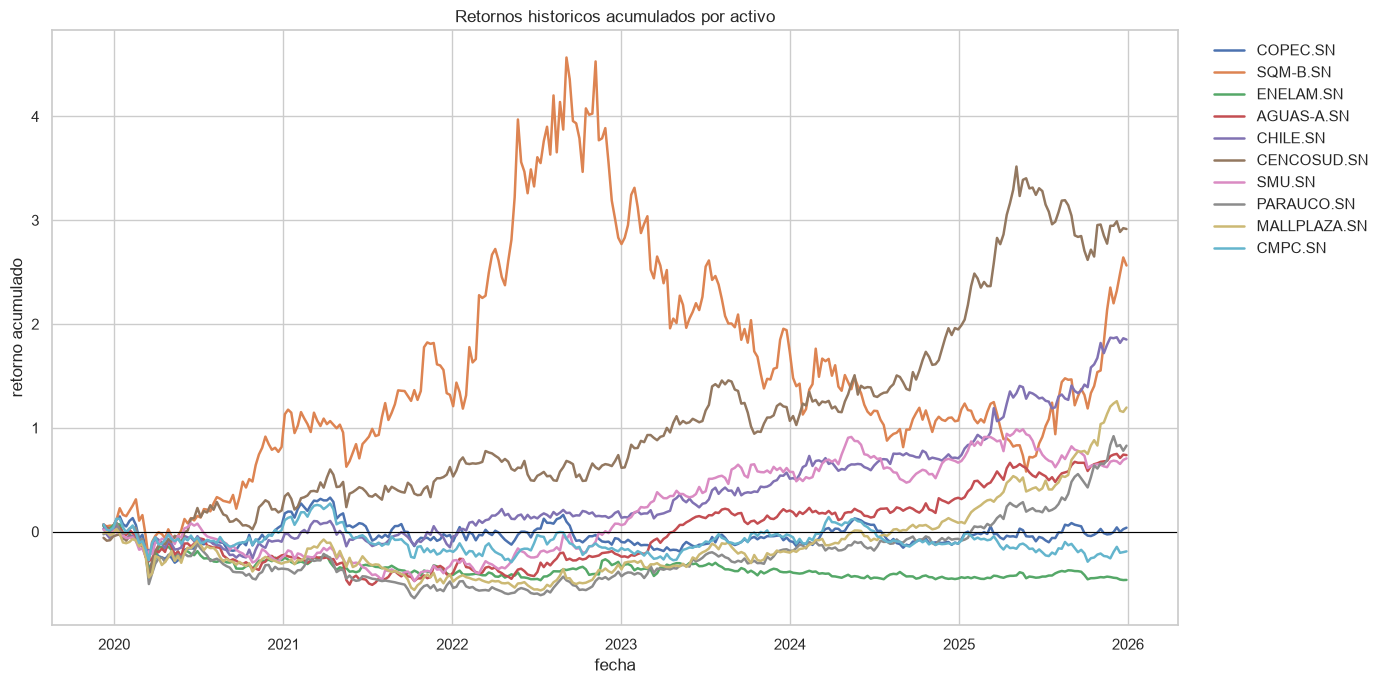

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def preparar_retornos_historicos_acumulados():
    if "retornos_df" in globals():
        base = retornos_df.copy()
    elif "retornos_semanales" in globals():
        base = retornos_semanales.copy()
    else:
        raise NameError("No existen retornos_df ni retornos_semanales. Ejecuta primero la carga/calculo de retornos.")

    base.index = base.index.astype(str)

    # El formato esperado es: filas = activos, columnas = fechas.
    # Si accidentalmente viene con activos en columnas, se transpone.
    if "tickers" in globals():
        activos_en_indice = [t for t in tickers if t in base.index]
        activos_en_columnas = [t for t in tickers if t in base.columns]
        if len(activos_en_indice) >= 2:
            base = base.loc[activos_en_indice]
        elif len(activos_en_columnas) >= 2:
            base = base[activos_en_columnas].T

    base = base.apply(pd.to_numeric, errors="coerce")
    fechas = pd.to_datetime(base.columns, errors="coerce")
    columnas_validas = ~pd.isna(fechas)
    base = base.loc[:, columnas_validas]
    base.columns = fechas[columnas_validas]
    base = base.sort_index(axis=1)

    retornos_en_filas = base.T.dropna(how="all")
    return retornos_en_filas


retornos_hist_lineas = preparar_retornos_historicos_acumulados()
retornos_acumulados_activos = (1.0 + retornos_hist_lineas).cumprod() - 1.0

plt.figure(figsize=(14, 7))
for activo in retornos_acumulados_activos.columns:
    plt.plot(retornos_acumulados_activos.index, retornos_acumulados_activos[activo], linewidth=1.8, label=activo)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Retornos historicos acumulados por activo")
plt.xlabel("fecha")
plt.ylabel("retorno acumulado")
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()
plt.show()


WEINER

Generando escenarios mediante el Proceso de Wiener (horizonte de 1 semana)...
Simulación completada: 8000 escenarios generados para un horizonte de 1 semana.

--- Primeros 5 Escenarios (Retornos Semanales Simulados) ---


,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN,ENELAM.SN,MALLPLAZA.SN,PARAUCO.SN,SMU.SN,SQM-B.SN
0,-0.030236,-0.007509,0.044294,-0.035942,-0.079151,-0.011655,-0.051026,0.001873,-0.045652,-0.081649
1,0.073227,-0.068627,-0.026265,-0.004182,-0.003462,-0.026457,0.019111,0.041412,0.092219,0.076498
2,-0.051942,0.011851,0.002613,0.001379,0.000576,0.008329,0.034182,0.068811,0.010117,-0.009467
3,0.004172,0.010606,-0.016239,0.049295,0.016265,0.012894,-0.057043,0.017321,-0.003628,-0.045781
4,-0.067559,-0.072454,0.043838,-0.067116,-0.084795,-0.018158,-0.038476,-0.121903,-0.024479,-0.086272


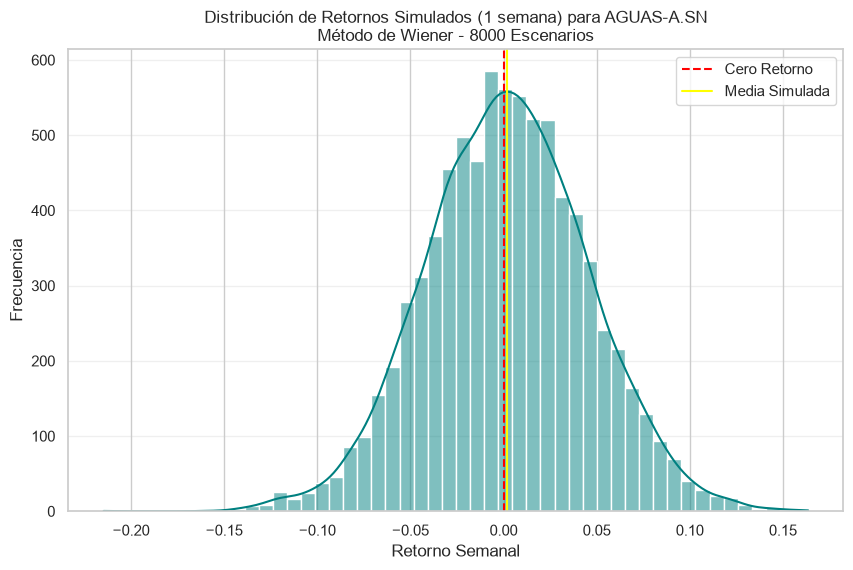

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = DATA_DIR if "DATA_DIR" in globals() else Path.cwd().resolve()

# --- 1. Preparación de Datos ---
if 'retornos_semanales' not in globals() or 'matriz_covarianza' not in globals():
    print("Cargando datos necesarios...")
    retornos_df = pd.read_excel(DATA_DIR / "Retornos_Semanales_Acciones_Chilenas.xlsx", index_col=0)
    matriz_covarianza = retornos_df.T.cov()
    momentos_hist = pd.DataFrame({
        'media': retornos_df.mean(axis=1),
        'varianza': retornos_df.var(axis=1)
    })
else:
    momentos_hist = momentos_estadisticos[['media', 'varianza']]

# --- 2. Parámetros de la Simulación de Wiener ---
tickers = momentos_hist.index.tolist()
num_activos = len(tickers)
mu = momentos_hist['media'].values
cov_matrix = matriz_covarianza.values
num_escenarios = 8000

# Descomposición de Cholesky de la matriz de covarianza semanal histórica.
# Si no es definida positiva por errores numéricos, se agrega una pequeña
# perturbación en la diagonal (1e-8) para estabilizar el cálculo (Sección 3.3).
try:
    L = np.linalg.cholesky(cov_matrix)
except np.linalg.LinAlgError:
    pd_cov = matriz_covarianza + np.eye(num_activos) * 1e-8
    L = np.linalg.cholesky(pd_cov)

# --- 3. Simulación de Escenarios (horizonte de una semana, un solo paso) ---
print("Generando escenarios mediante el Proceso de Wiener (horizonte de 1 semana)...")

Z = np.random.standard_normal((num_activos, num_escenarios))
r_semana = mu[:, np.newaxis] + L @ Z

# Se mantiene el nombre "escenarios_r02_df" por compatibilidad con las celdas
# posteriores (carga de Wiener para multistart, comparación de momentos y
# backtesting), aunque ahora representa retornos de una sola semana.
escenarios_r02_df = pd.DataFrame(r_semana.T, columns=tickers)

print(f"Simulación completada: {num_escenarios} escenarios generados para un horizonte de 1 semana.")

# --- 4. Visualización de Resultados ---
print("\n--- Primeros 5 Escenarios (Retornos Semanales Simulados) ---")
display(escenarios_r02_df.head())

primer_activo = tickers[0]

plt.figure(figsize=(10, 6))
sns.histplot(escenarios_r02_df[primer_activo], kde=True, color='teal', bins=50)
plt.title(f'Distribución de Retornos Simulados (1 semana) para {primer_activo}\nMétodo de Wiener - 8000 Escenarios')
plt.axvline(0, color='red', linestyle='--', label='Cero Retorno')
plt.axvline(escenarios_r02_df[primer_activo].mean(), color='yellow', linestyle='-', label='Media Simulada')
plt.xlabel('Retorno Semanal')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
import pandas as pd
import numpy as np

# 1. Preparar Métricas Históricas (Semanales)
# CVaR Histórico al 95%
def calcular_cvar(series, confidence=0.05):
    var_threshold = series.quantile(confidence)
    return series[series <= var_threshold].mean()

cvar_hist = retornos_semanales.apply(calcular_cvar, axis=1)

# 2. Preparar Métricas Simuladas (basadas en retornos proyectados a la Semana 2)
# Retorno proyectado: (S_T / S_0) - 1
# Corregir: usar 'escenarios_r02_df' en lugar de 'df_semana_2'
retornos_proyectados = escenarios_r02_df

metrics_data = []
for ticker in tickers:
    metrics_data.append({
        'Activo': ticker,
        'Ret. Esp. Real (Anual)': momentos_estadisticos.loc[ticker, 'media'] * 52,
        'Ret. Esp. Sim. (Anual)': (np.log(escenarios_r02_df[ticker].mean() + 1)) / (2/52), # +1 para log(1+r) y anualizar
        'Varianza Real (Sem)': momentos_estadisticos.loc[ticker, 'varianza'],
        'Varianza Sim. (Sem)': retornos_proyectados[ticker].var() / 2, # Ajustado por T=2
        'CVaR Real (95%)': cvar_hist[ticker],
        'CVaR Sim. (95%)': calcular_cvar(retornos_proyectados[ticker])
    })

df_comparativo_final = pd.DataFrame(metrics_data).set_index('Activo')

print("--- Tabla Comparativa: Métricas Reales vs. Simuladas ---")
display(df_comparativo_final.round(6))

--- Tabla Comparativa: Métricas Reales vs. Simuladas ---


,Ret. Esp. Real (Anual),Ret. Esp. Sim. (Anual),Varianza Real (Sem),Varianza Sim. (Sem),CVaR Real (95%),CVaR Sim. (95%)
Activo,,,,,,
AGUAS-A.SN,0.139306,0.045707,0.001875,0.000946,-0.089647,-0.089048
CENCOSUD.SN,0.275652,0.122602,0.001957,0.001000,-0.091068,-0.087272
CHILE.SN,0.207040,0.092687,0.001372,0.000684,-0.067830,-0.073686
CMPC.SN,0.014732,-0.007718,0.001915,0.000952,-0.088049,-0.091107
COPEC.SN,0.056634,0.013720,0.001897,0.000931,-0.098023,-0.088865
ENELAM.SN,-0.062481,-0.054195,0.001557,0.000767,-0.089119,-0.083852
MALLPLAZA.SN,0.202249,0.087179,0.002791,0.001396,-0.122207,-0.105180
PARAUCO.SN,0.179409,0.071164,0.002951,0.001468,-0.121464,-0.108095
SMU.SN,0.133071,0.059482,0.001783,0.000904,-0.079346,-0.085856


MATCHING MOMENT

1. Instalacion en VS Code/Jupyter local
AMPL se llama desde Python con amplpy. Para este problema uso IPOPT como solver por defecto, porque al fijar p[s] = 1/N el modelo queda como un NLP suave no convexo con variables continuas, no como un problema mixto con enteros. El multistart ayuda a reducir la dependencia del minimo local.

Si tienes licencia/modulo disponible, puedes cambiar SOLVER = "baron" para busqueda global no convexa, o SOLVER = "scip" para MINLP/NLP no convexo. El modulo coin instala IPOPT mediante los modulos de AMPL.

In [7]:
# Dependencias para correr este notebook en VS Code/Jupyter local.
%pip -q install amplpy pandas numpy openpyxl scipy matplotlib seaborn yfinance ipykernel

Note: you may need to restart the kernel to use updated packages.


In [8]:
from amplpy import AMPL, ampl_notebook

AMPL_LICENSE_UUID = "a17b12ce-1815-43d0-95cb-04b0c00b9438"
AMPL_MODULES = ["coin", "scip"]

# "coin" incluye IPOPT. "scip" queda instalado como alternativa si quieres probarlo.
ampl = ampl_notebook(
    modules=AMPL_MODULES,
    license_uuid=AMPL_LICENSE_UUID,
)
print(f"AMPL listo con modulos: {', '.join(AMPL_MODULES)}")

Licensed to Bundle #7505.8073 expiring 20260915: Logistica, Prof. JUAN PABLO CONTRERAS FERNANDEZ, Universidad Diego Portales.
AMPL listo con modulos: coin, scip


CONFIGURACION

In [24]:
from pathlib import Path
import itertools
import math
import warnings

import numpy as np
import pandas as pd

# ---------------------------
# Configuracion principal
# ---------------------------
N_SCENARIOS = 300
N_STARTS = 4
RANDOM_SEED = 1234

# Solver recomendado por defecto para este NLP suave no convexo.
SOLVER = "ipopt"  # opciones usuales: "ipopt", "scip", "baron", "conopt"
SOLVER_OPTIONS = {
    "ipopt": "outlev=0 max_iter=5000 tol=1e-8 acceptable_tol=1e-7 print_user_options=no",
    "scip": "outlev=0 limits/time=300",
    "baron": "maxtime=300 outlev=1",
    "conopt": "outlev=0",
}

# Estos pesos relativos pueden ajustarse.
PESOS_RELATIVOS_MOMENTOS = {1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}
PESO_RELATIVO_COVARIANZAS = 1.0
EPS_PESO = 1e-12

# Tu codigo uso scipy.stats.kurtosis(..., fisher=True), por tanto la curtosis guardada es exceso.
CURTOSIS_ES_EXCESO_FISHER = True

# Rutas locales para VS Code/Jupyter. Reutiliza DATA_DIR si ya se definio arriba.
if "DATA_DIR" not in globals():
    _notebook_file = globals().get("__vsc_ipynb_file__")
    DATA_DIR_MANUAL = None
    DATA_DIR = Path(DATA_DIR_MANUAL).expanduser().resolve() if DATA_DIR_MANUAL else (
        Path(_notebook_file).expanduser().resolve().parent if _notebook_file else Path.cwd().resolve()
    )
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR = {DATA_DIR}")
MOMENTOS_CANDIDATOS = [
    DATA_DIR / "Momentos_Estadisticos_Retornos_Semanales.csv",
    DATA_DIR / "Momentos_Estadisticos_Retornos_Semanales.xlsx",
    DATA_DIR / "momentos_estadisticos.csv",
    DATA_DIR / "momentos_estadisticos.xlsx",
]
COVARIANZA_CANDIDATOS = [
    DATA_DIR / "Matriz_Covarianza_Retornos_Semanales.csv",
    DATA_DIR / "Matriz_Covarianza_Retornos_Semanales.xlsx",
    DATA_DIR / "matriz_covarianza.csv",
    DATA_DIR / "matriz_covarianza.xlsx",
]
WIENER_CANDIDATOS = [
    DATA_DIR / "Escenarios_Wiener_r02.csv",
    DATA_DIR / "Escenarios_Wiener_r02.xlsx",
    DATA_DIR / "escenarios_r02_df.csv",
    DATA_DIR / "escenarios_r02_df.xlsx",
    DATA_DIR / "Escenarios_Wiener.xlsx",
]

SALIDA_ESCENARIOS = DATA_DIR / "Escenarios_Matching_Moment_AMPL_20.csv"
SALIDA_PROBABILIDADES = DATA_DIR / "Probabilidades_Matching_Moment_AMPL_20.csv"
SALIDA_RESUMEN = DATA_DIR / "Resumen_Multistart_Matching_Moment_AMPL.csv"
SALIDA_COMPARACION = DATA_DIR / "Comparacion_Momentos_Matching_Moment_AMPL_20.csv"
# Agregado desde V3_corregido: nombres de salida coherentes con N_SCENARIOS = 300.
SALIDA_ESCENARIOS = DATA_DIR / "Escenarios_Matching_Moment_AMPL_N300.csv"
SALIDA_PROBABILIDADES = DATA_DIR / "Probabilidades_Matching_Moment_AMPL_N300.csv"
SALIDA_COMPARACION = DATA_DIR / "Comparacion_Momentos_Matching_Moment_AMPL_N300.csv"


DATA_DIR = C:\Users\brand\Downloads


3. Carga de resultados previos
Esta seccion no recalcula los momentos historicos ni la matriz de covarianza desde los retornos. Solo carga los resultados que ya generaste y prepara los parametros que necesita el modelo AMPL.

In [25]:
def _primer_archivo_existente(candidatos):
    for ruta in candidatos:
        ruta = Path(ruta)
        if ruta.exists():
            return ruta
    return None


def _leer_tabla(ruta, index_col=0):
    ruta = Path(ruta)
    if ruta.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(ruta, index_col=index_col)
    return pd.read_csv(ruta, index_col=index_col)


def _normalizar_columnas(df):
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    out.index = out.index.map(lambda x: str(x).strip())
    return out


def _buscar_columna(df, aliases, requerido=True):
    columnas = {str(c).strip().lower(): c for c in df.columns}
    for alias in aliases:
        key = alias.strip().lower()
        if key in columnas:
            return columnas[key]
    if requerido:
        raise ValueError(f"No encontre ninguna columna entre {aliases}. Columnas disponibles: {list(df.columns)}")
    return None


def cargar_momentos():
    ruta = _primer_archivo_existente(MOMENTOS_CANDIDATOS)
    if ruta is not None:
        print(f"Cargando momentos desde archivo: {ruta}")
        momentos = _leer_tabla(ruta)
    elif "momentos_estadisticos" in globals():
        print("Usando variable en memoria: momentos_estadisticos")
        momentos = momentos_estadisticos.copy()
    else:
        raise FileNotFoundError(
            "No encontre archivo de momentos ni variable momentos_estadisticos. "
            "Sube/guarda un archivo con columnas media, varianza, skewness y curtosis."
        )

    momentos = _normalizar_columnas(momentos)
    media_col = _buscar_columna(momentos, ["media", "mean", "promedio"])
    var_col = _buscar_columna(momentos, ["varianza", "variance", "var"])

    m3_col = _buscar_columna(momentos, ["m3", "momento3", "momento_3", "tercer_momento"], requerido=False)
    m4_col = _buscar_columna(momentos, ["m4", "momento4", "momento_4", "cuarto_momento"], requerido=False)
    skew_col = _buscar_columna(momentos, ["skewness", "skew", "asimetria", "sesgo"], requerido=False)
    kurt_col = _buscar_columna(momentos, ["curtosis", "kurtosis", "kurt", "exceso_curtosis"], requerido=False)

    base = pd.DataFrame(index=momentos.index)
    base["M1"] = pd.to_numeric(momentos[media_col], errors="coerce")
    base["M2"] = pd.to_numeric(momentos[var_col], errors="coerce")

    if m3_col is not None:
        base["M3"] = pd.to_numeric(momentos[m3_col], errors="coerce")
    elif skew_col is not None:
        skew = pd.to_numeric(momentos[skew_col], errors="coerce")
        base["M3"] = skew * np.power(base["M2"], 1.5)
    else:
        raise ValueError("Para el tercer momento se necesita columna M3 o skewness/asimetria.")

    if m4_col is not None:
        base["M4"] = pd.to_numeric(momentos[m4_col], errors="coerce")
    elif kurt_col is not None:
        kurt = pd.to_numeric(momentos[kurt_col], errors="coerce")
        if CURTOSIS_ES_EXCESO_FISHER:
            kurt = kurt + 3.0
        base["M4"] = kurt * np.power(base["M2"], 2.0)
    else:
        raise ValueError("Para el cuarto momento se necesita columna M4 o curtosis/kurtosis.")

    if base.isna().any().any():
        raise ValueError("Hay valores no numericos o faltantes en los momentos cargados.")

    base = base.sort_index()
    return base


def cargar_covarianza(tickers):
    ruta = _primer_archivo_existente(COVARIANZA_CANDIDATOS)
    if ruta is not None:
        print(f"Cargando matriz de covarianza desde archivo: {ruta}")
        cov = _leer_tabla(ruta)
    elif "matriz_covarianza" in globals():
        print("Usando variable en memoria: matriz_covarianza")
        cov = matriz_covarianza.copy()
    else:
        raise FileNotFoundError(
            "No encontre archivo de matriz de covarianza ni variable matriz_covarianza. "
            "Este notebook no recalcula la covarianza desde retornos historicos."
        )

    cov.index = cov.index.map(lambda x: str(x).strip())
    cov.columns = [str(c).strip() for c in cov.columns]
    faltan = sorted(set(tickers) - set(cov.index)) + sorted(set(tickers) - set(cov.columns))
    if faltan:
        raise ValueError(f"La matriz de covarianza no contiene todos los activos requeridos: {faltan}")

    cov = cov.loc[tickers, tickers].apply(pd.to_numeric, errors="coerce")
    if cov.isna().any().any():
        raise ValueError("Hay valores no numericos o faltantes en la matriz de covarianza.")
    return cov


def cargar_wiener(tickers):
    ruta = _primer_archivo_existente(WIENER_CANDIDATOS)
    if ruta is not None:
        print(f"Cargando escenarios Wiener desde archivo: {ruta}")
        wiener = _leer_tabla(ruta)
    elif "escenarios_r02_df" in globals():
        print("Usando variable en memoria: escenarios_r02_df")
        wiener = escenarios_r02_df.copy()
    else:
        raise FileNotFoundError(
            "No encontre archivo de escenarios Wiener ni variable escenarios_r02_df. "
            "Guarda/sube los escenarios Wiener para usarlos como punto inicial."
        )

    wiener.index = wiener.index.map(lambda x: str(x).strip())
    wiener.columns = [str(c).strip() for c in wiener.columns]

    # Si accidentalmente viene transpuesto, lo corregimos cuando los tickers aparecen como indice.
    if not set(tickers).issubset(set(wiener.columns)) and set(tickers).issubset(set(wiener.index)):
        wiener = wiener.T
        wiener.index = wiener.index.map(lambda x: str(x).strip())
        wiener.columns = [str(c).strip() for c in wiener.columns]

    faltan = sorted(set(tickers) - set(wiener.columns))
    if faltan:
        raise ValueError(f"Los escenarios Wiener no contienen todos los activos requeridos: {faltan}")

    wiener = wiener.loc[:, tickers].apply(pd.to_numeric, errors="coerce").dropna()
    wiener.index = range(1, len(wiener) + 1)
    if len(wiener) < 1:
        raise ValueError("El archivo/variable de Wiener no contiene escenarios numericos validos.")
    return wiener


momentos_target = cargar_momentos()
tickers = momentos_target.index.tolist()
cov_target = cargar_covarianza(tickers)
wiener_df = cargar_wiener(tickers)

print(f"Activos cargados: {len(tickers)}")
print(f"Escenarios Wiener disponibles para puntos iniciales: {len(wiener_df)}")
display(momentos_target.head())
display(cov_target.iloc[:5, :5])
display(wiener_df.head())

Cargando momentos desde archivo: C:\Users\brand\Downloads\Momentos_Estadisticos_Retornos_Semanales.csv
Cargando matriz de covarianza desde archivo: C:\Users\brand\Downloads\Matriz_Covarianza_Retornos_Semanales.csv
Usando variable en memoria: escenarios_r02_df
Activos cargados: 10
Escenarios Wiener disponibles para puntos iniciales: 8000


,M1,M2,M3,M4
Ticker,,,,
AGUAS-A.SN,0.002679,0.001875,0.000012,0.000027
CENCOSUD.SN,0.005301,0.001957,-0.000018,0.000039
CHILE.SN,0.003982,0.001372,0.000036,0.000010
CMPC.SN,0.000283,0.001915,0.000038,0.000020
COPEC.SN,0.001089,0.001897,-0.000055,0.000028


,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN
Ticker,,,,,
AGUAS-A.SN,0.001875,0.000658,0.000690,0.000683,0.000715
CENCOSUD.SN,0.000658,0.001957,0.000581,0.000818,0.000959
CHILE.SN,0.000690,0.000581,0.001372,0.000599,0.000731
CMPC.SN,0.000683,0.000818,0.000599,0.001915,0.001371
COPEC.SN,0.000715,0.000959,0.000731,0.001371,0.001897


,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN,ENELAM.SN,MALLPLAZA.SN,PARAUCO.SN,SMU.SN,SQM-B.SN
1,-0.030236,-0.007509,0.044294,-0.035942,-0.079151,-0.011655,-0.051026,0.001873,-0.045652,-0.081649
2,0.073227,-0.068627,-0.026265,-0.004182,-0.003462,-0.026457,0.019111,0.041412,0.092219,0.076498
3,-0.051942,0.011851,0.002613,0.001379,0.000576,0.008329,0.034182,0.068811,0.010117,-0.009467
4,0.004172,0.010606,-0.016239,0.049295,0.016265,0.012894,-0.057043,0.017321,-0.003628,-0.045781
5,-0.067559,-0.072454,0.043838,-0.067116,-0.084795,-0.018158,-0.038476,-0.121903,-0.024479,-0.086272


4. Parametros de pesos y puntos iniciales
El multistart toma distintas muestras de 20 escenarios desde Wiener. Cada muestra es una matriz completa de dimension 20 escenarios x n activos, por lo que las acciones parten y se resuelven simultaneamente.

In [26]:
def construir_pesos(momentos_target, cov_target):
    wm = pd.DataFrame(index=momentos_target.index, columns=[1, 2, 3, 4], dtype=float)
    for k in [1, 2, 3, 4]:
        target = momentos_target[f"M{k}"].abs()
        wm[k] = PESOS_RELATIVOS_MOMENTOS[k] / np.maximum(target**2, EPS_PESO)

    wc = pd.DataFrame(index=cov_target.index, columns=cov_target.columns, dtype=float)
    for i in cov_target.index:
        for l in cov_target.columns:
            wc.loc[i, l] = PESO_RELATIVO_COVARIANZAS / max(abs(cov_target.loc[i, l]) ** 2, EPS_PESO)
    return wm, wc


def construir_cotas_desde_wiener(wiener_df, momentos_target):
    # Cotas numericas amplias para estabilizar IPOPT sin impedir retornos negativos.
    # Si prefieres el modelo irrestricto puro del informe, puedes reemplazar por -np.inf/np.inf.
    q_low = wiener_df.quantile(0.005)
    q_high = wiener_df.quantile(0.995)
    sigma = np.sqrt(momentos_target["M2"].clip(lower=0.0))
    lb = np.minimum(q_low, momentos_target["M1"] - 8.0 * sigma) - 0.05
    ub = np.maximum(q_high, momentos_target["M1"] + 8.0 * sigma) + 0.05
    lb = lb.clip(lower=-0.99)  # retorno menor a -100% no tiene sentido financiero usual.
    ub = ub.clip(upper=3.00)
    return lb.astype(float), ub.astype(float)


def seleccionar_inicio_wiener(wiener_df, n_scenarios, start_id, seed):
    rng = np.random.default_rng(seed + start_id)
    n_disp = len(wiener_df)

    if start_id == 0 and n_disp >= n_scenarios:
        # Primer inicio: escenarios repartidos a lo largo del archivo Wiener.
        idx = np.linspace(0, n_disp - 1, n_scenarios).round().astype(int)
        x0 = wiener_df.iloc[idx].copy()
    elif n_disp >= n_scenarios:
        idx = rng.choice(n_disp, size=n_scenarios, replace=False)
        x0 = wiener_df.iloc[idx].copy()
    else:
        idx = rng.choice(n_disp, size=n_scenarios, replace=True)
        x0 = wiener_df.iloc[idx].copy()

    # Pequena perturbacion desde el segundo inicio para diversificar minimos locales.
    if start_id > 0:
        escala = wiener_df.std(ddof=0).replace(0, 1e-4)
        ruido = rng.normal(loc=0.0, scale=0.05, size=x0.shape) * escala.to_numpy()
        x0 = x0 + ruido

    x0.index = range(1, n_scenarios + 1)
    return x0.loc[:, tickers]


wm, wc = construir_pesos(momentos_target, cov_target)
x_lb, x_ub = construir_cotas_desde_wiener(wiener_df, momentos_target)

print("Pesos y cotas preparados.")
display(wm.head())
display(pd.DataFrame({"lb": x_lb, "ub": x_ub}).head())

Pesos y cotas preparados.


,1,2,3,4
Ticker,,,,
AGUAS-A.SN,1.393373e+05,284583.995359,7.527114e+09,1.341843e+09
CENCOSUD.SN,3.558630e+04,261029.224205,3.081958e+09,6.674482e+08
CHILE.SN,6.308122e+04,531153.752011,7.744110e+08,9.166467e+09
CMPC.SN,1.245829e+07,272604.032708,6.852784e+08,2.577038e+09
COPEC.SN,8.430547e+05,277972.128416,3.331938e+08,1.300512e+09


,lb,ub
AGUAS-A.SN,-0.393689,0.399047
CENCOSUD.SN,-0.398629,0.409231
CHILE.SN,-0.342355,0.350318
CMPC.SN,-0.399829,0.400395
COPEC.SN,-0.397320,0.399498


5. Modelo AMPL de Matching Moment
La formulacion sigue el informe: los momentos y covarianzas generados por los escenarios se definen con restricciones, y la funcion objetivo minimiza el error ponderado contra los valores historicos. La diferencia frente al informe es la restriccion adicional p[s] = 1/N pedida para escenarios equiprobables.

In [27]:
AMPL_MODEL = r"""
reset;

set I ordered;
set S ordered;

param N integer > 0;
param M {I, 1..4};
param C {I, I};
param w_m {I, 1..4};
param w_c {I, I};
param x_lb {I};
param x_ub {I};

var x {i in I, s in S} >= x_lb[i] <= x_ub[i];
var p {s in S} >= 0 <= 1;
var m {I, 1..4};
var cov {i in I, l in I: ord(i) < ord(l)};

s.t. prob_equiprobable {s in S}:
    p[s] = 1 / N;

s.t. prob_suma:
    sum {s in S} p[s] = 1;

s.t. media_def {i in I}:
    m[i,1] = sum {s in S} x[i,s] * p[s];

s.t. momento_central_def {i in I, k in 2..4}:
    m[i,k] = sum {s in S} (x[i,s] - m[i,1])^k * p[s];

s.t. covarianza_def {i in I, l in I: ord(i) < ord(l)}:
    cov[i,l] = sum {s in S} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) * p[s];

minimize ErrorMatching:
      sum {i in I, k in 1..4} w_m[i,k] * (m[i,k] - M[i,k])^2
    + sum {i in I, l in I: ord(i) < ord(l)} w_c[i,l] * (cov[i,l] - C[i,l])^2;
"""

ampl.eval(AMPL_MODEL)

# Carga de sets y parametros desde pandas/numpy hacia AMPL.
ampl.set["I"] = tickers
ampl.set["S"] = list(range(1, N_SCENARIOS + 1))
ampl.param["N"] = N_SCENARIOS
ampl.param["M"] = momentos_target.rename(columns={"M1": 1, "M2": 2, "M3": 3, "M4": 4})
ampl.param["C"] = cov_target
ampl.param["w_m"] = wm
ampl.param["w_c"] = wc
ampl.param["x_lb"] = x_lb
ampl.param["x_ub"] = x_ub

ampl.option["solver"] = SOLVER
# Evita que diferencias de redondeo de orden 1e-16 en p[s] = 1/N detengan el multistart.
ampl.option["presolve_eps"] = 1e-12
if SOLVER in SOLVER_OPTIONS:
    ampl.option[f"{SOLVER}_options"] = SOLVER_OPTIONS[SOLVER]

print(f"Modelo AMPL cargado. Solver seleccionado: {SOLVER}")

Modelo AMPL cargado. Solver seleccionado: ipopt


6. Multistart usando Wiener como punto inicial
Cada corrida reinicia x[i,s] con 50 escenarios completos tomados desde Wiener. Luego AMPL ajusta esos retornos para minimizar el error de momentos y covarianzas.

In [28]:
def ampl_q(texto):
    return '"' + str(texto).replace('\\', '\\\\').replace('"', '\\"') + '"'


def inicializar_ampl_desde_x0(ampl, x0):
    lineas = []
    for activo in tickers:
        qa = ampl_q(activo)
        for s in range(1, N_SCENARIOS + 1):
            valor = float(x0.loc[s, activo])
            lineas.append(f"let x[{qa},{s}] := {valor:.17g};")

    # Inicializar variables auxiliares de forma consistente con x y p ayuda a IPOPT.
    # Como p[s] esta fijada por restriccion a 1/N, usamos 1/N directamente aqui
    # para no gatillar errores numericos de presolve entre multistarts.
    lineas.extend([
        "let {i in I} m[i,1] := sum {s in S} x[i,s] / N;",
        "let {i in I, k in 2..4} m[i,k] := sum {s in S} (x[i,s] - m[i,1])^k / N;",
        "let {i in I, l in I: ord(i) < ord(l)} cov[i,l] := sum {s in S} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) / N;",
    ])
    ampl.eval("\n".join(lineas))


def extraer_x(ampl):
    data = {}
    for activo in tickers:
        qa = ampl_q(activo)
        data[activo] = [float(ampl.get_value(f"x[{qa},{s}]")) for s in range(1, N_SCENARIOS + 1)]
    out = pd.DataFrame(data, index=range(1, N_SCENARIOS + 1))
    out.index.name = "escenario"
    return out


def extraer_p(ampl):
    p = pd.Series(
        [float(ampl.get_value(f"p[{s}]")) for s in range(1, N_SCENARIOS + 1)],
        index=range(1, N_SCENARIOS + 1),
        name="probabilidad",
    )
    p.index.name = "escenario"
    return p


def valor_objetivo(ampl):
    try:
        return float(ampl.get_value("ErrorMatching"))
    except Exception:
        return np.inf


registros = []
best = None

for start_id in range(N_STARTS):
    print(f"\n--- Multistart {start_id + 1}/{N_STARTS} ---")
    x0 = seleccionar_inicio_wiener(wiener_df, N_SCENARIOS, start_id, RANDOM_SEED)
    inicializar_ampl_desde_x0(ampl, x0)

    try:
        ampl.solve()
        solve_result = str(ampl.solve_result)
        obj = valor_objetivo(ampl)
        print(f"Resultado: {solve_result} | ErrorMatching = {obj:.8g}")
    except Exception as exc:
        solve_result = f"error: {type(exc).__name__}"
        obj = np.inf
        print(f"Fallo en start {start_id}: {exc}")

    registros.append({"start": start_id, "solve_result": solve_result, "ErrorMatching": obj})

    if np.isfinite(obj) and (best is None or obj < best["ErrorMatching"]):
        best = {
            "start": start_id,
            "solve_result": solve_result,
            "ErrorMatching": obj,
            "x": extraer_x(ampl),
            "p": extraer_p(ampl),
        }

resumen_multistart = pd.DataFrame(registros).sort_values("ErrorMatching")
display(resumen_multistart)

if best is None:
    raise RuntimeError("Ningun multistart produjo una solucion util. Revisa solver, cotas o archivos de entrada.")

print("\nMejor inicio:", best["start"], "| ErrorMatching:", best["ErrorMatching"])


--- Multistart 1/4 ---
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

 
Ipopt 3.12.13: Optimal Solution Found

suffix ipopt_zU_out OUT;
suffix ipopt_zL_out OUT;
Resultado: solved | ErrorMatching = 7.4701373e-10

--- Multistart 2/4 ---
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
     

,start,solve_result,ErrorMatching
3,3,solved,1.101069e-10
0,0,solved,7.470137e-10
2,2,solved,1.473951e-09
1,1,solved,3.072141e-09



Mejor inicio: 3 | ErrorMatching: 1.1010692690959726e-10


7. Exportar escenarios y revisar matching
La salida principal es una tabla de 20 filas, donde cada fila es un escenario simultaneo para todas las acciones. La probabilidad queda fija en 0.05 para cada escenario.

In [29]:
def momentos_generados(x_df, p_series):
    p = p_series.to_numpy(dtype=float)
    out = pd.DataFrame(index=x_df.columns)
    X = x_df.to_numpy(dtype=float)

    media = p @ X
    centrado = X - media
    m2 = p @ (centrado ** 2)
    m3 = p @ (centrado ** 3)
    m4 = p @ (centrado ** 4)

    out["M1_gen"] = media
    out["M2_gen"] = m2
    out["M3_gen"] = m3
    out["M4_gen"] = m4
    out["skewness_gen"] = np.where(m2 > 0, m3 / np.power(m2, 1.5), np.nan)
    out["curtosis_exceso_gen"] = np.where(m2 > 0, m4 / np.power(m2, 2.0) - 3.0, np.nan)
    return out


def covarianza_generada(x_df, p_series):
    p = p_series.to_numpy(dtype=float)
    X = x_df.to_numpy(dtype=float)
    media = p @ X
    centrado = X - media
    cov = centrado.T @ (centrado * p[:, None])
    return pd.DataFrame(cov, index=x_df.columns, columns=x_df.columns)


escenarios_mm = best["x"]
probabilidades_mm = best["p"]

escenarios_mm.to_csv(SALIDA_ESCENARIOS)
probabilidades_mm.to_csv(SALIDA_PROBABILIDADES)
resumen_multistart.to_csv(SALIDA_RESUMEN, index=False)

momentos_gen = momentos_generados(escenarios_mm, probabilidades_mm)
comparacion = pd.concat([momentos_target, momentos_gen], axis=1)
for k in [1, 2, 3, 4]:
    comparacion[f"error_M{k}"] = comparacion[f"M{k}_gen"] - comparacion[f"M{k}"]
comparacion.to_csv(SALIDA_COMPARACION)

cov_gen = covarianza_generada(escenarios_mm, probabilidades_mm)
error_cov_fro = np.linalg.norm(cov_gen.to_numpy() - cov_target.to_numpy(), ord="fro")

print(f"Escenarios guardados en: {SALIDA_ESCENARIOS}")
print(f"Probabilidades guardadas en: {SALIDA_PROBABILIDADES}")
print(f"Resumen multistart guardado en: {SALIDA_RESUMEN}")
print(f"Comparacion de momentos guardada en: {SALIDA_COMPARACION}")
print(f"Suma de probabilidades: {probabilidades_mm.sum():.12f}")
print(f"Probabilidad unica esperada: {1 / N_SCENARIOS:.12f}")
print(f"Error Frobenius covarianza generada vs objetivo: {error_cov_fro:.8g}")

display(escenarios_mm)
display(probabilidades_mm.to_frame().T)
display(comparacion.round(10))

Escenarios guardados en: C:\Users\brand\Downloads\Escenarios_Matching_Moment_AMPL_N300.csv
Probabilidades guardadas en: C:\Users\brand\Downloads\Probabilidades_Matching_Moment_AMPL_N300.csv
Resumen multistart guardado en: C:\Users\brand\Downloads\Resumen_Multistart_Matching_Moment_AMPL.csv
Comparacion de momentos guardada en: C:\Users\brand\Downloads\Comparacion_Momentos_Matching_Moment_AMPL_N300.csv
Suma de probabilidades: 1.000000000000
Probabilidad unica esperada: 0.003333333333
Error Frobenius covarianza generada vs objetivo: 2.507046e-08


,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN,ENELAM.SN,MALLPLAZA.SN,PARAUCO.SN,SMU.SN,SQM-B.SN
escenario,,,,,,,,,,
1,-0.014364,-0.011830,-0.011168,-0.053081,-0.018258,-0.003489,0.024961,0.006220,-0.052277,-0.096702
2,0.009588,-0.014476,-0.009562,-0.014339,-0.068647,-0.021913,0.016094,0.025494,0.011921,0.004167
3,0.003752,0.040162,0.043864,-0.013308,-0.020505,0.023060,-0.029608,0.003099,0.051675,0.103033
4,0.008797,-0.031662,-0.040888,0.017979,-0.017326,-0.022600,-0.017463,-0.022214,-0.013476,0.009442
5,-0.019109,0.090745,0.032236,0.010842,0.061584,0.020913,0.050206,0.049935,0.094416,0.047696
...,...,...,...,...,...,...,...,...,...,...
296,0.036833,-0.027390,-0.007300,-0.039766,-0.048389,-0.097646,-0.039872,0.000464,0.052432,-0.043772
297,-0.012087,-0.030878,-0.003533,-0.008865,-0.042805,-0.017406,-0.031633,-0.004513,-0.081009,0.026287
298,0.090635,0.018905,0.046178,0.125047,0.086701,0.015412,0.023449,0.022414,0.064938,0.122096


escenario,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
probabilidad,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,...,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333


,M1,M2,M3,M4,M1_gen,M2_gen,M3_gen,M4_gen,skewness_gen,curtosis_exceso_gen,error_M1,error_M2,error_M3,error_M4
AGUAS-A.SN,0.002679,0.001875,0.000012,0.000027,0.002679,0.001875,0.000012,0.000027,0.142019,4.768952,-0.000000e+00,-6.300000e-09,0.0,-0.000000e+00
CENCOSUD.SN,0.005301,0.001957,-0.000018,0.000039,0.005301,0.001957,-0.000018,0.000039,-0.208020,7.103762,1.000000e-10,-6.600000e-09,-0.0,-0.000000e+00
CHILE.SN,0.003982,0.001372,0.000036,0.000010,0.003982,0.001372,0.000036,0.000010,0.707020,2.547816,-0.000000e+00,-4.400000e-09,-0.0,-0.000000e+00
CMPC.SN,0.000283,0.001915,0.000038,0.000020,0.000283,0.001915,0.000038,0.000020,0.455741,2.370006,-0.000000e+00,-6.500000e-09,-0.0,-0.000000e+00
COPEC.SN,0.001089,0.001897,-0.000055,0.000028,0.001089,0.001897,-0.000055,0.000028,-0.663216,4.708090,0.000000e+00,-6.300000e-09,0.0,-0.000000e+00
ENELAM.SN,-0.001202,0.001557,0.000046,0.000023,-0.001202,0.001557,0.000046,0.000023,0.748882,6.579709,-0.000000e+00,-5.000000e-09,0.0,-0.000000e+00
MALLPLAZA.SN,0.003889,0.002791,-0.000021,0.000055,0.003889,0.002791,-0.000021,0.000055,-0.143610,4.031350,0.000000e+00,-8.500000e-09,-0.0,-0.000000e+00
PARAUCO.SN,0.003450,0.002951,-0.000148,0.000098,0.003450,0.002951,-0.000148,0.000098,-0.920850,8.311485,0.000000e+00,-8.500000e-09,0.0,-1.000000e-10
SMU.SN,0.002559,0.001783,0.000053,0.000016,0.002559,0.001783,0.000053,0.000016,0.707424,1.978899,-0.000000e+00,-5.900000e-09,-0.0,-0.000000e+00
SQM-B.SN,0.006059,0.004116,0.000046,0.000081,0.006059,0.004116,0.000046,0.000081,0.173539,1.797213,-0.000000e+00,-1.530000e-08,0.0,-0.000000e+00


7.1 Analisis de sensibilidad: numero de escenarios vs error vs tiempo
La tesis (seccion 3.4.2) menciona que se evaluaron distintas cantidades de
escenarios para justificar N_SCENARIOS = 300, pero esa tabla no llegaba a
aparecer en el Capitulo 4. Este bloque reconstruye ese analisis, en el mismo
espiritu del informe de referencia (Bosch y Contreras, tabla # escenarios vs
F(x*,p*) vs tiempo), y deja el resultado listo para insertar como tabla/figura
en la seccion de resultados. Se usa un solo punto de partida (start_id=0,
reparto uniforme sobre Wiener) por cada N para que el barrido completo sea
razonable en tiempo; si se dispone de mas tiempo de computo, aumentar
N_STARTS_SENSIBILIDAD entrega una estimacion mas robusta de F* para cada N.


=== Sensibilidad: N = 5 escenarios ===
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

 
Ipopt 3.12.13: Optimal Solution Found

suffix ipopt_zU_out OUT;
suffix ipopt_zL_out OUT;
N=5: F* = 11.5509 | tiempo = 0.1 s

=== Sensibilidad: N = 10 escenarios ===
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public Li

,# de escenarios,"F(x*,p*)",Tiempo (s)
0,5,1.155094e+01,0.081543
1,10,1.338895e+00,0.296895
2,20,2.046830e-02,0.587924
3,40,5.416666e-11,2.760790
4,60,3.280557e-10,4.955257
5,100,5.305870e-11,18.093997
6,200,1.504425e-10,234.307410
7,300,7.470137e-10,13.864284
8,500,1.525360e-10,249.529310
9,700,2.016976e-09,7.009795


Tabla de sensibilidad guardada en: C:\Users\brand\Downloads\Sensibilidad_Num_Escenarios_MatchingMoment.csv


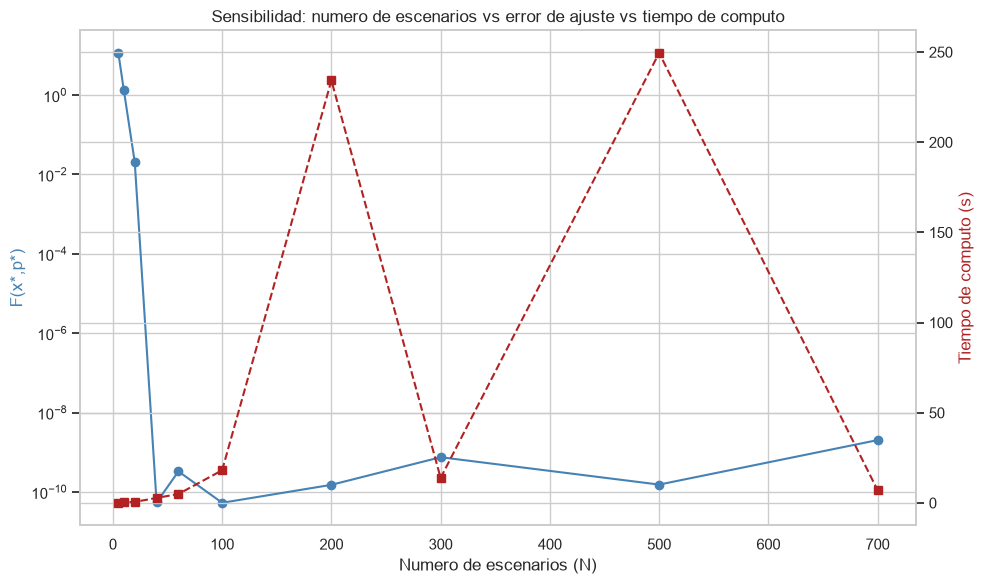

Modelo AMPL restaurado a N_SCENARIOS = 300 para las variantes A/B/C.
Suma de probabilidades: 1.000000000000
Probabilidad unica esperada: 0.003333333333
Error Frobenius covarianza generada vs objetivo: 2.507046e-08


,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN,ENELAM.SN,MALLPLAZA.SN,PARAUCO.SN,SMU.SN,SQM-B.SN
escenario,,,,,,,,,,
1,-0.014364,-0.011830,-0.011168,-0.053081,-0.018258,-0.003489,0.024961,0.006220,-0.052277,-0.096702
2,0.009588,-0.014476,-0.009562,-0.014339,-0.068647,-0.021913,0.016094,0.025494,0.011921,0.004167
3,0.003752,0.040162,0.043864,-0.013308,-0.020505,0.023060,-0.029608,0.003099,0.051675,0.103033
4,0.008797,-0.031662,-0.040888,0.017979,-0.017326,-0.022600,-0.017463,-0.022214,-0.013476,0.009442
5,-0.019109,0.090745,0.032236,0.010842,0.061584,0.020913,0.050206,0.049935,0.094416,0.047696
...,...,...,...,...,...,...,...,...,...,...
296,0.036833,-0.027390,-0.007300,-0.039766,-0.048389,-0.097646,-0.039872,0.000464,0.052432,-0.043772
297,-0.012087,-0.030878,-0.003533,-0.008865,-0.042805,-0.017406,-0.031633,-0.004513,-0.081009,0.026287
298,0.090635,0.018905,0.046178,0.125047,0.086701,0.015412,0.023449,0.022414,0.064938,0.122096


escenario,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
probabilidad,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,...,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333,0.003333


,M1,M2,M3,M4,M1_gen,M2_gen,M3_gen,M4_gen,skewness_gen,curtosis_exceso_gen,error_M1,error_M2,error_M3,error_M4
AGUAS-A.SN,0.002679,0.001875,0.000012,0.000027,0.002679,0.001875,0.000012,0.000027,0.142019,4.768952,-0.000000e+00,-6.300000e-09,0.0,-0.000000e+00
CENCOSUD.SN,0.005301,0.001957,-0.000018,0.000039,0.005301,0.001957,-0.000018,0.000039,-0.208020,7.103762,1.000000e-10,-6.600000e-09,-0.0,-0.000000e+00
CHILE.SN,0.003982,0.001372,0.000036,0.000010,0.003982,0.001372,0.000036,0.000010,0.707020,2.547816,-0.000000e+00,-4.400000e-09,-0.0,-0.000000e+00
CMPC.SN,0.000283,0.001915,0.000038,0.000020,0.000283,0.001915,0.000038,0.000020,0.455741,2.370006,-0.000000e+00,-6.500000e-09,-0.0,-0.000000e+00
COPEC.SN,0.001089,0.001897,-0.000055,0.000028,0.001089,0.001897,-0.000055,0.000028,-0.663216,4.708090,0.000000e+00,-6.300000e-09,0.0,-0.000000e+00
ENELAM.SN,-0.001202,0.001557,0.000046,0.000023,-0.001202,0.001557,0.000046,0.000023,0.748882,6.579709,-0.000000e+00,-5.000000e-09,0.0,-0.000000e+00
MALLPLAZA.SN,0.003889,0.002791,-0.000021,0.000055,0.003889,0.002791,-0.000021,0.000055,-0.143610,4.031350,0.000000e+00,-8.500000e-09,-0.0,-0.000000e+00
PARAUCO.SN,0.003450,0.002951,-0.000148,0.000098,0.003450,0.002951,-0.000148,0.000098,-0.920850,8.311485,0.000000e+00,-8.500000e-09,0.0,-1.000000e-10
SMU.SN,0.002559,0.001783,0.000053,0.000016,0.002559,0.001783,0.000053,0.000016,0.707424,1.978899,-0.000000e+00,-5.900000e-09,-0.0,-0.000000e+00
SQM-B.SN,0.006059,0.004116,0.000046,0.000081,0.006059,0.004116,0.000046,0.000081,0.173539,1.797213,-0.000000e+00,-1.530000e-08,0.0,-0.000000e+00


In [30]:
import time as _time

CANDIDATOS_N_ESCENARIOS = [5, 10, 20, 40, 60, 100, 200, 300, 500, 700]
N_STARTS_SENSIBILIDAD = 1  # subir a 2-3 si se dispone de mas tiempo de computo

registros_sensibilidad = []
for n_cand in CANDIDATOS_N_ESCENARIOS:
    print(f"\n=== Sensibilidad: N = {n_cand} escenarios ===")
    ampl.eval("reset;")
    ampl.eval(AMPL_MODEL)
    ampl.set["I"] = tickers
    ampl.set["S"] = list(range(1, n_cand + 1))
    ampl.param["N"] = n_cand
    ampl.param["M"] = momentos_target.rename(columns={"M1": 1, "M2": 2, "M3": 3, "M4": 4})
    ampl.param["C"] = cov_target
    ampl.param["w_m"] = wm
    ampl.param["w_c"] = wc
    ampl.param["x_lb"] = x_lb
    ampl.param["x_ub"] = x_ub
    ampl.option["solver"] = SOLVER
    ampl.option["presolve_eps"] = 1e-12
    if SOLVER in SOLVER_OPTIONS:
        ampl.option[f"{SOLVER}_options"] = SOLVER_OPTIONS[SOLVER]

    mejor_obj_n = np.inf
    t_inicio = _time.time()
    for start_id in range(N_STARTS_SENSIBILIDAD):
        x0_n = seleccionar_inicio_wiener(wiener_df, n_cand, start_id, RANDOM_SEED + 9000)

        lineas = []
        for activo in tickers:
            qa = ampl_q(activo)
            for s in range(1, n_cand + 1):
                valor = float(x0_n.loc[s, activo])
                lineas.append(f"let x[{qa},{s}] := {valor:.17g};")
        lineas.extend([
            "let {i in I} m[i,1] := sum {s in S} x[i,s] / N;",
            "let {i in I, k in 2..4} m[i,k] := sum {s in S} (x[i,s] - m[i,1])^k / N;",
            "let {i in I, l in I: ord(i) < ord(l)} cov[i,l] := sum {s in S} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) / N;",
        ])
        ampl.eval("\n".join(lineas))

        try:
            ampl.solve()
            obj_n = valor_objetivo(ampl)
        except Exception as exc:
            print(f"Fallo para N={n_cand}, start {start_id}: {exc}")
            obj_n = np.inf
        mejor_obj_n = min(mejor_obj_n, obj_n)
    t_fin = _time.time()

    registros_sensibilidad.append({
        "# de escenarios": n_cand,
        "F(x*,p*)": mejor_obj_n,
        "Tiempo (s)": t_fin - t_inicio,
    })
    print(f"N={n_cand}: F* = {mejor_obj_n:.6g} | tiempo = {t_fin - t_inicio:.1f} s")

tabla_sensibilidad_escenarios = pd.DataFrame(registros_sensibilidad)
display(tabla_sensibilidad_escenarios)

SALIDA_SENSIBILIDAD = DATA_DIR / "Sensibilidad_Num_Escenarios_MatchingMoment.csv"
tabla_sensibilidad_escenarios.to_csv(SALIDA_SENSIBILIDAD, index=False)
print(f"Tabla de sensibilidad guardada en: {SALIDA_SENSIBILIDAD}")

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(tabla_sensibilidad_escenarios["# de escenarios"], tabla_sensibilidad_escenarios["F(x*,p*)"], "o-", color="steelblue", label="F(x*,p*)")
ax1.set_yscale("log")
ax1.set_xlabel("Numero de escenarios (N)")
ax1.set_ylabel("F(x*,p*)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(tabla_sensibilidad_escenarios["# de escenarios"], tabla_sensibilidad_escenarios["Tiempo (s)"], "s--", color="firebrick", label="Tiempo (s)")
ax2.set_ylabel("Tiempo de computo (s)", color="firebrick")
ax1.set_title("Sensibilidad: numero de escenarios vs error de ajuste vs tiempo de computo")
fig.tight_layout()
plt.show()

# IMPORTANTE: el modelo AMPL vuelve a dejarse configurado para N_SCENARIOS (300)
# despues de este barrido, para que las secciones siguientes (variantes A/B/C)
# usen el tamano principal de la tesis.
ampl.eval("reset;")
ampl.eval(AMPL_MODEL)
ampl.set["I"] = tickers
ampl.set["S"] = list(range(1, N_SCENARIOS + 1))
ampl.param["N"] = N_SCENARIOS
ampl.param["M"] = momentos_target.rename(columns={"M1": 1, "M2": 2, "M3": 3, "M4": 4})
ampl.param["C"] = cov_target
ampl.param["w_m"] = wm
ampl.param["w_c"] = wc
ampl.param["x_lb"] = x_lb
ampl.param["x_ub"] = x_ub
ampl.option["solver"] = SOLVER
ampl.option["presolve_eps"] = 1e-12
if SOLVER in SOLVER_OPTIONS:
    ampl.option[f"{SOLVER}_options"] = SOLVER_OPTIONS[SOLVER]
print(f"Modelo AMPL restaurado a N_SCENARIOS = {N_SCENARIOS} para las variantes A/B/C.")
print(f"Suma de probabilidades: {probabilidades_mm.sum():.12f}")
print(f"Probabilidad unica esperada: {1 / N_SCENARIOS:.12f}")
print(f"Error Frobenius covarianza generada vs objetivo: {error_cov_fro:.8g}")

display(escenarios_mm)
display(probabilidades_mm.to_frame().T)
display(comparacion.round(10))

8. Chequeos rapidos
Estas comprobaciones ayudan a confirmar que se generaron 20 escenarios simultaneos y equiprobables.

In [31]:
assert escenarios_mm.shape == (N_SCENARIOS, len(tickers)), "La matriz de escenarios no tiene la forma esperada."
assert np.allclose(probabilidades_mm.to_numpy(), 1 / N_SCENARIOS), "Las probabilidades no quedaron equiprobables."
assert np.isclose(probabilidades_mm.sum(), 1.0), "Las probabilidades no suman 1."

print("Chequeos OK")
print(f"Forma de escenarios: {escenarios_mm.shape[0]} escenarios x {escenarios_mm.shape[1]} activos")
print(f"Probabilidad por escenario: {probabilidades_mm.iloc[0]:.6f}")

Chequeos OK
Forma de escenarios: 300 escenarios x 10 activos
Probabilidad por escenario: 0.003333


9. Modelos Matching Moment A, B y C
En esta seccion se generan las tres variantes de Matching Moment usando los momentos historicos completos como objetivo. La comparacion posterior se realiza contra la muestra historica completa y los modelos de portafolio usan los escenarios generados por Wiener y Matching Moment.

Modelo A: Matching Moment base equiprobable, ya resuelto en la seccion anterior.
Modelo B: Matching Moment con probabilidades variables acotadas alrededor de 1/N.
Modelo C: Matching Moment equiprobable con menor peso para los momentos 3 y 4.

In [32]:
# ---------------------------
# Modelos A, B y C con muestra historica completa
# ---------------------------
N_STARTS_VARIANTES = N_STARTS
P_MIN_MODELO_B = 0.50 / N_SCENARIOS
P_MAX_MODELO_B = 1.50 / N_SCENARIOS
PESOS_MODELO_C = {1: 1.0, 2: 1.0, 3: 0.25, 4: 0.10}


def construir_pesos_con_relativos(momentos_obj, cov_obj, pesos_momentos, peso_cov=1.0):
    wm_obj = pd.DataFrame(index=momentos_obj.index, columns=[1, 2, 3, 4], dtype=float)
    for k in [1, 2, 3, 4]:
        target = momentos_obj[f"M{k}"].abs()
        wm_obj[k] = pesos_momentos[k] / np.maximum(target**2, EPS_PESO)

    wc_obj = pd.DataFrame(index=cov_obj.index, columns=cov_obj.columns, dtype=float)
    for i in cov_obj.index:
        for l in cov_obj.columns:
            wc_obj.loc[i, l] = peso_cov / max(abs(cov_obj.loc[i, l]) ** 2, EPS_PESO)
    return wm_obj, wc_obj


def sample_probabilidades_acotadas(n, p_min, p_max, rng, max_iter=5000):
    if n * p_min > 1 or n * p_max < 1:
        raise ValueError("Las cotas de probabilidad no permiten que sumen 1.")
    base = np.repeat(1 / n, n)
    for _ in range(max_iter):
        candidato = rng.dirichlet(np.ones(n) * 2.0)
        candidato = 0.50 * candidato + 0.50 * base
        if candidato.min() >= p_min and candidato.max() <= p_max:
            return candidato
    return base


def crear_ampl_matching_variant(probabilidades_acotadas=False):
    modelo_prob = """
var p {s in S} >= p_min <= p_max;

s.t. prob_suma:
    sum {s in S} p[s] = 1;
""" if probabilidades_acotadas else """
var p {s in S} >= 0 <= 1;

s.t. prob_equiprobable {s in S}:
    p[s] = 1 / N;

s.t. prob_suma:
    sum {s in S} p[s] = 1;
"""
    params_prob = "param p_min >= 0;\nparam p_max <= 1;" if probabilidades_acotadas else ""

    modelo = f"""
reset;

set I ordered;
set S ordered;

param N integer > 0;
param M {{I, 1..4}};
param C {{I, I}};
param w_m {{I, 1..4}};
param w_c {{I, I}};
param x_lb {{I}};
param x_ub {{I}};
{params_prob}

var x {{i in I, s in S}} >= x_lb[i] <= x_ub[i];
{modelo_prob}
var m {{I, 1..4}};
var cov {{i in I, l in I: ord(i) < ord(l)}};

s.t. media_def {{i in I}}:
    m[i,1] = sum {{s in S}} x[i,s] * p[s];

s.t. momento_central_def {{i in I, k in 2..4}}:
    m[i,k] = sum {{s in S}} (x[i,s] - m[i,1])^k * p[s];

s.t. covarianza_def {{i in I, l in I: ord(i) < ord(l)}}:
    cov[i,l] = sum {{s in S}} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) * p[s];

minimize ErrorMatching:
      sum {{i in I, k in 1..4}} w_m[i,k] * (m[i,k] - M[i,k])^2
    + sum {{i in I, l in I: ord(i) < ord(l)}} w_c[i,l] * (cov[i,l] - C[i,l])^2;
"""
    a = AMPL()
    a.eval(modelo)
    a.set["I"] = tickers
    a.set["S"] = list(range(1, N_SCENARIOS + 1))
    a.param["N"] = N_SCENARIOS
    a.option["solver"] = SOLVER
    a.option["presolve_eps"] = 1e-12
    if SOLVER in SOLVER_OPTIONS:
        a.option[f"{SOLVER}_options"] = SOLVER_OPTIONS[SOLVER]
    return a


def cargar_parametros_variant(a, momentos_obj, cov_obj, pesos_momentos, wiener_inicio, probabilidades_acotadas=False):
    wm_obj, wc_obj = construir_pesos_con_relativos(momentos_obj, cov_obj, pesos_momentos)
    lb_obj, ub_obj = construir_cotas_desde_wiener(wiener_inicio, momentos_obj)
    a.param["M"] = momentos_obj.rename(columns={"M1": 1, "M2": 2, "M3": 3, "M4": 4})
    a.param["C"] = cov_obj
    a.param["w_m"] = wm_obj
    a.param["w_c"] = wc_obj
    a.param["x_lb"] = lb_obj
    a.param["x_ub"] = ub_obj
    if probabilidades_acotadas:
        a.param["p_min"] = P_MIN_MODELO_B
        a.param["p_max"] = P_MAX_MODELO_B


def inicializar_variant(a, x0, p0=None):
    lineas = []
    if p0 is not None:
        for s, ps in enumerate(p0, start=1):
            lineas.append(f"let p[{s}] := {float(ps):.17g};")

    for activo in tickers:
        qa = ampl_q(activo)
        for s in range(1, N_SCENARIOS + 1):
            valor = float(x0.loc[s, activo])
            lineas.append(f"let x[{qa},{s}] := {valor:.17g};")

    if p0 is None:
        lineas.extend([
            "let {i in I} m[i,1] := sum {s in S} x[i,s] / N;",
            "let {i in I, k in 2..4} m[i,k] := sum {s in S} (x[i,s] - m[i,1])^k / N;",
            "let {i in I, l in I: ord(i) < ord(l)} cov[i,l] := sum {s in S} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) / N;",
        ])
    else:
        lineas.extend([
            "let {i in I} m[i,1] := sum {s in S} x[i,s] * p[s];",
            "let {i in I, k in 2..4} m[i,k] := sum {s in S} (x[i,s] - m[i,1])^k * p[s];",
            "let {i in I, l in I: ord(i) < ord(l)} cov[i,l] := sum {s in S} (x[i,s] - m[i,1]) * (x[l,s] - m[l,1]) * p[s];",
        ])
    a.eval("\n".join(lineas))


def resolver_variante_matching(nombre, momentos_obj, cov_obj, wiener_inicio, pesos_momentos, probabilidades_acotadas=False, n_starts=N_STARTS_VARIANTES):
    print(f"\n================ {nombre} ================")
    a = crear_ampl_matching_variant(probabilidades_acotadas=probabilidades_acotadas)
    cargar_parametros_variant(a, momentos_obj, cov_obj, pesos_momentos, wiener_inicio, probabilidades_acotadas=probabilidades_acotadas)

    semilla_nombre = sum(ord(ch) for ch in nombre)
    rng = np.random.default_rng(RANDOM_SEED + semilla_nombre)
    registros = []
    best_local = None

    for start_id in range(n_starts):
        print(f"\n--- {nombre} multistart {start_id + 1}/{n_starts} ---")
        x0 = seleccionar_inicio_wiener(wiener_inicio, N_SCENARIOS, start_id, RANDOM_SEED + 3000)
        p0 = sample_probabilidades_acotadas(N_SCENARIOS, P_MIN_MODELO_B, P_MAX_MODELO_B, rng) if probabilidades_acotadas else None
        inicializar_variant(a, x0, p0=p0)

        try:
            a.solve()
            solve_result = str(a.solve_result)
            obj = float(a.get_value("ErrorMatching"))
            print(f"Resultado: {solve_result} | ErrorMatching = {obj:.10g}")
        except Exception as exc:
            solve_result = f"error: {type(exc).__name__}"
            obj = np.inf
            print(f"Fallo en start {start_id}: {exc}")

        registros.append({"modelo": nombre, "start": start_id, "solve_result": solve_result, "ErrorMatching": obj})

        if np.isfinite(obj) and (best_local is None or obj < best_local["ErrorMatching"]):
            best_local = {
                "modelo": nombre,
                "start": start_id,
                "solve_result": solve_result,
                "ErrorMatching": obj,
                "x": extraer_x(a),
                "p": extraer_p(a),
            }

    if best_local is None:
        raise RuntimeError(f"No hubo solucion util para {nombre}.")

    resumen = pd.DataFrame(registros).sort_values("ErrorMatching")
    return best_local, resumen


modelo_A = {
    "modelo": "A: MM p=1/N",
    "x": escenarios_mm,
    "p": probabilidades_mm,
    "ErrorMatching": best["ErrorMatching"] if "best" in globals() else np.nan,
}

best_modelo_B, resumen_modelo_B = resolver_variante_matching(
    "B: MM p variable acotada",
    momentos_target,
    cov_target,
    wiener_df,
    PESOS_RELATIVOS_MOMENTOS,
    probabilidades_acotadas=True,
)

best_modelo_C, resumen_modelo_C = resolver_variante_matching(
    "C: MM pesos M3/M4 bajos",
    momentos_target,
    cov_target,
    wiener_df,
    PESOS_MODELO_C,
    probabilidades_acotadas=False,
)

resumen_modelos_ABC = pd.concat(
    [
        pd.DataFrame([{"modelo": modelo_A["modelo"], "start": np.nan, "solve_result": "base", "ErrorMatching": modelo_A["ErrorMatching"]}]),
        resumen_modelo_B,
        resumen_modelo_C,
    ],
    ignore_index=True,
)
display(resumen_modelos_ABC.sort_values(["modelo", "ErrorMatching"]).style.format({"ErrorMatching": "{:.12g}"}))

SALIDA_RESUMEN_ABC = DATA_DIR / "Resumen_Modelos_A_B_C_historico.csv"
resumen_modelos_ABC.to_csv(SALIDA_RESUMEN_ABC, index=False)
print(f"Resumen modelos A/B/C guardado en: {SALIDA_RESUMEN_ABC}")


================ B: MM p variable acotada ================

--- B: MM p variable acotada multistart 1/4 ---
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

 
Ipopt 3.12.13: Optimal Solution Found

suffix ipopt_zU_out OUT;
suffix ipopt_zL_out OUT;
Resultado: solved | ErrorMatching = 9.848233173e-10

--- B: MM p variable acotada multistart 2/4 ---
Ipopt 3.12.13: outlev=0
max_iter=5000
tol=1e-8
acceptable_tol=1e-7
print_user_options=no


******************************************************************************
This program contains Ipopt, a library for large-sc

,modelo,start,solve_result,ErrorMatching
0,A: MM p=1/N,nan,base,1.1010692691e-10
1,B: MM p variable acotada,1.000000,solved,3.29744053162e-10
2,B: MM p variable acotada,0.000000,solved,9.84823317336e-10
3,B: MM p variable acotada,2.000000,solved,2.35963487218e-09
4,B: MM p variable acotada,3.000000,solved,1.06117730486e-08
5,C: MM pesos M3/M4 bajos,1.000000,solved,7.27623276027e-12
6,C: MM pesos M3/M4 bajos,2.000000,solved,1.13267036348e-11
7,C: MM pesos M3/M4 bajos,0.000000,solved,6.37298087641e-11
8,C: MM pesos M3/M4 bajos,3.000000,solved,6.55749124305e-10


Resumen modelos A/B/C guardado en: C:\Users\brand\Downloads\Resumen_Modelos_A_B_C_historico.csv


10. Graficos comparativos de escenarios
Los siguientes graficos evitan representar Matching Moment como puntos aislados. Se usan curvas ECDF, boxplots, errores promedio de momentos, errores de cuantiles y mapas de correlacion. Esto permite comparar de manera mas clara los escenarios Wiener y Matching Moment contra los retornos historicos.

Historico                                        Wiener  \
                 media  varianza  skewness curtosis_exceso     media   
AGUAS-A.SN    0.002679  0.001875  0.142018        4.768901  0.001760   
CENCOSUD.SN   0.005301  0.001957 -0.208019        7.103698  0.004727   
CHILE.SN      0.003982  0.001372  0.707016        2.547780  0.003571   
CMPC.SN       0.000283  0.001915  0.455738        2.369970 -0.000297   
COPEC.SN      0.001089  0.001897 -0.663212        4.708041  0.000528   
ENELAM.SN    -0.001202  0.001557  0.748878        6.579650 -0.002082   
MALLPLAZA.SN  0.003889  0.002791 -0.143609        4.031309  0.003359   
PARAUCO.SN    0.003450  0.002951 -0.920846        8.311426  0.002741   
SMU.SN        0.002559  0.001783  0.707420        1.978867  0.002290   
SQM-B.SN      0.006059  0.004116  0.173538        1.797178  0.004246   

                                                 Wiener (N=300)            \
              varianza  skewness curtosis_exceso          media  varianza   
AGUAS-A.SN    0.001892 -0.013187        0.171019       0.006764  0.001879   
CENCOSUD.SN   0.001999  0.006040       -0.045443       0.008575  0.001742   
CHILE.SN      0.001368 -0.054082       -0.026832       0.002640  0.001339   
CMPC.SN       0.001904 -0.024907        0.016490       0.002049  0.001873   
COPEC.SN      0.001863 -0.036734       -0.071454       0.001970  0.001796   
ENELAM.SN     0.001534  0.008527        0.082803      -0.000739  0.001567   
MALLPLAZA.SN  0.002792  0.008732       -0.044527       0.004462  0.002829   
PARAUCO.SN    0.002936  0.010765       -0.055250       0.004327  0.002898   
SMU.SN        0.001808  0.007867        0.036297       0.002089  0.001786   
SQM-B.SN      0.004096 -0.064441        0.005171       0.006212  0.004167   

              ... A: MM p=1/N                 B: MM p variable            \
              ...    skewness curtosis_exceso            media  varianza   
AGUAS-A.SN    ...    0.142019        4.768952         0.002679  0.001875   
CENCOSUD.SN   ...   -0.208020        7.103762         0.005301  0.001957   
CHILE.SN      ...    0.707020        2.547816         0.003982  0.001372   
CMPC.SN       ...    0.455741        2.370006         0.000283  0.001915   
COPEC.SN      ...   -0.663216        4.708090         0.001089  0.001897   
ENELAM.SN     ...    0.748882        6.579709        -0.001202  0.001557   
MALLPLAZA.SN  ...   -0.143610        4.031350         0.003889  0.002791   
PARAUCO.SN    ...   -0.920850        8.311485         0.003450  0.002951   
SMU.SN        ...    0.707424        1.978899         0.002559  0.001783   
SQM-B.SN      ...    0.173539        1.797213         0.006059  0.004116   

                                       C: MM M3/M4 bajos                      \
              skewness curtosis_exceso             media  varianza  skewness   
AGUAS-A.SN    0.142019        4.768982          0.002679  0.001875  0.142018   
CENCOSUD.SN  -0.208021        7.103803          0.005301  0.001957 -0.208019   
CHILE.SN      0.707022        2.547836          0.003982  0.001372  0.707017   
CMPC.SN       0.455742        2.370029          0.000283  0.001915  0.455739   
COPEC.SN     -0.663218        4.708125          0.001089  0.001897 -0.663213   
ENELAM.SN     0.748884        6.579744         -0.001202  0.001557  0.748879   
MALLPLAZA.SN -0.143611        4.031396          0.003889  0.002791 -0.143609   
PARAUCO.SN   -0.920855        8.311576          0.003450  0.002951 -0.920847   
SMU.SN        0.707426        1.978919          0.002559  0.001783  0.707421   
SQM-B.SN      0.173540        1.797243          0.006059  0.004116  0.173538   

                              
             curtosis_exceso  
AGUAS-A.SN          4.768909  
CENCOSUD.SN         7.103705  
CHILE.SN            2.547787  
CMPC.SN             2.369977  
COPEC.SN            4.708049  
ENELAM.SN           6.579656  
MALLPLAZA.SN        4.031317  
PARAUCO.SN          8.311427  
SMU.SN              1.978873  
SQM-B.SN

,modelo,metrica,MAE,Mediana_AE
0,Wiener,media,0.000724803,0.000577271
1,Wiener,varianza,1.92528e-05,1.84721e-05
2,Wiener,skewness,0.499932,0.553562
3,Wiener,curtosis_exceso,4.41285,4.33686
4,Wiener (N=300),media,0.00138825,0.000878762
5,Wiener (N=300),varianza,5.52218e-05,4.01817e-05
6,Wiener (N=300),skewness,0.477847,0.472108
7,Wiener (N=300),curtosis_exceso,4.45633,4.00734
8,A: MM p=1/N,media,1.68379e-11,9.7314e-12
9,A: MM p=1/N,varianza,7.3477e-09,6.41822e-09


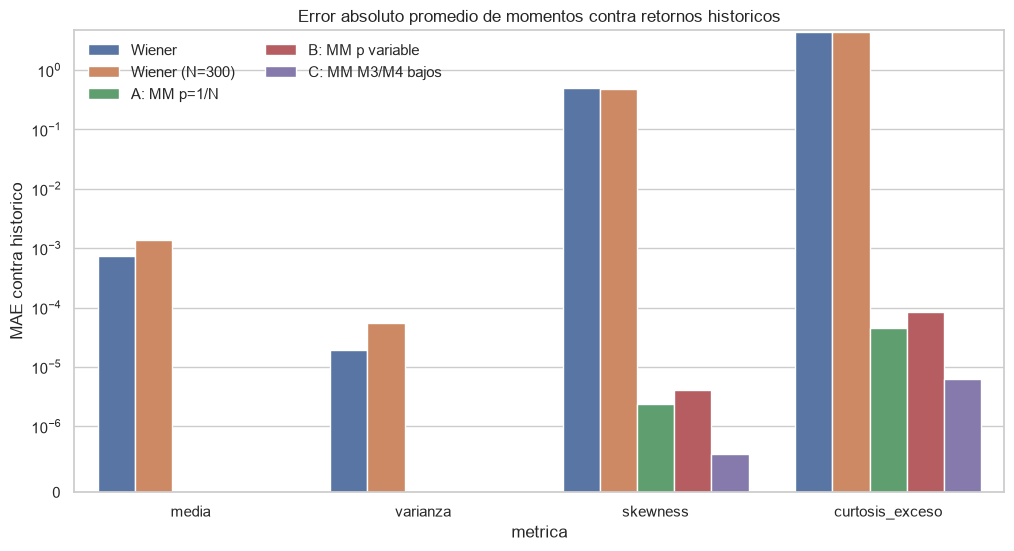

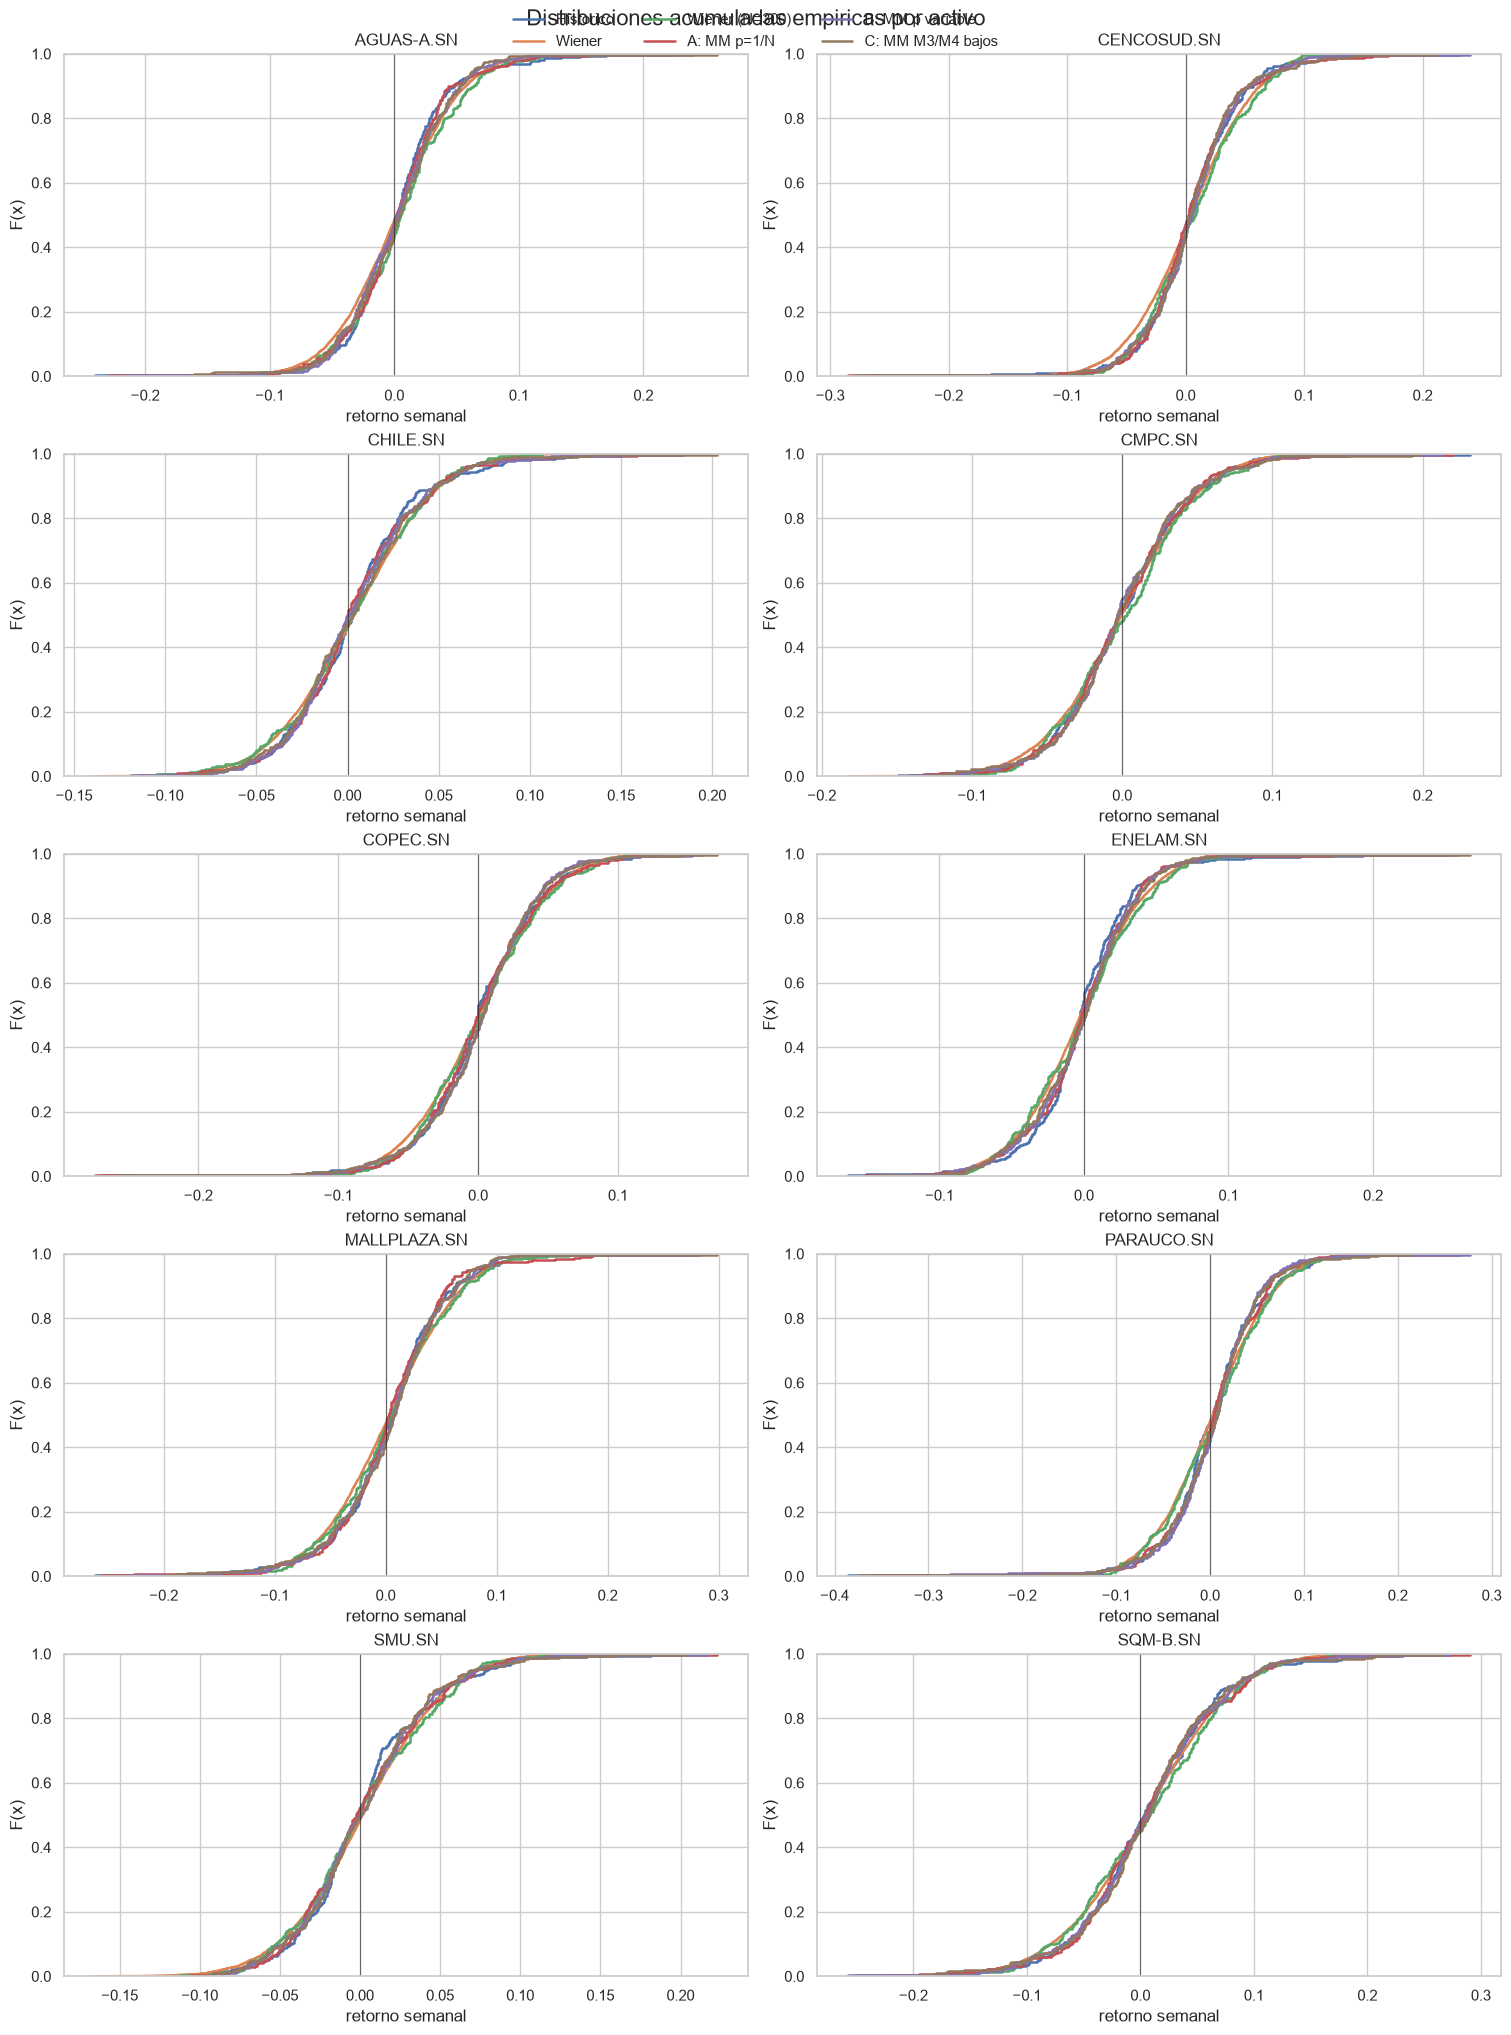

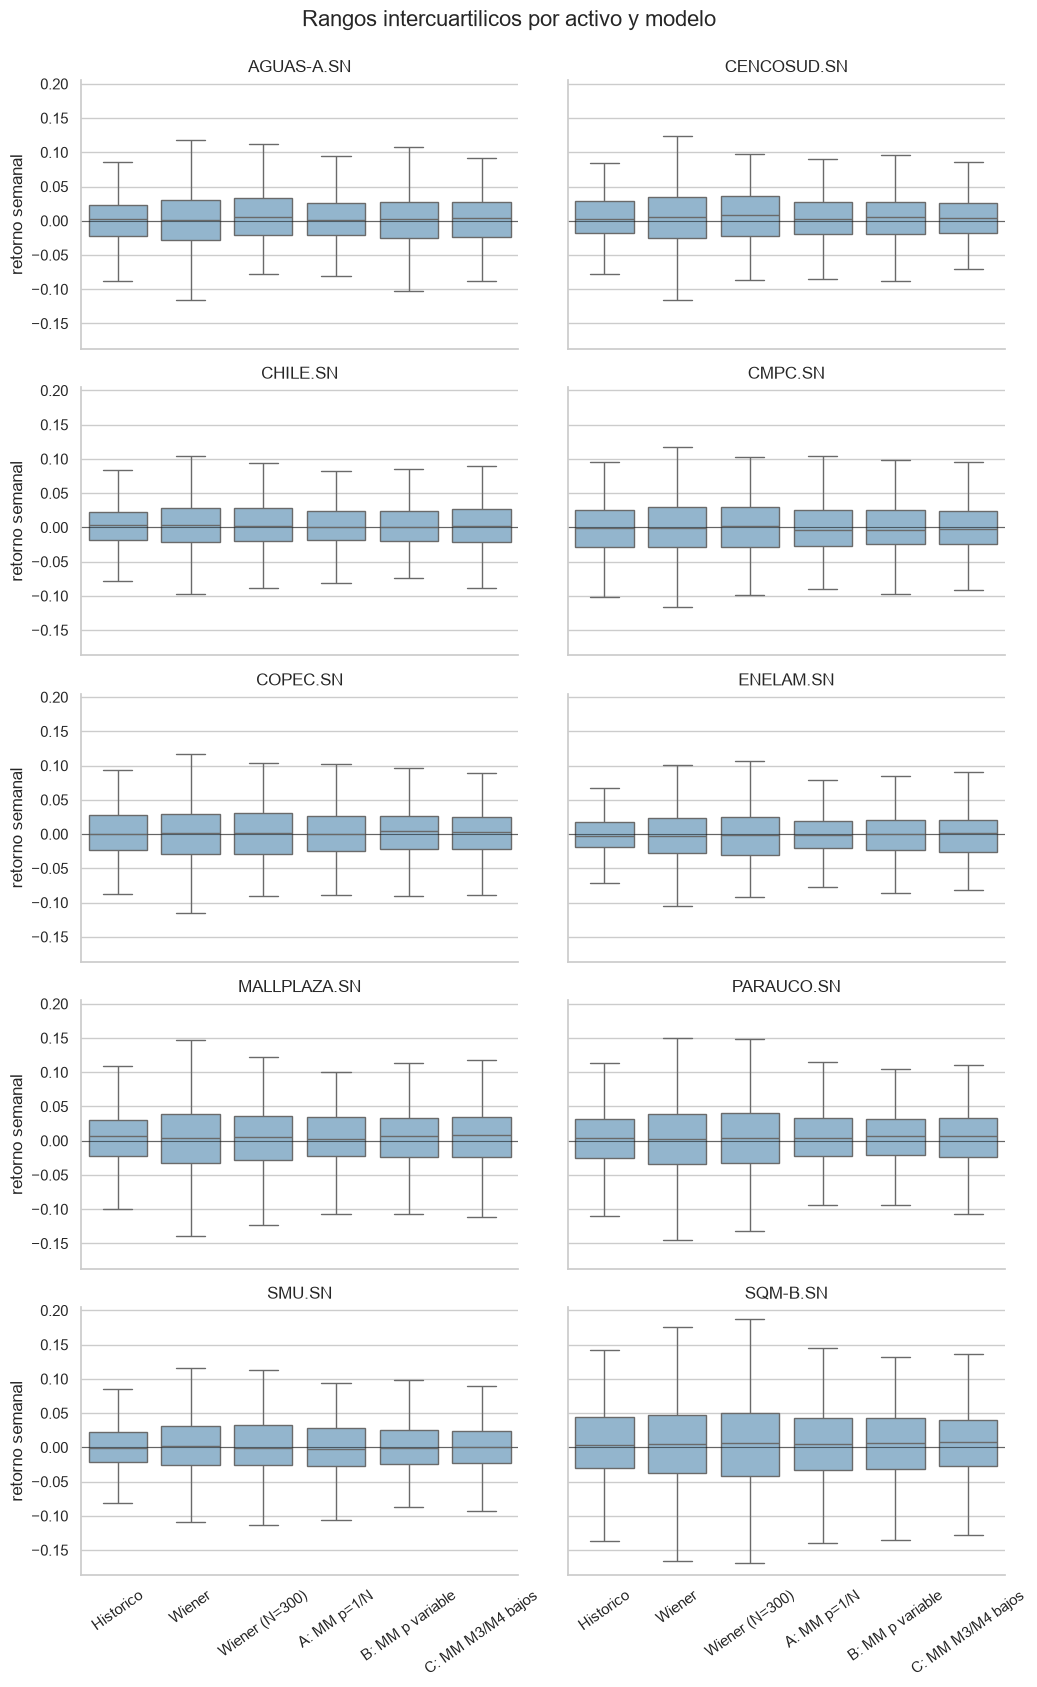

,modelo,cuantil,MAE_cuantil
0,Wiener,q05,0.00946214
1,Wiener,q50,0.00149361
2,Wiener,q95,0.00497981
3,Wiener (N=300),q05,0.00517961
4,Wiener (N=300),q50,0.00231123
5,Wiener (N=300),q95,0.00754388
6,A: MM p=1/N,q05,0.00322851
7,A: MM p=1/N,q50,0.00148683
8,A: MM p=1/N,q95,0.00596425
9,B: MM p variable,q05,0.00450473


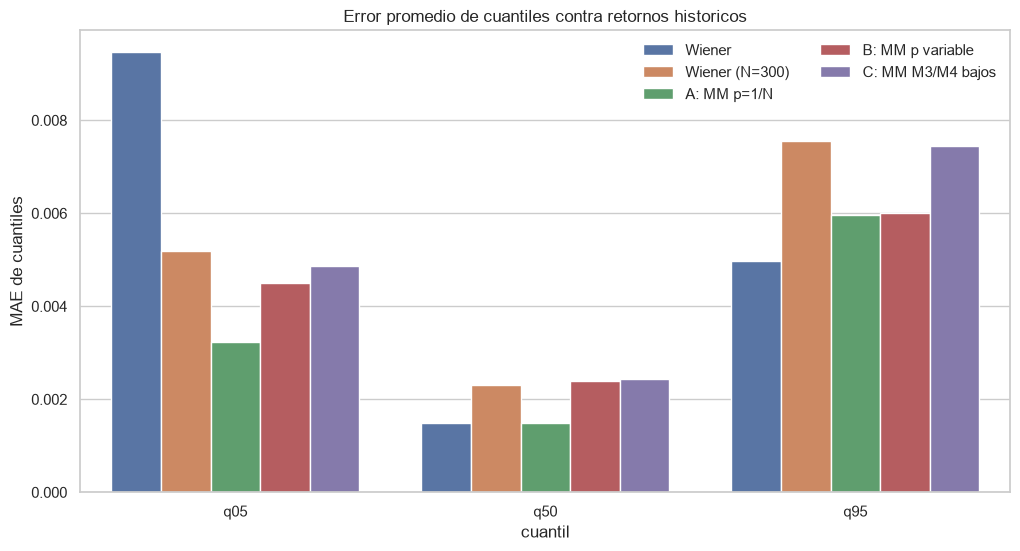

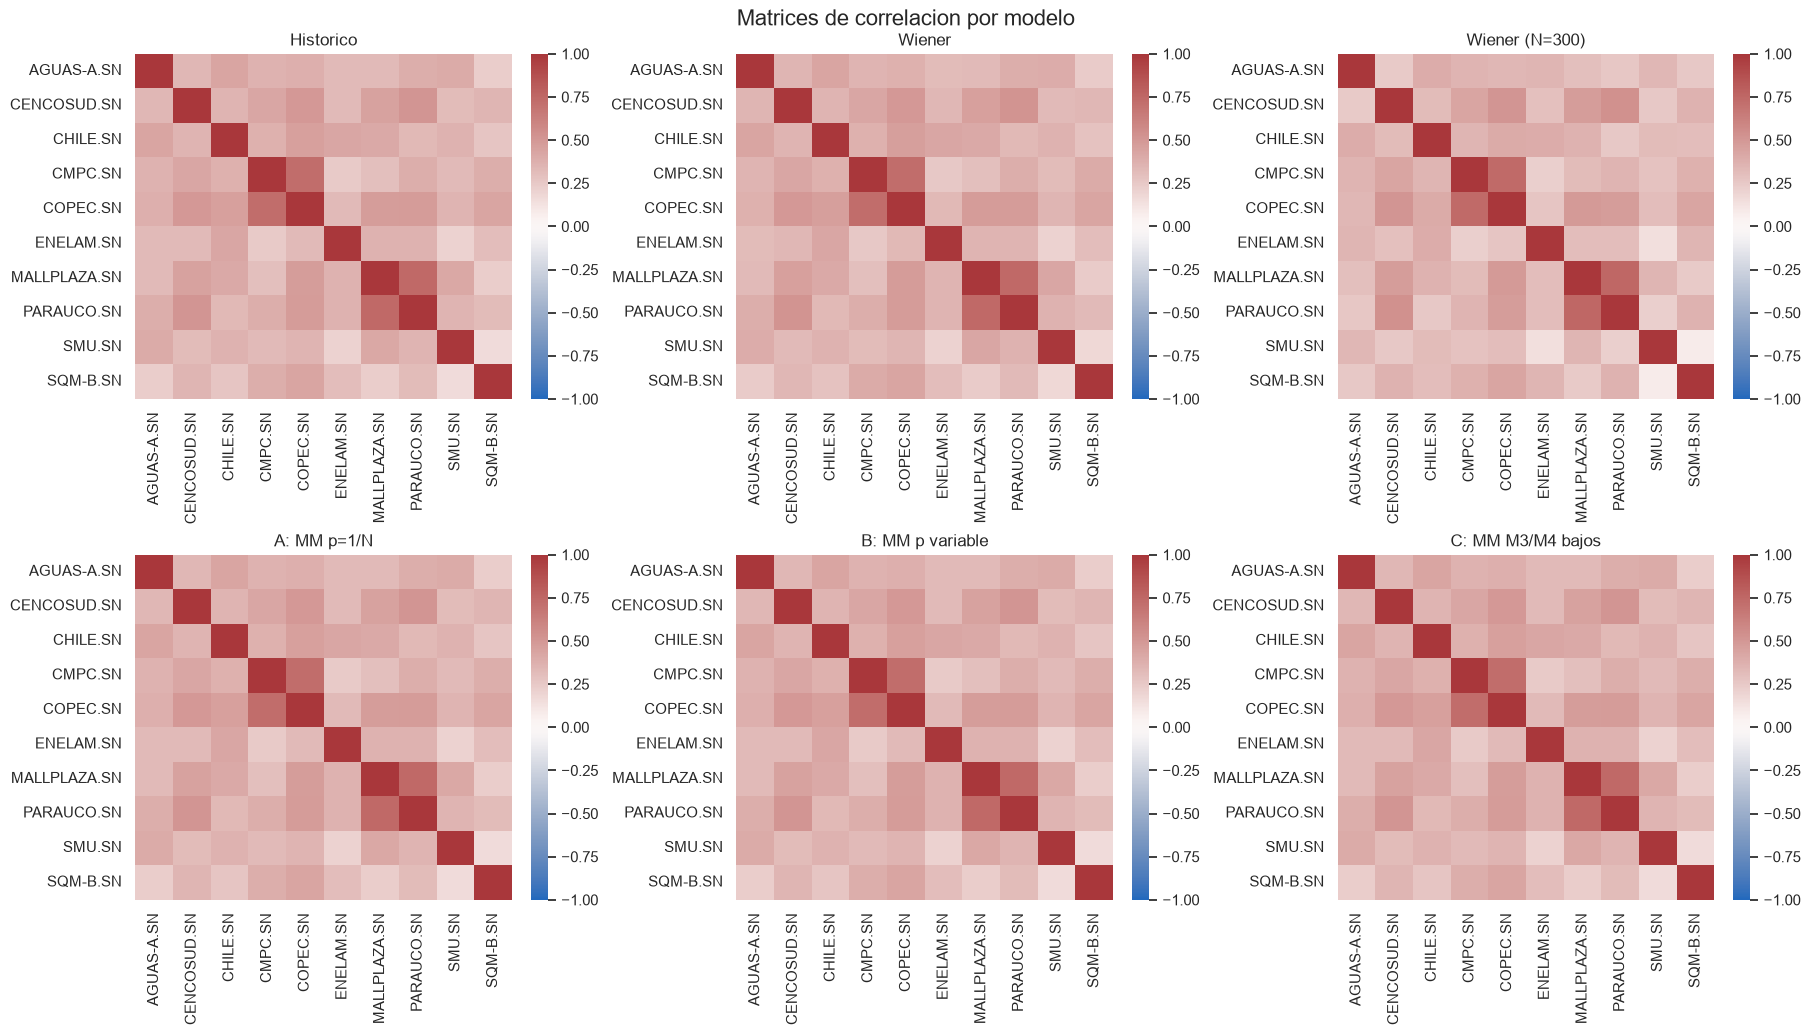

,modelo,n_escenarios,p_min,p_max,escenarios_efectivos
0,Historico,317,0.003155,0.003155,317.00
1,Wiener,8000,0.000125,0.000125,8000.00
2,Wiener (N=300),300,0.003333,0.003333,300.00
3,A: MM p=1/N,300,0.003333,0.003333,300.00
4,B: MM p variable,300,0.003285,0.004082,299.86
5,C: MM M3/M4 bajos,300,0.003333,0.003333,300.00


Comparacion de momentos guardada en: C:\Users\brand\Downloads\Comparacion_Escenarios_Historico_Wiener_MM.csv


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)


def normalizar_probabilidades(p, n):
    p = pd.Series(p, dtype=float).to_numpy()
    if len(p) != n:
        raise ValueError(f"Probabilidades de largo {len(p)} no coinciden con {n} escenarios.")
    return p / p.sum()


def momentos_resumen_desde_escenarios(x_df, p_series=None):
    x_df = x_df.loc[:, tickers].copy()
    if p_series is None:
        p = np.repeat(1 / len(x_df), len(x_df))
    else:
        p = normalizar_probabilidades(p_series, len(x_df))
    X = x_df.to_numpy(dtype=float)
    media = p @ X
    centrado = X - media
    m2 = p @ (centrado ** 2)
    m3 = p @ (centrado ** 3)
    m4 = p @ (centrado ** 4)
    return pd.DataFrame(
        {
            "media": media,
            "varianza": m2,
            "skewness": np.where(m2 > 0, m3 / np.power(m2, 1.5), np.nan),
            "curtosis_exceso": np.where(m2 > 0, m4 / np.power(m2, 2.0) - 3.0, np.nan),
        },
        index=tickers,
    )


def momentos_resumen_reales(retornos):
    return pd.DataFrame(
        {
            "media": retornos[tickers].mean(axis=0),
            "varianza": retornos[tickers].var(axis=0),
            "skewness": retornos[tickers].apply(skew, axis=0, bias=False, nan_policy="omit"),
            "curtosis_exceso": retornos[tickers].apply(kurtosis, axis=0, bias=False, fisher=True, nan_policy="omit"),
        }
    )


def covarianza_ponderada(x_df, p_series=None):
    x_df = x_df.loc[:, tickers].copy()
    if p_series is None:
        p = np.repeat(1 / len(x_df), len(x_df))
    else:
        p = normalizar_probabilidades(p_series, len(x_df))
    X = x_df.to_numpy(dtype=float)
    media = p @ X
    Xc = X - media
    cov = Xc.T @ (Xc * p[:, None])
    return pd.DataFrame(cov, index=tickers, columns=tickers)


def corr_from_cov(cov):
    std = np.sqrt(np.diag(cov.to_numpy(dtype=float)))
    std[std == 0] = np.nan
    corr = cov.to_numpy(dtype=float) / np.outer(std, std)
    return pd.DataFrame(corr, index=cov.index, columns=cov.columns)


def preparar_retornos_historicos():
    if "retornos_df" in globals():
        hist = retornos_df.T.copy()
    else:
        hist = pd.read_excel(DATA_DIR / "Retornos_Semanales_Acciones_Chilenas.xlsx", index_col=0).T
    hist.columns = [str(c).strip() for c in hist.columns]
    return hist.loc[:, tickers].apply(pd.to_numeric, errors="coerce").dropna(how="any")


retornos_historicos = preparar_retornos_historicos()

rng_comparacion_justa = np.random.default_rng(RANDOM_SEED)
idx_wiener_N = rng_comparacion_justa.choice(len(wiener_df), size=min(N_SCENARIOS, len(wiener_df)), replace=False)
wiener_df_N = wiener_df.iloc[idx_wiener_N].reset_index(drop=True)

modelos_escenarios = {
    "Historico": (retornos_historicos[tickers], pd.Series(np.repeat(1 / len(retornos_historicos), len(retornos_historicos)))),
    "Wiener": (wiener_df[tickers], pd.Series(np.repeat(1 / len(wiener_df), len(wiener_df)))),

    f"Wiener (N={N_SCENARIOS})": (wiener_df_N[tickers], pd.Series(np.repeat(1 / len(wiener_df_N), len(wiener_df_N)))),
    "A: MM p=1/N": (modelo_A["x"][tickers], modelo_A["p"]),
    "B: MM p variable": (best_modelo_B["x"][tickers], best_modelo_B["p"]),
    "C: MM M3/M4 bajos": (best_modelo_C["x"][tickers], best_modelo_C["p"]),
}

momentos_por_modelo = {}
for nombre, (x_mod, p_mod) in modelos_escenarios.items():
    if nombre == "Historico":
        momentos_por_modelo[nombre] = momentos_resumen_reales(x_mod)
    else:
        momentos_por_modelo[nombre] = momentos_resumen_desde_escenarios(x_mod, p_mod)

comparacion_momentos = pd.concat(momentos_por_modelo, axis=1)
display(comparacion_momentos.round(6))

# Error absoluto promedio por metrica contra historico.
metricas = ["media", "varianza", "skewness", "curtosis_exceso"]
filas_error = []
for nombre, momentos_mod in momentos_por_modelo.items():
    if nombre == "Historico":
        continue
    for metrica in metricas:
        err_abs = (momentos_mod[metrica] - momentos_por_modelo["Historico"][metrica]).abs()
        filas_error.append({"modelo": nombre, "metrica": metrica, "MAE": err_abs.mean(), "Mediana_AE": err_abs.median()})

errores_momentos = pd.DataFrame(filas_error)
display(errores_momentos.style.format({"MAE": "{:.6g}", "Mediana_AE": "{:.6g}"}))

plt.figure(figsize=(12, 6))
sns.barplot(data=errores_momentos, x="metrica", y="MAE", hue="modelo")
plt.yscale("symlog", linthresh=1e-6)
plt.title("Error absoluto promedio de momentos contra retornos historicos")
plt.xlabel("metrica")
plt.ylabel("MAE contra historico")
plt.legend(frameon=False, ncol=2)
plt.show()

# ECDF por activo: compara distribuciones sin usar puntos.
modelos_ecdf = ["Historico", "Wiener", "A: MM p=1/N", "B: MM p variable", "C: MM M3/M4 bajos"]

# Agregado desde V3_corregido: incluir Wiener remuestreado en ECDF y boxplots.
modelos_ecdf = ["Historico", "Wiener", f"Wiener (N={N_SCENARIOS})", "A: MM p=1/N", "B: MM p variable", "C: MM M3/M4 bajos"]
fig, axes = plt.subplots(5, 2, figsize=(15, 20), constrained_layout=True)
axes = axes.reshape(-1)
for ax, activo in zip(axes, tickers):
    for nombre in modelos_ecdf:
        x_mod, _ = modelos_escenarios[nombre]
        sns.ecdfplot(x=x_mod[activo].to_numpy(dtype=float), ax=ax, label=nombre, linewidth=1.8)
    ax.set_title(activo)
    ax.set_xlabel("retorno semanal")
    ax.set_ylabel("F(x)")
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
for ax in axes[len(tickers):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Distribuciones acumuladas empiricas por activo", y=1.01, fontsize=16)
plt.show()

# Boxplots sin puntos/fliers para evitar saturacion visual.
long_frames = []
for nombre in modelos_ecdf:
    x_mod, _ = modelos_escenarios[nombre]
    temp = x_mod[tickers].melt(var_name="activo", value_name="retorno")
    temp["modelo"] = nombre
    long_frames.append(temp)
retornos_long = pd.concat(long_frames, ignore_index=True)

g = sns.catplot(
    data=retornos_long,
    x="modelo",
    y="retorno",
    col="activo",
    col_wrap=2,
    kind="box",
    showfliers=False,
    height=3.2,
    aspect=1.6,
    color="#8ab6d6",
)
g.set_titles("{col_name}")
g.set_axis_labels("", "retorno semanal")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=35)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
g.fig.suptitle("Rangos intercuartilicos por activo y modelo", y=1.02, fontsize=16)
plt.show()

# Error de cuantiles: util para ver colas sin graficos solapados.
cuantiles = [0.05, 0.50, 0.95]
filas_q = []
q_hist = retornos_historicos[tickers].quantile(cuantiles).T
for nombre, (x_mod, _) in modelos_escenarios.items():
    if nombre == "Historico":
        continue
    q_mod = x_mod[tickers].quantile(cuantiles).T
    for q in cuantiles:
        err = (q_mod[q] - q_hist[q]).abs()
        filas_q.append({"modelo": nombre, "cuantil": f"q{int(q*100):02d}", "MAE_cuantil": err.mean()})

errores_cuantiles = pd.DataFrame(filas_q)
display(errores_cuantiles.style.format({"MAE_cuantil": "{:.6g}"}))

plt.figure(figsize=(12, 6))
sns.barplot(data=errores_cuantiles, x="cuantil", y="MAE_cuantil", hue="modelo")
plt.title("Error promedio de cuantiles contra retornos historicos")
plt.xlabel("cuantil")
plt.ylabel("MAE de cuantiles")
plt.legend(frameon=False, ncol=2)
plt.show()

# Correlaciones: historico vs modelos.
corrs = {nombre: corr_from_cov(covarianza_ponderada(x_mod, p_mod)) for nombre, (x_mod, p_mod) in modelos_escenarios.items()}
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.reshape(-1)
for ax, nombre in zip(axes, corrs.keys()):
    sns.heatmap(corrs[nombre], vmin=-1, vmax=1, center=0, cmap="vlag", ax=ax, cbar=True)
    ax.set_title(nombre)
for ax in axes[len(corrs):]:
    ax.axis("off")
fig.suptitle("Matrices de correlacion por modelo", y=1.02, fontsize=16)
plt.show()

# Tabla resumen de probabilidades.
prob_resumen = []
for nombre, (x_mod, p_mod) in modelos_escenarios.items():
    p_arr = normalizar_probabilidades(p_mod, len(x_mod))
    prob_resumen.append({
        "modelo": nombre,
        "n_escenarios": len(x_mod),
        "p_min": p_arr.min(),
        "p_max": p_arr.max(),
        "escenarios_efectivos": 1.0 / np.sum(p_arr**2),
    })
prob_resumen = pd.DataFrame(prob_resumen)
display(prob_resumen.style.format({"p_min": "{:.6f}", "p_max": "{:.6f}", "escenarios_efectivos": "{:.2f}"}))

SALIDA_COMPARACION_ESCENARIOS = DATA_DIR / "Comparacion_Escenarios_Historico_Wiener_MM.csv"
comparacion_momentos.to_csv(SALIDA_COMPARACION_ESCENARIOS)
print(f"Comparacion de momentos guardada en: {SALIDA_COMPARACION_ESCENARIOS}")

11. Optimizacion de portafolios
Esta seccion usa los escenarios generados por Wiener y Matching Moment A/B/C para resolver portafolios de minima varianza y CVaR. La evaluacion posterior se realiza contra los retornos historicos completos, por lo que debe interpretarse como una evaluacion historica descriptiva de los portafolios obtenidos.

In [34]:
from scipy.optimize import minimize, linprog

MAX_PESO_ACTIVO = 0.25
BETA_CVAR = 0.95

# La grilla de retorno minimo se construye de forma factible para cada modelo.
# Esto evita que un modelo como Wiener desaparezca por pedir un Rmin imposible.
N_RET_MINS_PORTAFOLIO = 7
RETORNO_MINIMO_INFERIOR = -0.01
FACTOR_SEGURIDAD_RMIN = 0.98
RETORNOS_MINIMOS_PORTAFOLIO = None  # se mantiene solo como referencia; se usa retornos_minimos_por_modelo.


def media_cov_ponderada(x_df, p):
    X = x_df[tickers].to_numpy(dtype=float)
    p = normalizar_probabilidades(p, len(x_df))
    mu = p @ X
    Xc = X - mu
    cov = Xc.T @ (Xc * p[:, None])
    return mu, cov


def retorno_maximo_factible(mu, w_max=MAX_PESO_ACTIVO):
    orden = np.argsort(mu)[::-1]
    restante = 1.0
    ret = 0.0
    for idx in orden:
        asignar = min(w_max, restante)
        ret += asignar * mu[idx]
        restante -= asignar
        if restante <= 1e-12:
            break
    return ret


def generar_retornos_minimos_factibles(
    x_df,
    p,
    n_puntos=N_RET_MINS_PORTAFOLIO,
    r_min_inferior=RETORNO_MINIMO_INFERIOR,
    factor_seguridad=FACTOR_SEGURIDAD_RMIN,
    w_max=MAX_PESO_ACTIVO,
):
    """Crea una grilla de Rmin que queda por debajo del maximo factible del modelo."""
    mu, _ = media_cov_ponderada(x_df, p)
    r_max = retorno_maximo_factible(mu, w_max=w_max)

    # Dejar una holgura para no caer justo en el borde de factibilidad numerica.
    holgura = max(abs(r_max) * (1.0 - factor_seguridad), 1e-8)
    r_sup = r_max - holgura

    # Si el maximo factible es muy bajo, ajusta tambien el extremo inferior.
    if r_min_inferior >= r_sup:
        r_inf = r_sup - max(abs(r_sup) * 0.5, 1e-4)
    else:
        r_inf = r_min_inferior

    rmins = np.linspace(r_inf, r_sup, n_puntos)

    rmins = np.array(sorted(set(np.round(rmins.astype(float), 10))))
    return rmins, float(r_max), mu


def optimizar_markowitz(x_df, p, r_min, w_max=MAX_PESO_ACTIVO):
    mu, cov = media_cov_ponderada(x_df, p)
    n = len(mu)
    if r_min > retorno_maximo_factible(mu, w_max) + 1e-10:
        return None, "infeasible_return"
    cov_reg = cov + np.eye(n) * 1e-10
    x0 = np.repeat(1 / n, n)
    bounds = [(0.0, w_max) for _ in range(n)]
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w, mu=mu, r_min=r_min: float(mu @ w - r_min)},
    ]
    res = minimize(
        lambda w: float(w @ cov_reg @ w),
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000, "disp": False},
    )
    if not res.success:
        return None, res.message
    w = np.clip(res.x, 0, w_max)
    w = w / w.sum()
    if mu @ w < r_min - 1e-7:
        return None, "return_constraint_not_satisfied"
    return w, "solved"


def optimizar_cvar(x_df, p, r_min, beta=BETA_CVAR, w_max=MAX_PESO_ACTIVO):
    X = x_df[tickers].to_numpy(dtype=float)
    p = normalizar_probabilidades(p, len(x_df))
    mu = p @ X
    n_esc, n_assets = X.shape
    if r_min > retorno_maximo_factible(mu, w_max) + 1e-10:
        return None, "infeasible_return"

    n_vars = n_assets + 1 + n_esc
    c = np.zeros(n_vars)
    c[n_assets] = 1.0
    c[n_assets + 1:] = p / (1.0 - beta)

    A_eq = np.zeros((1, n_vars))
    A_eq[0, :n_assets] = 1.0
    b_eq = np.array([1.0])

    A_ub = []
    b_ub = []
    row_ret = np.zeros(n_vars)
    row_ret[:n_assets] = -mu
    A_ub.append(row_ret)
    b_ub.append(-r_min)

    for s in range(n_esc):
        row = np.zeros(n_vars)
        row[:n_assets] = -X[s, :]
        row[n_assets] = -1.0
        row[n_assets + 1 + s] = -1.0
        A_ub.append(row)
        b_ub.append(0.0)

    bounds = [(0.0, w_max) for _ in range(n_assets)] + [(None, None)] + [(0.0, None) for _ in range(n_esc)]
    res = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub), A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        return None, res.message
    w = np.clip(res.x[:n_assets], 0, w_max)
    w = w / w.sum()
    if mu @ w < r_min - 1e-7:
        return None, "return_constraint_not_satisfied"
    return w, "solved"


def cvar_perdida_desde_retornos(retornos, beta=BETA_CVAR):
    r = pd.Series(retornos, dtype=float).dropna()
    if len(r) == 0:
        return np.nan, np.nan
    perdidas = -r
    var_loss = perdidas.quantile(beta)
    cola = perdidas[perdidas >= var_loss]
    cvar_loss = cola.mean() if len(cola) else np.nan
    return float(var_loss), float(cvar_loss)


def max_drawdown(retornos):
    r = pd.Series(retornos, dtype=float).dropna()
    riqueza = (1.0 + r).cumprod()
    drawdown = riqueza / riqueza.cummax() - 1.0
    return float(drawdown.min())


def metricas_escenario_portafolio(x_df, p, w):
    p = normalizar_probabilidades(p, len(x_df))
    r_s = x_df[tickers].to_numpy(dtype=float) @ w
    mu_p = float(p @ r_s)
    var_p = float(p @ ((r_s - mu_p) ** 2))
    var_loss, cvar_loss = cvar_perdida_desde_retornos(pd.Series(r_s), beta=BETA_CVAR)
    return mu_p, var_p, var_loss, cvar_loss


def metricas_historicas_portafolio(retornos_hist_df, w):
    r = retornos_hist_df[tickers].to_numpy(dtype=float) @ w
    r = pd.Series(r, index=retornos_hist_df.index, name="retorno_portafolio")
    var_loss, cvar_loss = cvar_perdida_desde_retornos(r, beta=BETA_CVAR)
    return {
        "ret_promedio_hist": float(r.mean()),
        "ret_acumulado_hist": float((1.0 + r).prod() - 1.0),
        "volatilidad_hist": float(r.std(ddof=1)),
        "VaR95_perdida_hist": var_loss,
        "CVaR95_perdida_hist": cvar_loss,
        "max_drawdown_hist": max_drawdown(r),
    }, r


modelos_portafolio = {k: v for k, v in modelos_escenarios.items() if k != "Historico"}



_SOLO_COMPARACION_ESTADISTICA = {"Historico"}
modelos_portafolio = {k: v for k, v in modelos_escenarios.items() if k not in _SOLO_COMPARACION_ESTADISTICA}
retornos_minimos_por_modelo = {}
resumen_factibilidad_rmin = []

print("Modelos para optimizacion de portafolios:")
for nombre, (x_mod, p_mod) in modelos_portafolio.items():
    p_arr = normalizar_probabilidades(p_mod, len(x_mod))
    rmins_modelo, r_max_factible, mu_modelo = generar_retornos_minimos_factibles(x_mod, p_mod)
    retornos_minimos_por_modelo[nombre] = rmins_modelo
    resumen_factibilidad_rmin.append({
        "modelo_escenarios": nombre,
        "n_escenarios": len(x_mod),
        "p_min": p_arr.min(),
        "p_max": p_arr.max(),
        "retorno_maximo_factible": r_max_factible,
        "rmin_min_usado": rmins_modelo.min(),
        "rmin_max_usado": rmins_modelo.max(),
        "n_rmin": len(rmins_modelo),
    })
    print(
        f"- {nombre}: {len(x_mod)} escenarios, p_min={p_arr.min():.6f}, p_max={p_arr.max():.6f}, "
        f"Rmin usado=[{rmins_modelo.min():.4%}, {rmins_modelo.max():.4%}], "
        f"max factible={r_max_factible:.4%}"
    )

resumen_factibilidad_rmin = pd.DataFrame(resumen_factibilidad_rmin)
display(resumen_factibilidad_rmin.round(6))


Modelos para optimizacion de portafolios:
- Wiener: 8000 escenarios, p_min=0.000125, p_max=0.000125, Rmin usado=[-1.0000%, 0.3896%], max factible=0.3976%
- Wiener (N=300): 300 escenarios, p_min=0.003333, p_max=0.003333, Rmin usado=[-1.0000%, 0.6373%], max factible=0.6503%
- A: MM p=1/N: 300 escenarios, p_min=0.003333, p_max=0.003333, Rmin usado=[-1.0000%, 0.4712%], max factible=0.4808%
- B: MM p variable: 300 escenarios, p_min=0.003285, p_max=0.004082, Rmin usado=[-1.0000%, 0.4712%], max factible=0.4808%
- C: MM M3/M4 bajos: 300 escenarios, p_min=0.003333, p_max=0.003333, Rmin usado=[-1.0000%, 0.4712%], max factible=0.4808%


,modelo_escenarios,n_escenarios,p_min,p_max,retorno_maximo_factible,rmin_min_usado,rmin_max_usado,n_rmin
0,Wiener,8000,0.000125,0.000125,0.003976,-0.01,0.003896,7
1,Wiener (N=300),300,0.003333,0.003333,0.006503,-0.01,0.006373,7
2,A: MM p=1/N,300,0.003333,0.003333,0.004808,-0.01,0.004712,7
3,B: MM p variable,300,0.003285,0.004082,0.004808,-0.01,0.004712,7
4,C: MM M3/M4 bajos,300,0.003333,0.003333,0.004808,-0.01,0.004712,7


12. Resolver portafolios y evaluar historicamente
Se resuelven portafolios para cada generador de escenarios y luego se calculan metricas historicas usando los retornos reales completos. Esta evaluacion permite comparar el comportamiento de los portafolios, sin separar periodos de entrenamiento y prueba.

In [37]:
filas_portafolios = []
pesos_portafolios = []
series_historicas_portafolio = {}

for nombre_modelo, (x_mod, p_mod) in modelos_portafolio.items():
    print(f"\n================ {nombre_modelo} ================")
    rmins_modelo = retornos_minimos_por_modelo[nombre_modelo]
    print("Rmin factibles usados:", ", ".join(f"{r:.2%}" for r in rmins_modelo))
    for r_min in rmins_modelo:
        for metodo in ["Markowitz", "CVaR"]:
            if metodo == "Markowitz":
                w, status = optimizar_markowitz(x_mod, p_mod, r_min)
            else:
                w, status = optimizar_cvar(x_mod, p_mod, r_min)

            if w is None:
                filas_portafolios.append({
                    "modelo_escenarios": nombre_modelo,
                    "metodo": metodo,
                    "retorno_minimo": r_min,
                    "status": status,
                })
                continue

            ret_esc, var_esc, var_loss_esc, cvar_loss_esc = metricas_escenario_portafolio(x_mod, p_mod, w)
            metricas_hist, serie_r = metricas_historicas_portafolio(retornos_historicos, w)
            key = (nombre_modelo, metodo, float(r_min))
            series_historicas_portafolio[key] = serie_r

            fila = {
                "modelo_escenarios": nombre_modelo,
                "metodo": metodo,
                "retorno_minimo": r_min,
                "status": status,
                "ret_esperado_esc": ret_esc,
                "varianza_esc": var_esc,
                "volatilidad_esc": math.sqrt(max(var_esc, 0.0)),
                "VaR95_perdida_esc": var_loss_esc,
                "CVaR95_perdida_esc": cvar_loss_esc,
                **metricas_hist,
            }
            filas_portafolios.append(fila)

            for activo, peso in zip(tickers, w):
                pesos_portafolios.append({
                    "modelo_escenarios": nombre_modelo,
                    "metodo": metodo,
                    "retorno_minimo": r_min,
                    "activo": activo,
                    "peso": float(peso),
                })

resultados_portafolios = pd.DataFrame(filas_portafolios)
pesos_portafolios_df = pd.DataFrame(pesos_portafolios)

print("Portafolios resueltos:", (resultados_portafolios["status"] == "solved").sum())
print("Portafolios no resueltos/infeasibles:", (resultados_portafolios["status"] != "solved").sum())
display(resultados_portafolios.sort_values(["modelo_escenarios", "metodo", "retorno_minimo"]).round(6))

SALIDA_PORT_RESULTADOS = DATA_DIR / "Resultados_Portafolios_Historico.csv"
SALIDA_PORT_PESOS = DATA_DIR / "Pesos_Portafolios_Historico.csv"
resultados_portafolios.to_csv(SALIDA_PORT_RESULTADOS, index=False)
pesos_portafolios_df.to_csv(SALIDA_PORT_PESOS, index=False)
print(f"Resultados de portafolios guardados en: {SALIDA_PORT_RESULTADOS}")
print(f"Pesos de portafolios guardados en: {SALIDA_PORT_PESOS}")


================ Wiener ================
Rmin factibles usados: -1.00%, -0.77%, -0.54%, -0.31%, -0.07%, 0.16%, 0.39%

================ Wiener (N=300) ================
Rmin factibles usados: -1.00%, -0.73%, -0.45%, -0.18%, 0.09%, 0.36%, 0.64%

================ A: MM p=1/N ================
Rmin factibles usados: -1.00%, -0.75%, -0.51%, -0.26%, -0.02%, 0.23%, 0.47%

================ B: MM p variable ================
Rmin factibles usados: -1.00%, -0.75%, -0.51%, -0.26%, -0.02%, 0.23%, 0.47%

================ C: MM M3/M4 bajos ================
Rmin factibles usados: -1.00%, -0.75%, -0.51%, -0.26%, -0.02%, 0.23%, 0.47%
Portafolios resueltos: 70
Portafolios no resueltos/infeasibles: 0


,modelo_escenarios,metodo,retorno_minimo,status,ret_esperado_esc,varianza_esc,volatilidad_esc,VaR95_perdida_esc,CVaR95_perdida_esc,ret_promedio_hist,ret_acumulado_hist,volatilidad_hist,VaR95_perdida_hist,CVaR95_perdida_hist,max_drawdown_hist
29,A: MM p=1/N,CVaR,-0.010000,solved,0.002762,0.000804,0.028363,0.043357,0.052934,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
31,A: MM p=1/N,CVaR,-0.007548,solved,0.002762,0.000804,0.028363,0.043357,0.052934,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
33,A: MM p=1/N,CVaR,-0.005096,solved,0.002762,0.000804,0.028363,0.043357,0.052934,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
35,A: MM p=1/N,CVaR,-0.002644,solved,0.002762,0.000804,0.028363,0.043357,0.052934,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
37,A: MM p=1/N,CVaR,-0.000192,solved,0.002762,0.000804,0.028363,0.043357,0.054211,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,Wiener (N=300),Markowitz,-0.004542,solved,0.002935,0.000703,0.026510,0.037574,0.048728,0.002151,0.750374,0.027787,0.038566,0.059654,-0.306866
20,Wiener (N=300),Markowitz,-0.001813,solved,0.002935,0.000703,0.026510,0.037574,0.048728,0.002151,0.750374,0.027787,0.038566,0.059654,-0.306866
22,Wiener (N=300),Markowitz,0.000915,solved,0.002935,0.000703,0.026510,0.037574,0.048728,0.002151,0.750374,0.027787,0.038566,0.059654,-0.306866
24,Wiener (N=300),Markowitz,0.003644,solved,0.003644,0.000711,0.026656,0.037668,0.049296,0.002553,0.982927,0.028089,0.037344,0.060324,-0.308663


Resultados de portafolios guardados en: C:\Users\brand\Downloads\Resultados_Portafolios_Historico.csv
Pesos de portafolios guardados en: C:\Users\brand\Downloads\Pesos_Portafolios_Historico.csv


Prueba real enero-mayo 2026
Esta seccion descarga los precios reales posteriores al periodo usado para construir los escenarios y evalua los portafolios ya obtenidos entre enero y mayo de 2026. La comparacion permite observar que portafolio tuvo mayor retorno acumulado real y cual presento menor riesgo de cola en ese periodo.

Descargando precios reales para evaluar enero-mayo 2026...
Semanas evaluadas: 21


Ticker,AGUAS-A.SN,CENCOSUD.SN,CHILE.SN,CMPC.SN,COPEC.SN,ENELAM.SN,MALLPLAZA.SN,PARAUCO.SN,SMU.SN,SQM-B.SN
Date,,,,,,,,,,
2026-01-05,0.001351,0.067918,0.038464,0.014264,0.036775,0.015820,0.060971,0.077187,0.064039,0.066087
2026-01-12,0.022942,-0.009588,-0.026194,-0.003463,0.050477,-0.023531,0.075110,0.098026,-0.030062,0.042465
2026-01-19,0.018206,-0.015812,0.067618,-0.063896,0.012987,-0.003482,0.041096,0.087650,0.012360,0.066172
2026-01-26,-0.002332,-0.040984,0.064459,-0.008333,-0.044872,-0.036098,0.000000,-0.009333,0.004908,-0.080163
2026-02-02,0.021818,0.059829,-0.052716,0.054240,-0.037584,-0.035026,-0.021316,-0.009448,-0.013981,-0.087858


Benchmark igual ponderado enero-mayo 2026:


,modelo_escenarios,metodo,retorno_minimo,ret_esperado_esc,volatilidad_esc,CVaR95_perdida_esc,semanas_eval_2026,ret_promedio_ene_may_2026,ret_acumulado_ene_may_2026,volatilidad_ene_may_2026,VaR95_perdida_ene_may_2026,CVaR95_perdida_ene_may_2026,max_drawdown_ene_may_2026
0,Benchmark igual ponderado,Igual ponderado,NaN,NaN,NaN,NaN,21,0.000241,-0.00141,0.025478,0.034537,0.039959,-0.116243


Portafolio con mayor retorno acumulado real en enero-mayo 2026:


...

Portafolio con menor CVaR 95% de perdida real en enero-mayo 2026:


,modelo_escenarios,metodo,retorno_minimo,ret_esperado_esc,volatilidad_esc,CVaR95_perdida_esc,semanas_eval_2026,ret_promedio_ene_may_2026,ret_acumulado_ene_may_2026,volatilidad_ene_may_2026,VaR95_perdida_ene_may_2026,CVaR95_perdida_ene_may_2026,max_drawdown_ene_may_2026,score_retorno_riesgo_2026
0,B: MM p variable,CVaR,0.00226,0.00226,0.028747,0.054715,21,-0.001424,-0.033817,0.0212,0.025184,0.02989,-0.106869,-1.595139


Top 10 por retorno acumulado real enero-mayo 2026, incluyendo benchmark igual ponderado:


,modelo_escenarios,metodo,retorno_minimo,ret_esperado_esc,volatilidad_esc,CVaR95_perdida_esc,semanas_eval_2026,ret_promedio_ene_may_2026,ret_acumulado_ene_may_2026,volatilidad_ene_may_2026,VaR95_perdida_ene_may_2026,CVaR95_perdida_ene_may_2026,max_drawdown_ene_may_2026,score_retorno_riesgo_2026
0,Wiener,CVaR,0.003896,0.003896,0.034126,0.066800,21,0.001867,0.031089,0.029310,0.037201,0.043571,-0.116179,1.060691
1,C: MM M3/M4 bajos,CVaR,0.004712,0.004712,0.033943,0.073740,21,0.001847,0.030687,0.029264,0.036927,0.043245,-0.114860,1.048648
2,B: MM p variable,CVaR,0.004712,0.004712,0.033943,0.070689,21,0.001847,0.030687,0.029264,0.036927,0.043245,-0.114860,1.048648
3,Wiener,Markowitz,0.003896,0.003896,0.034115,0.066840,21,0.001818,0.030096,0.029213,0.036836,0.043086,-0.114516,1.030217
4,A: MM p=1/N,Markowitz,0.004712,0.004712,0.033923,0.066781,21,0.001794,0.029625,0.029112,0.036894,0.043565,-0.114971,1.017605
5,C: MM M3/M4 bajos,Markowitz,0.004712,0.004712,0.033923,0.074177,21,0.001794,0.029625,0.029112,0.036894,0.043565,-0.114971,1.017605
6,B: MM p variable,Markowitz,0.004712,0.004712,0.033923,0.071331,21,0.001794,0.029625,0.029112,0.036894,0.043565,-0.114971,1.017605
7,A: MM p=1/N,CVaR,0.004712,0.004712,0.033923,0.066778,21,0.001792,0.029579,0.029106,0.036892,0.043579,-0.114976,1.016229
8,Wiener (N=300),Markowitz,0.006373,0.006373,0.034150,0.064082,21,0.000876,0.009482,0.029868,0.043180,0.052227,-0.113216,0.317453
9,Wiener (N=300),CVaR,0.006373,0.006373,0.034270,0.062618,21,0.000880,0.008979,0.030778,0.046107,0.055242,-0.117863,0.291732


Resultados enero-mayo 2026 guardados en: C:\Users\brand\Downloads\Resultados_Portafolios_Enero_Mayo_2026.csv
Resultados con benchmark guardados en: C:\Users\brand\Downloads\Resultados_Portafolios_Enero_Mayo_2026_con_Benchmark.csv
Ranking por ganancia guardado en: C:\Users\brand\Downloads\Ranking_Portafolios_Ganancia_Enero_Mayo_2026.csv


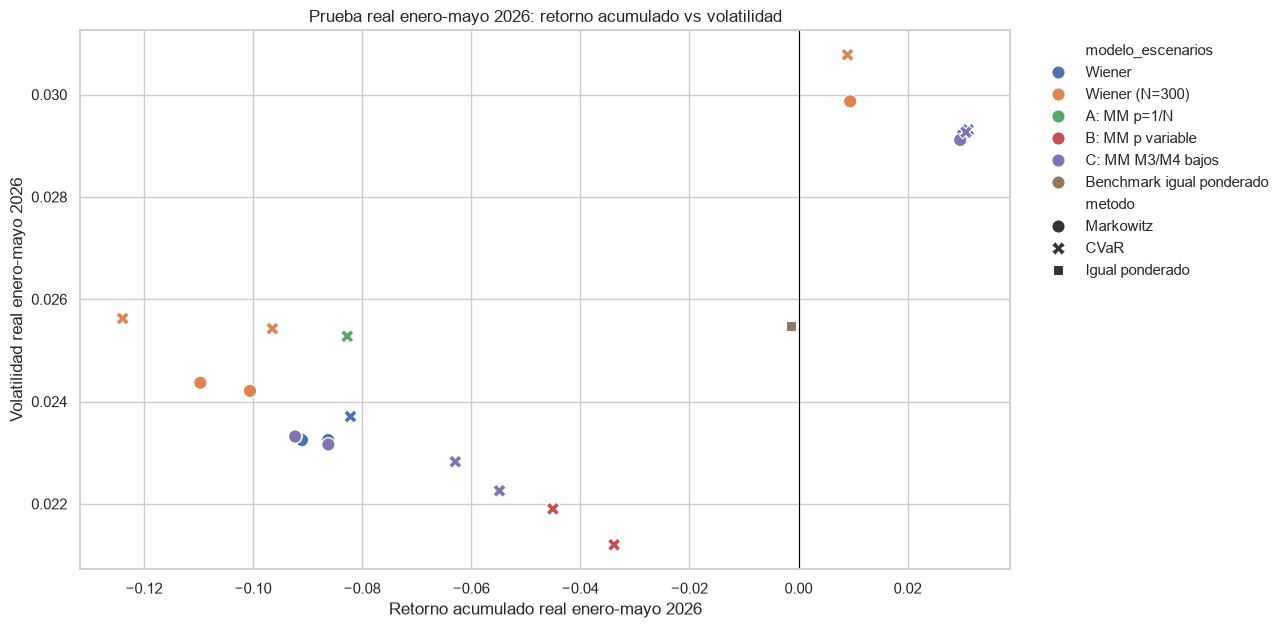

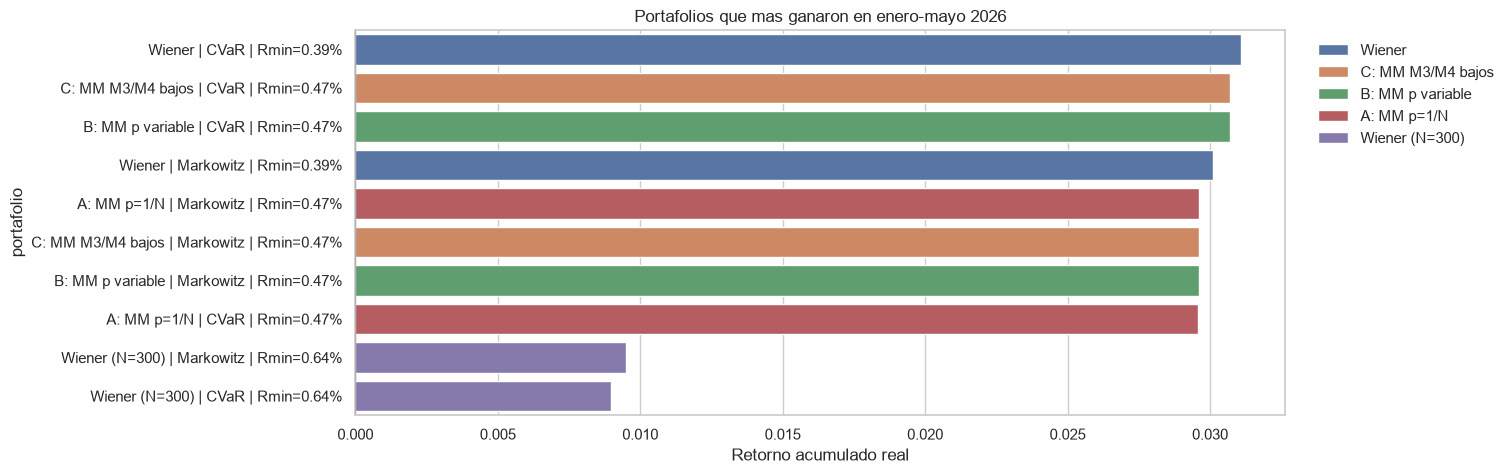

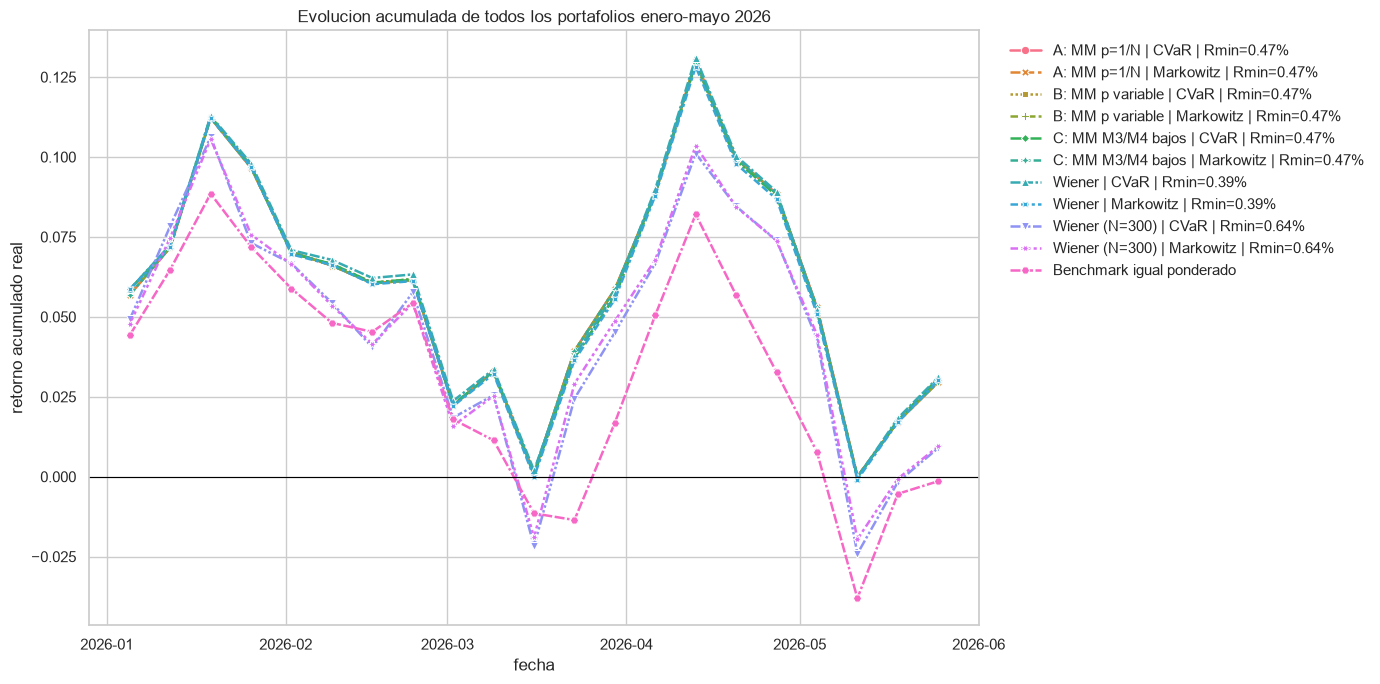

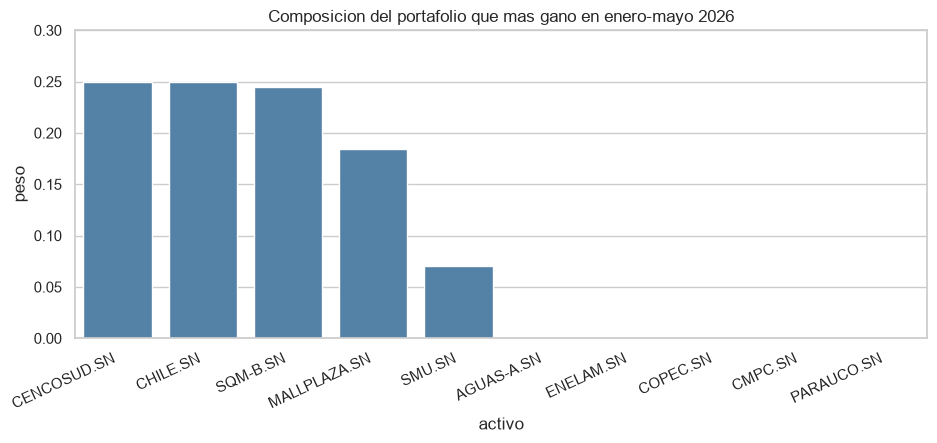

In [38]:
# ---------------------------
# Evaluacion real posterior: enero a mayo de 2026
# ---------------------------
FECHA_INICIO_EVAL_2026 = "2026-01-01"
FECHA_FIN_EVAL_2026 = "2026-06-01"  # limite superior: cubre enero a mayo de 2026
FECHA_INICIO_DESCARGA_EVAL_2026 = "2025-12-01"  # permite calcular el primer retorno semanal de enero

res_solved = resultados_portafolios[resultados_portafolios["status"] == "solved"].copy()
if res_solved.empty:
    raise RuntimeError("No hay portafolios resueltos para evaluar en enero-mayo 2026.")

print("Descargando precios reales para evaluar enero-mayo 2026...")
datos_eval_2026 = yf.download(
    tickers,
    start=FECHA_INICIO_DESCARGA_EVAL_2026,
    end=FECHA_FIN_EVAL_2026,
    interval="1wk",
    auto_adjust=False,
    progress=False,
)

if isinstance(datos_eval_2026.columns, pd.MultiIndex):
    nivel_precios = "Adj Close" if "Adj Close" in datos_eval_2026.columns.get_level_values(0) else "Close"
    precios_eval_2026 = datos_eval_2026[nivel_precios].copy()
else:
    precios_eval_2026 = datos_eval_2026.copy()

precios_eval_2026 = precios_eval_2026.reindex(columns=tickers).dropna(how="all").ffill()
retornos_eval_2026 = precios_eval_2026.pct_change().dropna(how="all")
retornos_eval_2026.index = pd.to_datetime(retornos_eval_2026.index)
retornos_eval_2026 = retornos_eval_2026.loc[
    (retornos_eval_2026.index >= FECHA_INICIO_EVAL_2026)
    & (retornos_eval_2026.index < FECHA_FIN_EVAL_2026)
]
retornos_eval_2026 = retornos_eval_2026.reindex(columns=tickers).dropna(how="any")

if retornos_eval_2026.empty:
    raise RuntimeError("No se obtuvieron retornos reales para enero-mayo 2026. Revisa la conexion o disponibilidad de Yahoo Finance.")

print(f"Semanas evaluadas: {len(retornos_eval_2026)}")
display(retornos_eval_2026.head())


def metricas_reales_2026(w):
    r = retornos_eval_2026[tickers].to_numpy(dtype=float) @ w
    serie = pd.Series(r, index=retornos_eval_2026.index, name="retorno_portafolio")
    var_loss, cvar_loss = cvar_perdida_desde_retornos(serie, beta=BETA_CVAR)
    vol = float(serie.std(ddof=1)) if len(serie) > 1 else np.nan
    ret_acum = float((1.0 + serie).prod() - 1.0)
    return {
        "semanas_eval_2026": len(serie),
        "ret_promedio_ene_may_2026": float(serie.mean()),
        "ret_acumulado_ene_may_2026": ret_acum,
        "volatilidad_ene_may_2026": vol,
        "VaR95_perdida_ene_may_2026": var_loss,
        "CVaR95_perdida_ene_may_2026": cvar_loss,
        "max_drawdown_ene_may_2026": max_drawdown(serie),
    }, serie


# Recuperar los pesos de cada portafolio resuelto.
pesos_wide = (
    pesos_portafolios_df
    .pivot_table(index=["modelo_escenarios", "metodo", "retorno_minimo"], columns="activo", values="peso", aggfunc="first")
    .reset_index()
)

portafolios_eval = res_solved[["modelo_escenarios", "metodo", "retorno_minimo", "ret_esperado_esc", "volatilidad_esc", "CVaR95_perdida_esc"]].merge(
    pesos_wide,
    on=["modelo_escenarios", "metodo", "retorno_minimo"],
    how="inner",
)

filas_eval_2026 = []
series_eval_2026 = {}
for _, row in portafolios_eval.iterrows():
    w = row[tickers].to_numpy(dtype=float)
    metricas_2026, serie_2026 = metricas_reales_2026(w)
    key = (row["modelo_escenarios"], row["metodo"], float(row["retorno_minimo"]))
    series_eval_2026[key] = serie_2026
    filas_eval_2026.append({
        "modelo_escenarios": row["modelo_escenarios"],
        "metodo": row["metodo"],
        "retorno_minimo": row["retorno_minimo"],
        "ret_esperado_esc": row["ret_esperado_esc"],
        "volatilidad_esc": row["volatilidad_esc"],
        "CVaR95_perdida_esc": row["CVaR95_perdida_esc"],
        **metricas_2026,
    })

resultados_eval_2026 = pd.DataFrame(filas_eval_2026)
resultados_eval_2026["score_retorno_riesgo_2026"] = resultados_eval_2026["ret_acumulado_ene_may_2026"] / resultados_eval_2026["volatilidad_ene_may_2026"].replace(0, np.nan)

# Benchmark: portafolio igual ponderado con las mismas acciones del estudio.
w_equal_2026 = np.repeat(1.0 / len(tickers), len(tickers))
metricas_equal_2026, serie_equal_2026 = metricas_reales_2026(w_equal_2026)
benchmark_equal_2026 = pd.DataFrame([{
    "modelo_escenarios": "Benchmark igual ponderado",
    "metodo": "Igual ponderado",
    "retorno_minimo": np.nan,
    "ret_esperado_esc": np.nan,
    "volatilidad_esc": np.nan,
    "CVaR95_perdida_esc": np.nan,
    **metricas_equal_2026,
}])
resultados_eval_2026_con_benchmark = pd.concat([resultados_eval_2026, benchmark_equal_2026], ignore_index=True)
resultados_eval_2026_con_benchmark["score_retorno_riesgo_2026"] = (
    resultados_eval_2026_con_benchmark["ret_acumulado_ene_may_2026"]
    / resultados_eval_2026_con_benchmark["volatilidad_ene_may_2026"].replace(0, np.nan)
)

ranking_ganancia_2026 = resultados_eval_2026.sort_values("ret_acumulado_ene_may_2026", ascending=False).reset_index(drop=True)
ranking_cvar_2026 = resultados_eval_2026.sort_values("CVaR95_perdida_ene_may_2026", ascending=True).reset_index(drop=True)
ranking_score_2026 = resultados_eval_2026.sort_values("score_retorno_riesgo_2026", ascending=False).reset_index(drop=True)
ranking_ganancia_2026_con_benchmark = resultados_eval_2026_con_benchmark.sort_values("ret_acumulado_ene_may_2026", ascending=False).reset_index(drop=True)

print("Benchmark igual ponderado enero-mayo 2026:")
display(benchmark_equal_2026.round(6))

print("Portafolio con mayor retorno acumulado real en enero-mayo 2026:")
display(ranking_ganancia_2026.head(1).round(6))

print("Portafolio con menor CVaR 95% de perdida real en enero-mayo 2026:")
display(ranking_cvar_2026.head(1).round(6))

print("Top 10 por retorno acumulado real enero-mayo 2026, incluyendo benchmark igual ponderado:")
display(ranking_ganancia_2026_con_benchmark.head(10).round(6))

SALIDA_EVAL_2026 = DATA_DIR / "Resultados_Portafolios_Enero_Mayo_2026.csv"
SALIDA_EVAL_2026_BENCHMARK = DATA_DIR / "Resultados_Portafolios_Enero_Mayo_2026_con_Benchmark.csv"
SALIDA_RANKING_GANANCIA_2026 = DATA_DIR / "Ranking_Portafolios_Ganancia_Enero_Mayo_2026.csv"
resultados_eval_2026.to_csv(SALIDA_EVAL_2026, index=False)
resultados_eval_2026_con_benchmark.to_csv(SALIDA_EVAL_2026_BENCHMARK, index=False)
ranking_ganancia_2026_con_benchmark.to_csv(SALIDA_RANKING_GANANCIA_2026, index=False)
print(f"Resultados enero-mayo 2026 guardados en: {SALIDA_EVAL_2026}")
print(f"Resultados con benchmark guardados en: {SALIDA_EVAL_2026_BENCHMARK}")
print(f"Ranking por ganancia guardado en: {SALIDA_RANKING_GANANCIA_2026}")

# Grafico 1: retorno real vs riesgo real en enero-mayo 2026.
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=resultados_eval_2026_con_benchmark,
    x="ret_acumulado_ene_may_2026",
    y="volatilidad_ene_may_2026",
    hue="modelo_escenarios",
    style="metodo",
    s=90,
)
plt.title("Prueba real enero-mayo 2026: retorno acumulado vs volatilidad")
plt.xlabel("Retorno acumulado real enero-mayo 2026")
plt.ylabel("Volatilidad real enero-mayo 2026")
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# Grafico 2: ranking de ganancia real.
top_ganancia_2026 = ranking_ganancia_2026_con_benchmark.head(10).copy()
top_ganancia_2026["portafolio"] = np.where(
    top_ganancia_2026["modelo_escenarios"].eq("Benchmark igual ponderado"),
    "Benchmark igual ponderado",
    top_ganancia_2026["modelo_escenarios"] + " | "
    + top_ganancia_2026["metodo"] + " | Rmin="
    + top_ganancia_2026["retorno_minimo"].map(lambda x: f"{x:.2%}"),
)
plt.figure(figsize=(12, max(5, 0.45 * len(top_ganancia_2026))))
sns.barplot(data=top_ganancia_2026, y="portafolio", x="ret_acumulado_ene_may_2026", hue="modelo_escenarios", dodge=False)
plt.title("Portafolios que mas ganaron en enero-mayo 2026")
plt.xlabel("Retorno acumulado real")
plt.ylabel("portafolio")
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# Grafico 3: evolucion acumulada de todos los portafolios evaluados.
series_todos_2026 = []
for _, row in ranking_ganancia_2026.head(10).sort_values(["modelo_escenarios", "metodo", "retorno_minimo"]).iterrows():
    key = (row["modelo_escenarios"], row["metodo"], float(row["retorno_minimo"]))
    serie = series_eval_2026.get(key)
    if serie is None:
        continue
    curva = (1.0 + serie).cumprod() - 1.0
    etiqueta = f'{row["modelo_escenarios"]} | {row["metodo"]} | Rmin={row["retorno_minimo"]:.2%}'
    tmp = curva.rename("retorno_acumulado").reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "fecha"})
    tmp["portafolio"] = etiqueta
    series_todos_2026.append(tmp)

curva_benchmark_todos = (1.0 + serie_equal_2026).cumprod() - 1.0
tmp_benchmark_todos = curva_benchmark_todos.rename("retorno_acumulado").reset_index()
tmp_benchmark_todos = tmp_benchmark_todos.rename(columns={tmp_benchmark_todos.columns[0]: "fecha"})
tmp_benchmark_todos["portafolio"] = "Benchmark igual ponderado"
series_todos_2026.append(tmp_benchmark_todos)

if series_todos_2026:
    curvas_todos_2026 = pd.concat(series_todos_2026, ignore_index=True)
    orden_portafolios_todos = curvas_todos_2026["portafolio"].drop_duplicates().tolist()
    paleta_todos = dict(zip(orden_portafolios_todos, sns.color_palette("husl", n_colors=len(orden_portafolios_todos))))
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=curvas_todos_2026,
        x="fecha",
        y="retorno_acumulado",
        hue="portafolio",
        hue_order=orden_portafolios_todos,
       palette=paleta_todos,
        style="portafolio",
markers=True,
dashes=True,
linewidth=1.8,
    )
    plt.title("Evolucion acumulada de todos los portafolios enero-mayo 2026")
    plt.xlabel("fecha")
    plt.ylabel("retorno acumulado real")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Grafico 4: pesos del portafolio ganador por retorno acumulado.
ganador_2026 = ranking_ganancia_2026.head(1)[["modelo_escenarios", "metodo", "retorno_minimo"]]
pesos_ganador_2026 = pesos_portafolios_df.merge(ganador_2026, on=["modelo_escenarios", "metodo", "retorno_minimo"], how="inner")
if not pesos_ganador_2026.empty:
    plt.figure(figsize=(11, 4))
    sns.barplot(data=pesos_ganador_2026.sort_values("peso", ascending=False), x="activo", y="peso", color="steelblue")
    plt.title("Composicion del portafolio que mas gano en enero-mayo 2026")
    plt.xlabel("activo")
    plt.ylabel("peso")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, max(0.30, pesos_ganador_2026["peso"].max() * 1.15))
    plt.show()


Graficos de portafolios
Estos graficos comparan fronteras estimadas por escenarios y metricas historicas de los portafolios. Se evitan graficos con demasiados puntos superpuestos y se incluyen tablas ranking para facilitar la interpretacion.

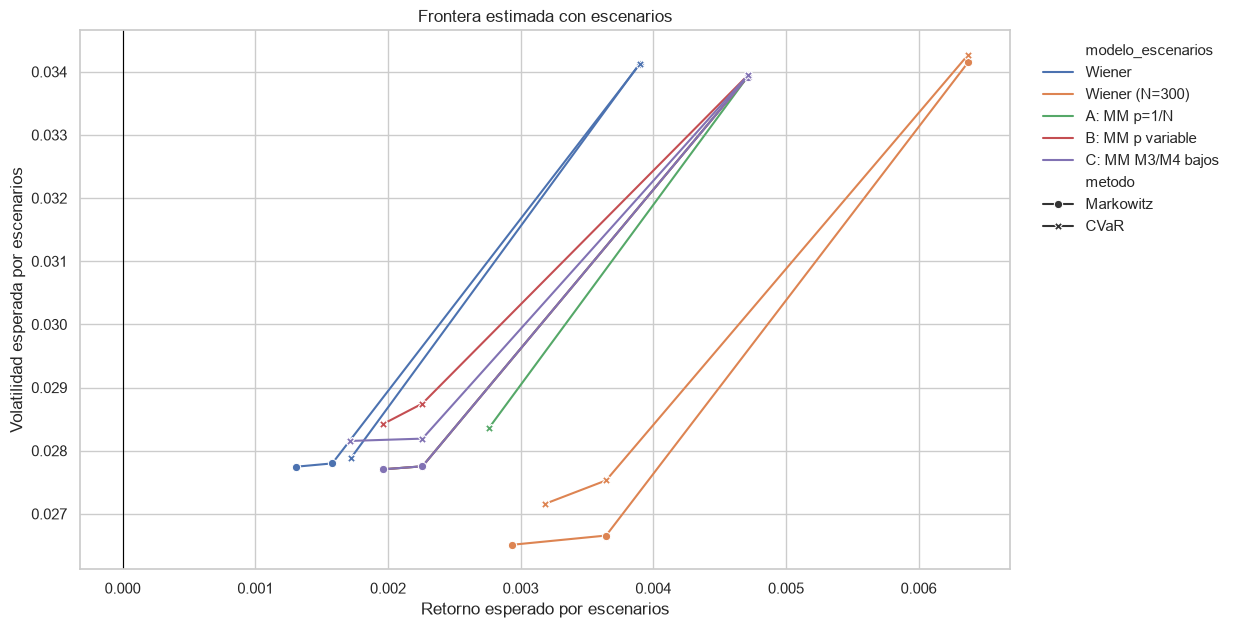

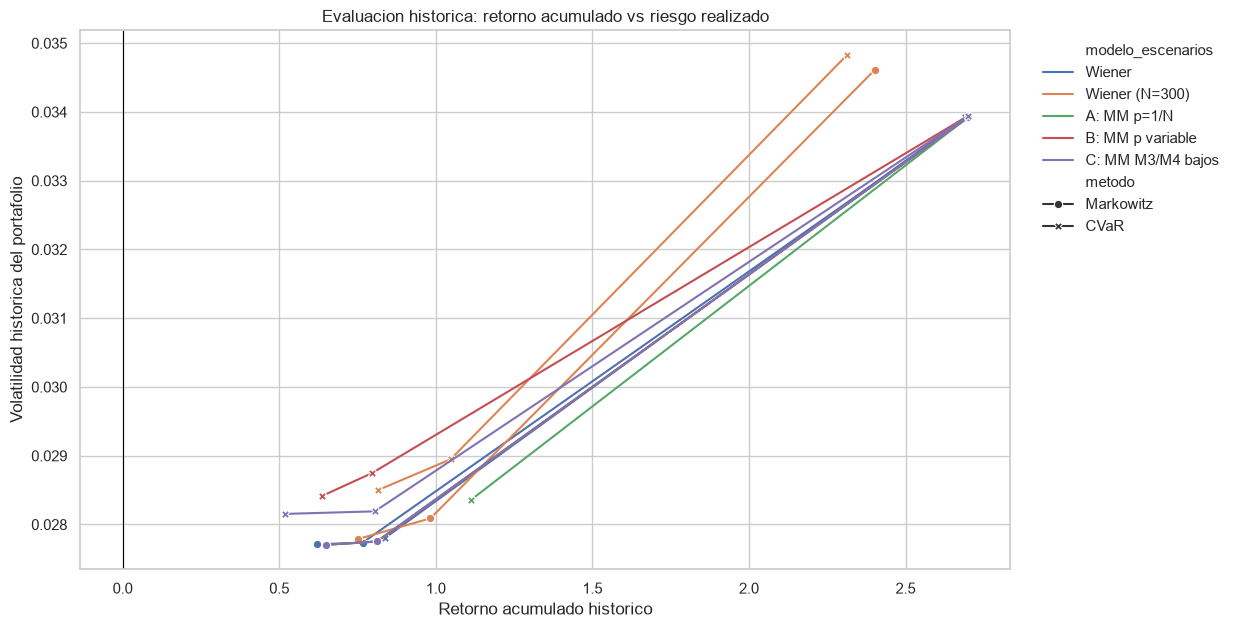

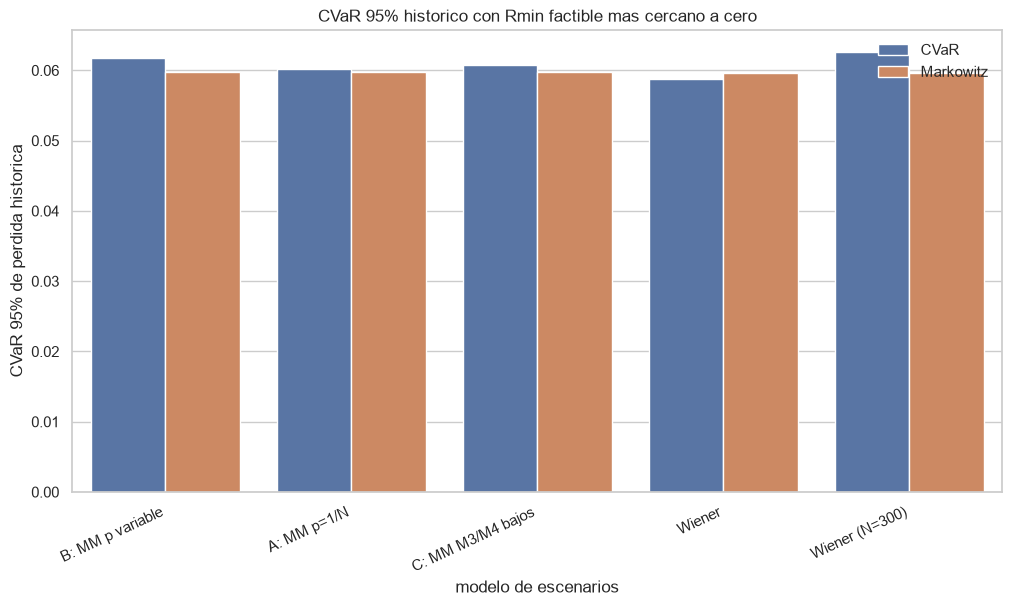

,modelo_escenarios,metodo,retorno_minimo,status,ret_esperado_esc,varianza_esc,volatilidad_esc,VaR95_perdida_esc,CVaR95_perdida_esc,ret_promedio_hist,ret_acumulado_hist,volatilidad_hist,VaR95_perdida_hist,CVaR95_perdida_hist,max_drawdown_hist
1,Wiener,CVaR,-0.010000,solved,0.001722,0.000778,0.027887,0.043568,0.055313,0.002306,0.838224,0.027806,0.038120,0.058825,-0.293995
10,Wiener,Markowitz,0.001580,solved,0.001580,0.000773,0.027798,0.043561,0.055443,0.002177,0.765921,0.027735,0.038518,0.058973,-0.300198
52,B: MM p variable,Markowitz,0.002260,solved,0.002260,0.000770,0.027752,0.042433,0.057960,0.002260,0.812383,0.027752,0.038269,0.059022,-0.301284
38,A: MM p=1/N,Markowitz,0.002260,solved,0.002260,0.000770,0.027752,0.043312,0.056357,0.002260,0.812383,0.027752,0.038269,0.059022,-0.301284
66,C: MM M3/M4 bajos,Markowitz,0.002260,solved,0.002260,0.000770,0.027752,0.044113,0.058588,0.002260,0.812383,0.027752,0.038269,0.059022,-0.301284
14,Wiener (N=300),Markowitz,-0.010000,solved,0.002935,0.000703,0.026510,0.037574,0.048728,0.002151,0.750374,0.027787,0.038566,0.059654,-0.306866
29,A: MM p=1/N,CVaR,-0.010000,solved,0.002762,0.000804,0.028363,0.043357,0.052934,0.002762,1.113800,0.028363,0.037949,0.060161,-0.294940
67,C: MM M3/M4 bajos,CVaR,0.002260,solved,0.002260,0.000795,0.028191,0.046438,0.055683,0.002260,0.805274,0.028191,0.040760,0.060638,-0.285832
51,B: MM p variable,CVaR,-0.000192,solved,0.001959,0.000808,0.028418,0.044896,0.055383,0.001959,0.638157,0.028418,0.042134,0.061714,-0.285183
21,Wiener (N=300),CVaR,-0.001813,solved,0.003183,0.000738,0.027158,0.037854,0.046949,0.002287,0.815552,0.028500,0.036632,0.062613,-0.326093


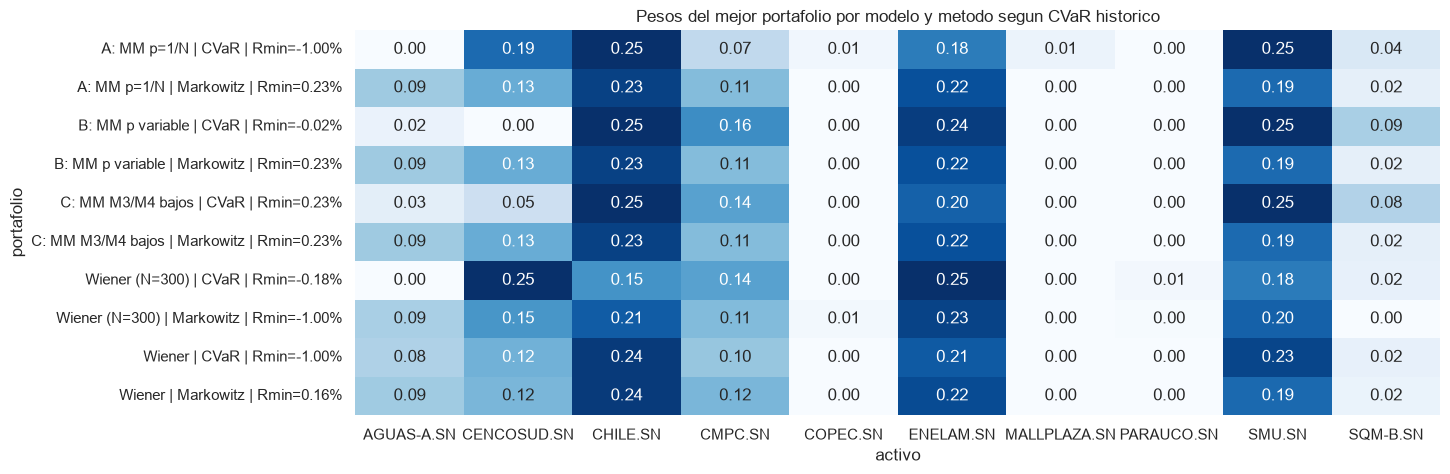

Ranking de portafolios guardado en: C:\Users\brand\Downloads\Ranking_Portafolios_CVaR_Historico.csv


In [39]:
res_solved = resultados_portafolios[resultados_portafolios["status"] == "solved"].copy()
if res_solved.empty:
    raise RuntimeError("No hay portafolios resueltos para graficar.")

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=res_solved.sort_values("retorno_minimo"),
    x="ret_esperado_esc",
    y="volatilidad_esc",
    hue="modelo_escenarios",
    style="metodo",
    markers=True,
    dashes=False,
)
plt.title("Frontera estimada con escenarios")
plt.xlabel("Retorno esperado por escenarios")
plt.ylabel("Volatilidad esperada por escenarios")
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=res_solved.sort_values("retorno_minimo"),
    x="ret_acumulado_hist",
    y="volatilidad_hist",
    hue="modelo_escenarios",
    style="metodo",
    markers=True,
    dashes=False,
)
plt.title("Evaluacion historica: retorno acumulado vs riesgo realizado")
plt.xlabel("Retorno acumulado historico")
plt.ylabel("Volatilidad historica del portafolio")
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# Comparacion de CVaR historico para el Rmin mas cercano a cero en cada modelo y metodo.
res_target = (
    res_solved.assign(abs_rmin=lambda d: d["retorno_minimo"].abs())
    .sort_values("abs_rmin")
    .groupby(["modelo_escenarios", "metodo"], as_index=False)
    .head(1)
    .drop(columns="abs_rmin")
)
if not res_target.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=res_target, x="modelo_escenarios", y="CVaR95_perdida_hist", hue="metodo")
    plt.title("CVaR 95% historico con Rmin factible mas cercano a cero")
    plt.xlabel("modelo de escenarios")
    plt.ylabel("CVaR 95% de perdida historica")
    plt.xticks(rotation=25, ha="right")
    plt.legend(frameon=False)
    plt.show()

# Ranking balanceado: mejor portafolio por modelo y metodo segun CVaR historico.
ranking_cvar = (
    res_solved
    .sort_values("CVaR95_perdida_hist")
    .groupby(["modelo_escenarios", "metodo"], as_index=False)
    .head(1)
)
display(ranking_cvar.round(6))

ids_top = ranking_cvar[["modelo_escenarios", "metodo", "retorno_minimo"]].copy()
pesos_top = pesos_portafolios_df.merge(ids_top, on=["modelo_escenarios", "metodo", "retorno_minimo"], how="inner")
if not pesos_top.empty:
    pesos_top["portafolio"] = pesos_top["modelo_escenarios"] + " | " + pesos_top["metodo"] + " | Rmin=" + pesos_top["retorno_minimo"].map(lambda x: f"{x:.2%}")
    pivot_pesos_top = pesos_top.pivot_table(index="portafolio", columns="activo", values="peso", aggfunc="first").fillna(0)
    plt.figure(figsize=(14, max(5, 0.45 * len(pivot_pesos_top))))
    sns.heatmap(pivot_pesos_top, annot=True, fmt=".2f", cmap="Blues", cbar=False)
    plt.title("Pesos del mejor portafolio por modelo y metodo segun CVaR historico")
    plt.xlabel("activo")
    plt.ylabel("portafolio")
    plt.show()

SALIDA_PORT_RANKING = DATA_DIR / "Ranking_Portafolios_CVaR_Historico.csv"
ranking_cvar.to_csv(SALIDA_PORT_RANKING, index=False)
print(f"Ranking de portafolios guardado en: {SALIDA_PORT_RANKING}")

Weiner Graficos

Comparacion de momentos: historico vs Wiener


Historico                                        Wiener  \
                 media  varianza  skewness curtosis_exceso     media   
AGUAS-A.SN    0.002679  0.001875  0.142018        4.768901  0.001760   
CENCOSUD.SN   0.005301  0.001957 -0.208019        7.103698  0.004727   
CHILE.SN      0.003982  0.001372  0.707016        2.547780  0.003571   
CMPC.SN       0.000283  0.001915  0.455738        2.369970 -0.000297   
COPEC.SN      0.001089  0.001897 -0.663212        4.708041  0.000528   
ENELAM.SN    -0.001202  0.001557  0.748878        6.579650 -0.002082   
MALLPLAZA.SN  0.003889  0.002791 -0.143609        4.031309  0.003359   
PARAUCO.SN    0.003450  0.002951 -0.920846        8.311426  0.002741   
SMU.SN        0.002559  0.001783  0.707420        1.978867  0.002290   
SQM-B.SN      0.006059  0.004116  0.173538        1.797178  0.004246   

                                                  
              varianza  skewness curtosis_exceso  
AGUAS-A.SN    0.001892 -0.013187        0.171019  
CENCOSUD.SN   0.001999  0.006040       -0.045443  
CHILE.SN      0.001368 -0.054082       -0.026832  
CMPC.SN       0.001904 -0.024907        0.016490  
COPEC.SN      0.001863 -0.036734       -0.071454  
ENELAM.SN     0.001534  0.008527        0.082803  
MALLPLAZA.SN  0.002792  0.008732       -0.044527  
PARAUCO.SN    0.002936  0.010765       -0.055250  
SMU.SN        0.001808  0.007867        0.036297  
SQM-B.SN      0.004096 -0.064441        0.005171

Error absoluto promedio del Wiener contra historico


,metrica,MAE,Mediana_AE,Max_AE
0,media,0.000724803,0.000577271,0.001813
1,varianza,1.92528e-05,1.84721e-05,4.2005e-05
2,skewness,0.499932,0.553562,0.931611
3,curtosis_exceso,4.41285,4.33686,8.36668


Error de cuantiles del Wiener contra historico


,cuantil,MAE_cuantil,Max_AE_cuantil
0,0.010000,0.0103983,0.0236557
1,0.050000,0.00946214,0.0153058
2,0.500000,0.00149361,0.00275697
3,0.950000,0.00497981,0.0114438
4,0.990000,0.0145632,0.0307366


Archivos guardados:
- C:\Users\brand\Downloads\Comparacion_Wiener_Historico_Momentos.csv
- C:\Users\brand\Downloads\Errores_Wiener_Historico.csv
- C:\Users\brand\Downloads\Errores_Cuantiles_Wiener_Historico.csv


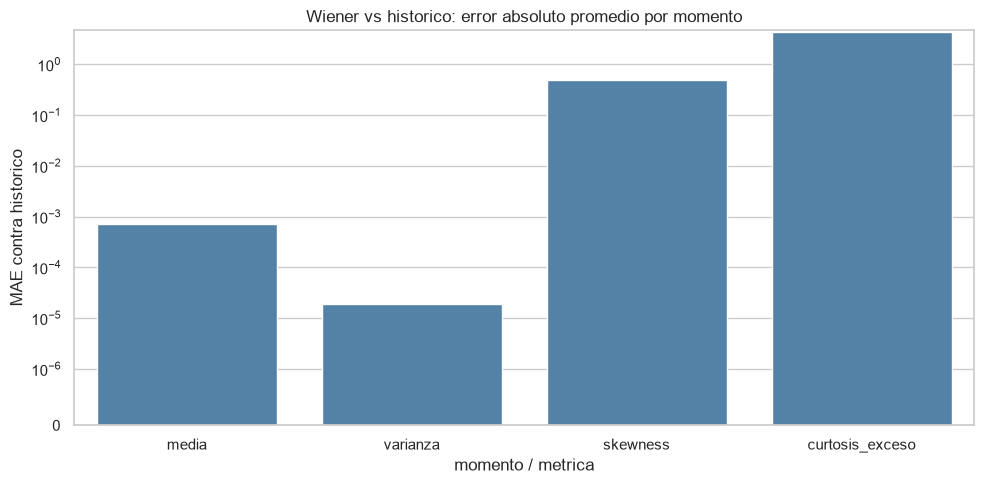

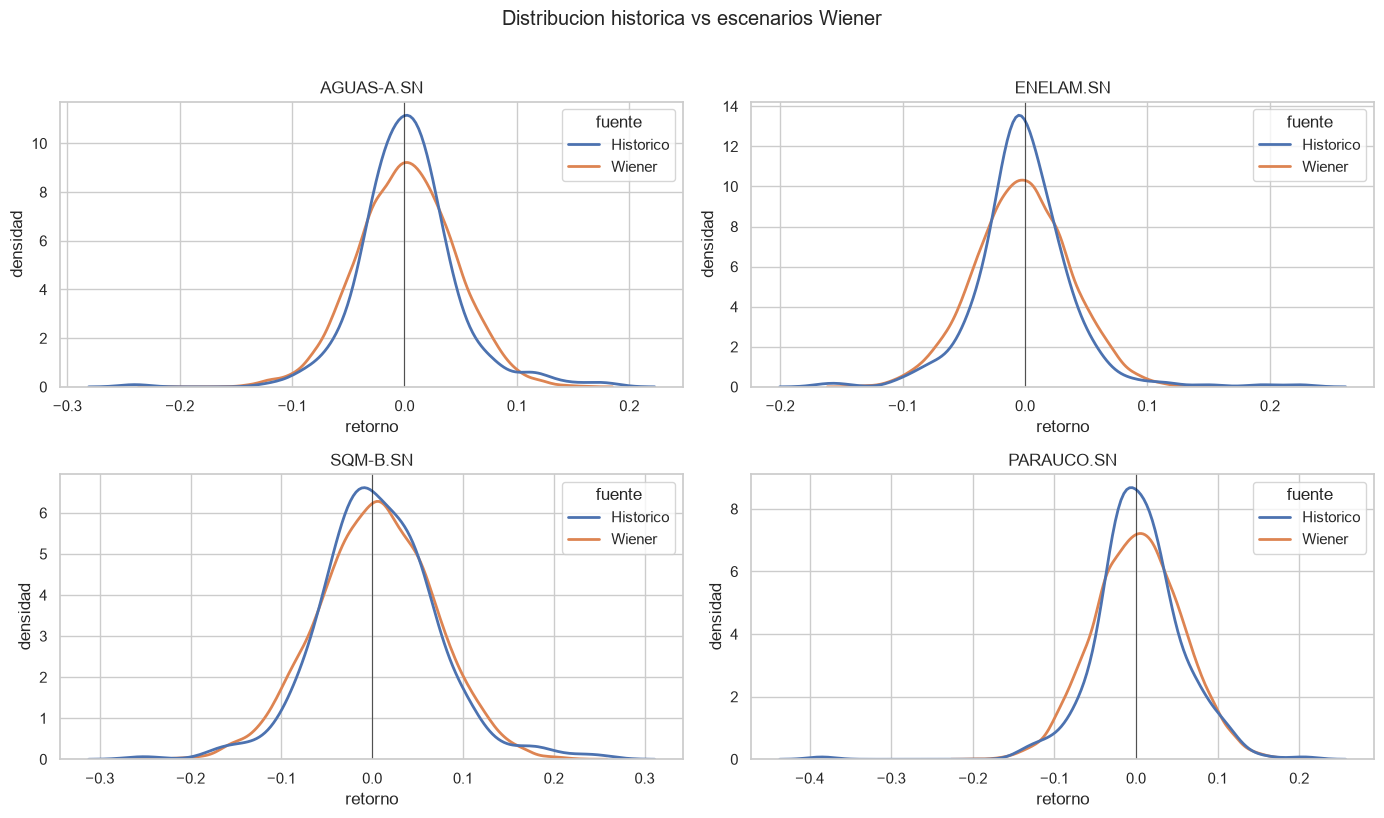

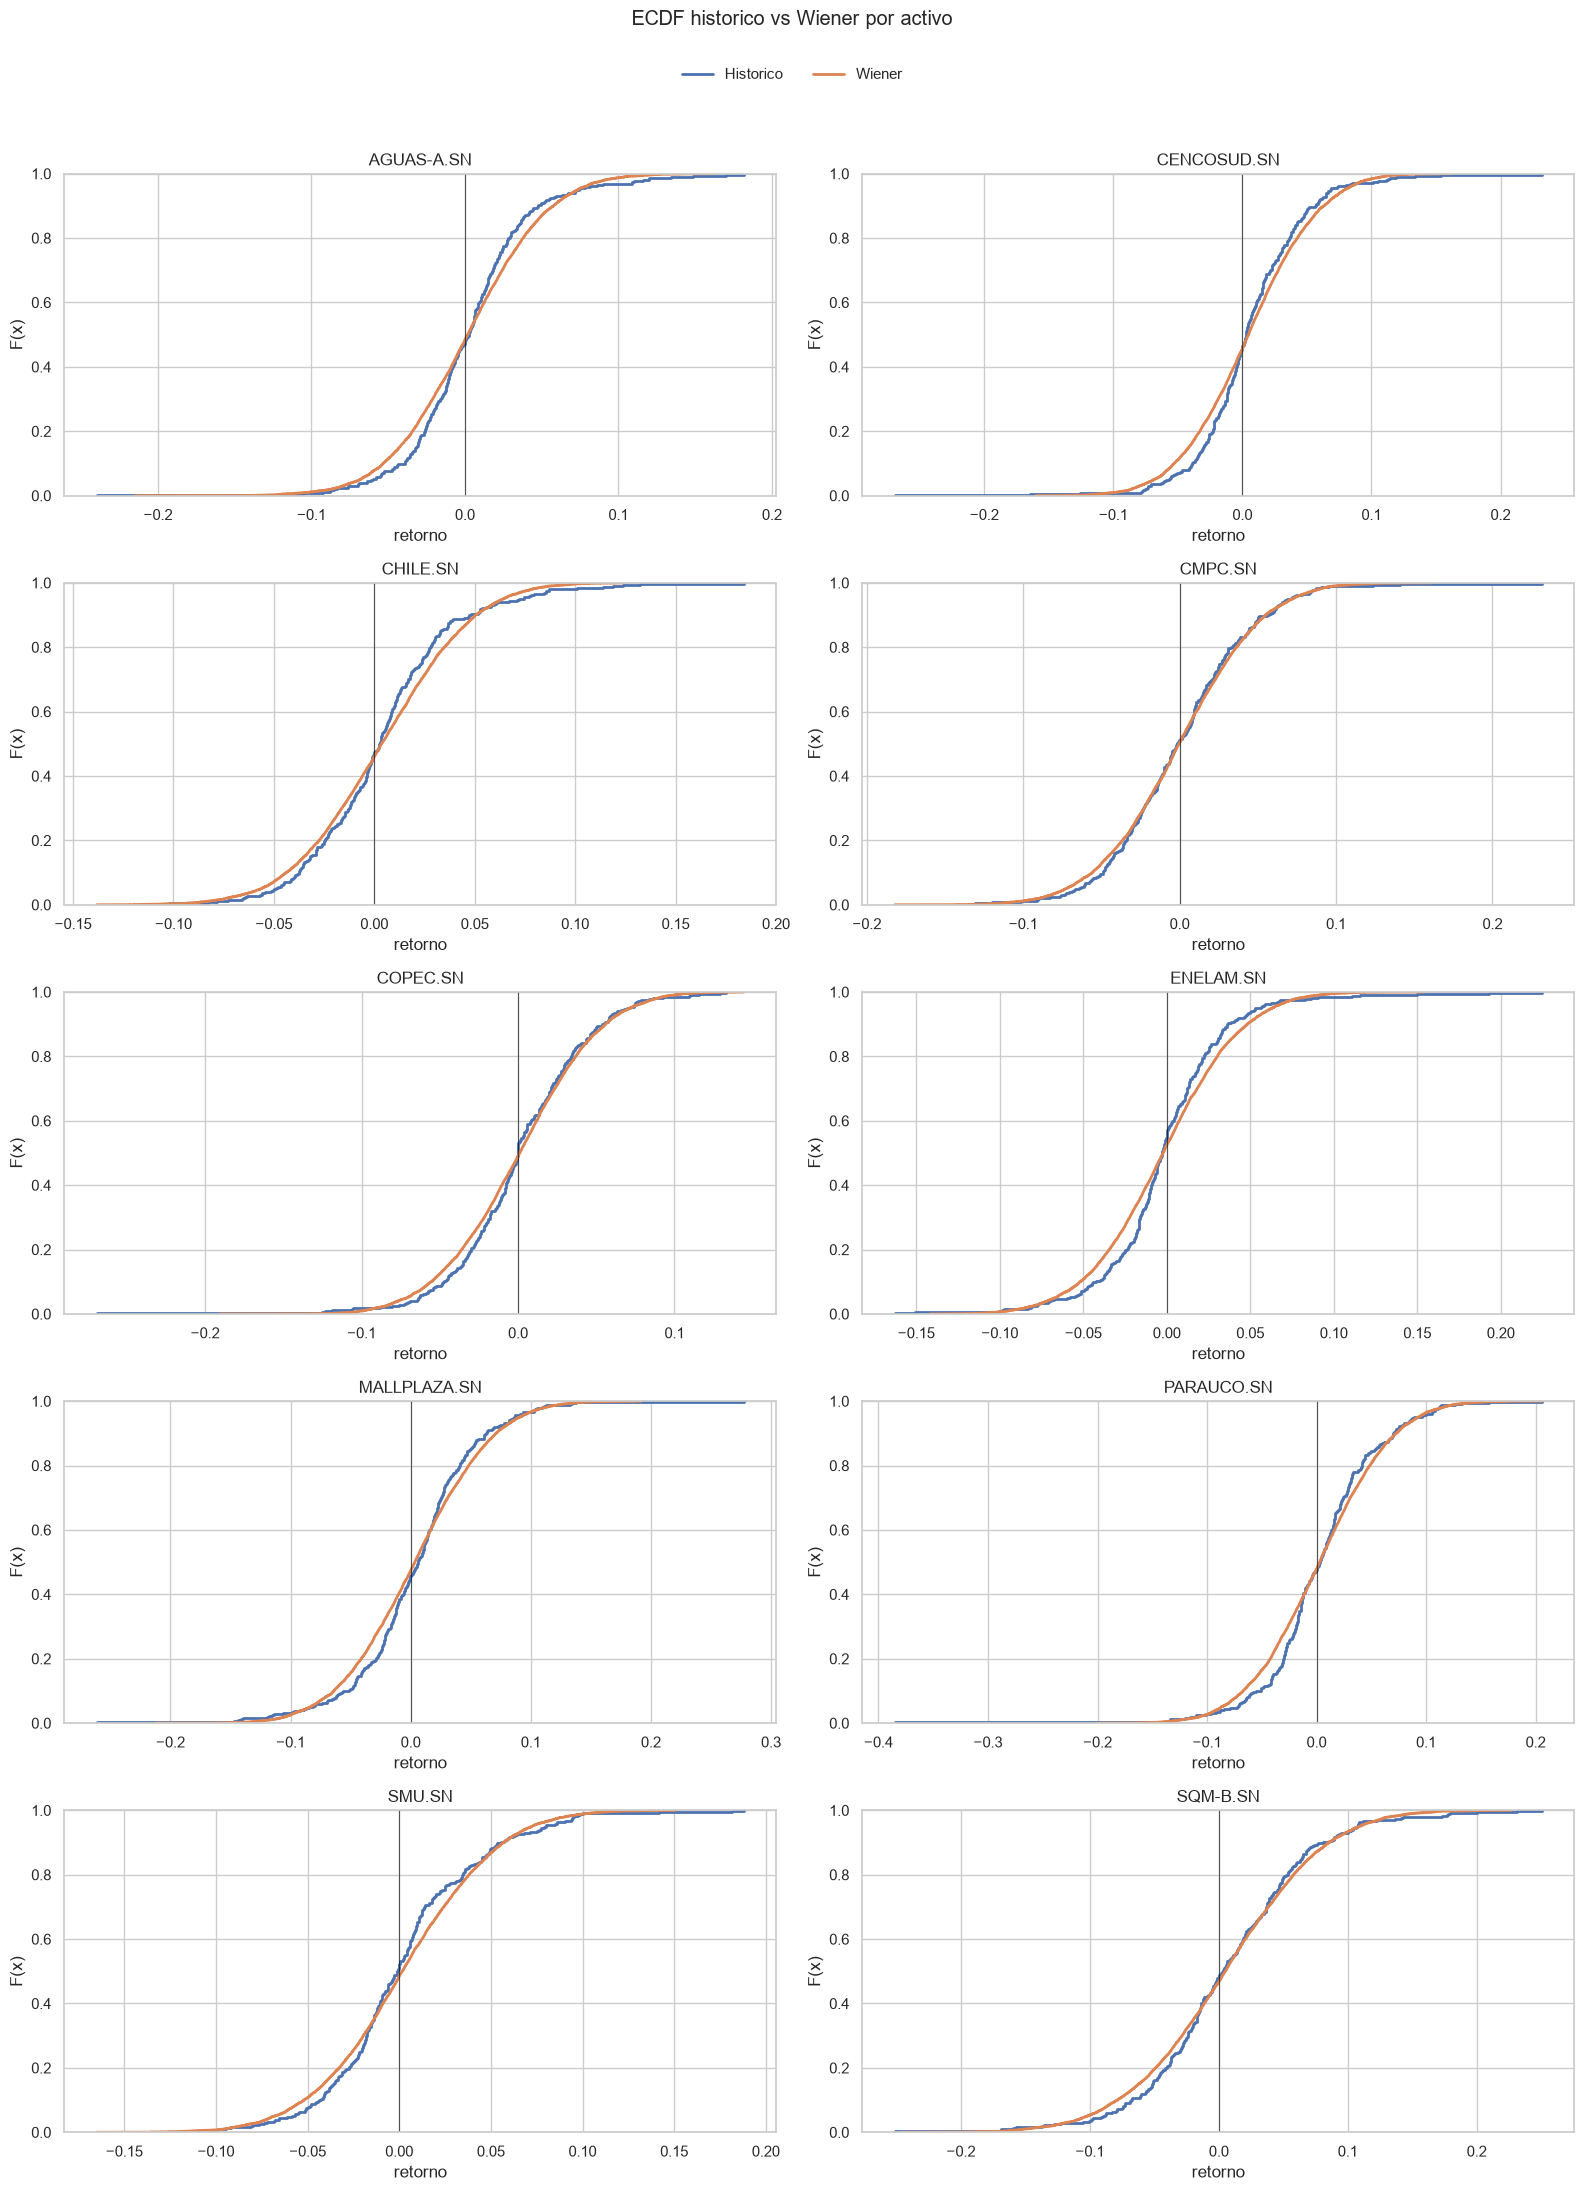

In [40]:
# ---------------------------
# Analisis especifico: Wiener vs historico
# ---------------------------
if "tickers" not in globals():
    raise RuntimeError("Ejecuta primero la carga de datos y la seccion de generacion de escenarios.")

if "retornos_historicos" not in globals():
    if "preparar_retornos_historicos" in globals():
        retornos_historicos = preparar_retornos_historicos()
    else:
        raise RuntimeError("No existe retornos_historicos. Ejecuta primero la seccion de graficos comparativos de escenarios.")

if "wiener_df" not in globals():
    if "escenarios_r02_df" in globals():
        wiener_df = escenarios_r02_df.copy()
    elif "cargar_wiener" in globals():
        wiener_df = cargar_wiener(tickers)
    else:
        raise RuntimeError("No existe wiener_df. Ejecuta primero la seccion Wiener o carga el archivo de escenarios Wiener.")

if "momentos_resumen_reales" not in globals() or "momentos_resumen_desde_escenarios" not in globals():
    raise RuntimeError("Ejecuta primero la seccion 10, donde se definen las funciones de resumen de momentos.")

historico_wiener = retornos_historicos.loc[:, tickers].apply(pd.to_numeric, errors="coerce").dropna(how="any")
escenarios_wiener_comp = wiener_df.loc[:, tickers].apply(pd.to_numeric, errors="coerce").dropna(how="any")

p_wiener_comp = pd.Series(
    np.repeat(1.0 / len(escenarios_wiener_comp), len(escenarios_wiener_comp)),
    index=escenarios_wiener_comp.index,
    name="p",
)

momentos_historico_wiener = momentos_resumen_reales(historico_wiener)
momentos_wiener_solo = momentos_resumen_desde_escenarios(escenarios_wiener_comp, p_wiener_comp)
comparacion_wiener_historico = pd.concat(
    {"Historico": momentos_historico_wiener, "Wiener": momentos_wiener_solo},
    axis=1,
)

metricas_wiener = ["media", "varianza", "skewness", "curtosis_exceso"]
filas_error_wiener = []
for metrica in metricas_wiener:
    err = (momentos_wiener_solo[metrica] - momentos_historico_wiener[metrica]).abs()
    filas_error_wiener.append({
        "metrica": metrica,
        "MAE": float(err.mean()),
        "Mediana_AE": float(err.median()),
        "Max_AE": float(err.max()),
    })
errores_wiener_historico = pd.DataFrame(filas_error_wiener)

cuantiles_wiener = [0.01, 0.05, 0.50, 0.95, 0.99]
q_hist_wiener = historico_wiener.quantile(cuantiles_wiener).T
q_wiener = escenarios_wiener_comp.quantile(cuantiles_wiener).T
filas_q_wiener = []
for q in cuantiles_wiener:
    err_q = (q_wiener[q] - q_hist_wiener[q]).abs()
    filas_q_wiener.append({
        "cuantil": q,
        "MAE_cuantil": float(err_q.mean()),
        "Max_AE_cuantil": float(err_q.max()),
    })
errores_cuantiles_wiener_historico = pd.DataFrame(filas_q_wiener)

print("Comparacion de momentos: historico vs Wiener")
display(comparacion_wiener_historico.round(6))

print("Error absoluto promedio del Wiener contra historico")
display(errores_wiener_historico.style.format({"MAE": "{:.6g}", "Mediana_AE": "{:.6g}", "Max_AE": "{:.6g}"}))

print("Error de cuantiles del Wiener contra historico")
display(errores_cuantiles_wiener_historico.style.format({"MAE_cuantil": "{:.6g}", "Max_AE_cuantil": "{:.6g}"}))

SALIDA_WIENER_MOMENTOS = DATA_DIR / "Comparacion_Wiener_Historico_Momentos.csv"
SALIDA_WIENER_ERRORES = DATA_DIR / "Errores_Wiener_Historico.csv"
SALIDA_WIENER_CUANTILES = DATA_DIR / "Errores_Cuantiles_Wiener_Historico.csv"
comparacion_wiener_historico.to_csv(SALIDA_WIENER_MOMENTOS)
errores_wiener_historico.to_csv(SALIDA_WIENER_ERRORES, index=False)
errores_cuantiles_wiener_historico.to_csv(SALIDA_WIENER_CUANTILES, index=False)
print("Archivos guardados:")
print("-", SALIDA_WIENER_MOMENTOS)
print("-", SALIDA_WIENER_ERRORES)
print("-", SALIDA_WIENER_CUANTILES)

# 1) Error por momento: resume donde Wiener se aleja mas del historico.
plt.figure(figsize=(10, 5))
sns.barplot(data=errores_wiener_historico, x="metrica", y="MAE", color="steelblue")
plt.yscale("symlog", linthresh=1e-6)
plt.title("Wiener vs historico: error absoluto promedio por momento")
plt.xlabel("momento / metrica")
plt.ylabel("MAE contra historico")
plt.tight_layout()
plt.show()

# 2) Distribuciones de activos representativos: historico vs Wiener.
preferidos_wiener = ["AGUAS-A.SN", "ENELAM.SN", "SQM-B.SN", "PARAUCO.SN"]
activos_detalle_wiener = [a for a in preferidos_wiener if a in tickers]
for activo in tickers:
    if len(activos_detalle_wiener) >= 4:
        break
    if activo not in activos_detalle_wiener:
        activos_detalle_wiener.append(activo)

filas_dist_wiener = []
for activo in activos_detalle_wiener:
    filas_dist_wiener.append(pd.DataFrame({"activo": activo, "retorno": historico_wiener[activo].to_numpy(), "fuente": "Historico"}))
    filas_dist_wiener.append(pd.DataFrame({"activo": activo, "retorno": escenarios_wiener_comp[activo].to_numpy(), "fuente": "Wiener"}))
distribuciones_wiener_long = pd.concat(filas_dist_wiener, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.reshape(-1)
for ax, activo in zip(axes, activos_detalle_wiener):
    datos_activo = distribuciones_wiener_long[distribuciones_wiener_long["activo"] == activo]
    sns.kdeplot(
        data=datos_activo,
        x="retorno",
        hue="fuente",
        common_norm=False,
        fill=False,
        linewidth=2,
        warn_singular=False,
        ax=ax,
    )
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(activo)
    ax.set_xlabel("retorno")
    ax.set_ylabel("densidad")
for ax in axes[len(activos_detalle_wiener):]:
    ax.axis("off")
fig.suptitle("Distribucion historica vs escenarios Wiener", y=1.02)
fig.tight_layout()
plt.show()

# 3) ECDF historico vs Wiener para todos los activos.
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.reshape(-1)
for ax, activo in zip(axes, tickers):
    sns.ecdfplot(x=historico_wiener[activo].to_numpy(dtype=float), ax=ax, label="Historico", linewidth=2.0)
    sns.ecdfplot(x=escenarios_wiener_comp[activo].to_numpy(dtype=float), ax=ax, label="Wiener", linewidth=2.0)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(activo)
    ax.set_xlabel("retorno")
    ax.set_ylabel("F(x)")
for ax in axes[len(tickers):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
fig.suptitle("ECDF historico vs Wiener por activo", y=0.995)
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.975))
fig.tight_layout(rect=[0, 0, 1, 0.955])
plt.show()


Guardar figuras para tesis
Esta seccion final reconstruye los graficos principales en formato limpio y los guarda como imagenes PNG en una carpeta dentro de DATA_DIR. Debe ejecutarse despues de haber corrido las secciones de escenarios, optimizacion de portafolios y, si se quiere incluir la prueba real, la seccion enero-mayo 2026.

In [41]:
# ---------------------------
# Guardar figuras limpias para tesis
# ---------------------------
FIG_DIR = DATA_DIR / "figuras_tesis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MOSTRAR_FIGURAS_GUARDADAS = False  # Cambia a True si tambien quieres verlas en el notebook.
rutas_figuras = []

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

NOMBRES_CORTOS_MODELOS = {
    "Historico": "Historico",
    "Wiener": "Wiener",
    "Wiener": "Wiener (N=8000)",
    f"Wiener (N={N_SCENARIOS})": f"Wiener (N={N_SCENARIOS})",
    "A: MM p=1/N": "MM A",
    "B: MM p variable": "MM B",
    "C: MM M3/M4 bajos": "MM C",
}
ORDEN_MODELOS = [m for m in ["Historico", "Wiener", "A: MM p=1/N", "B: MM p variable", "C: MM M3/M4 bajos"] if "modelos_escenarios" in globals() and m in modelos_escenarios]

# Agregado desde V3_corregido: etiquetas y orden incorporando Wiener N=300.
NOMBRES_CORTOS_MODELOS["Wiener"] = "Wiener (N=8000)"
NOMBRES_CORTOS_MODELOS[f"Wiener (N={N_SCENARIOS})"] = f"Wiener (N={N_SCENARIOS})"
_ORDEN_BASE = ["Historico", "Wiener", f"Wiener (N={N_SCENARIOS})", "A: MM p=1/N", "B: MM p variable", "C: MM M3/M4 bajos"]
ORDEN_MODELOS = [m for m in _ORDEN_BASE if "modelos_escenarios" in globals() and m in modelos_escenarios]


def guardar_figura(fig, nombre_archivo):
    ruta = FIG_DIR / nombre_archivo
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor="white")
    rutas_figuras.append(ruta)
    if MOSTRAR_FIGURAS_GUARDADAS:
        plt.show()
    else:
        plt.close(fig)
    return ruta


def ecdf_ponderada(valores, pesos=None):
    valores = np.asarray(valores, dtype=float)
    mask = np.isfinite(valores)
    valores = valores[mask]
    if pesos is None:
        pesos = np.repeat(1 / len(valores), len(valores)) if len(valores) else np.array([])
    else:
        pesos = np.asarray(pesos, dtype=float)[mask]
        pesos = pesos / pesos.sum()
    orden = np.argsort(valores)
    x = valores[orden]
    y = np.cumsum(pesos[orden])
    return x, y


def obtener_pesos_modelo(x_mod, p_mod):
    try:
        return normalizar_probabilidades(p_mod, len(x_mod))
    except Exception:
        return np.repeat(1 / len(x_mod), len(x_mod))



# 00. Retornos historicos acumulados por activo.
if "retornos_acumulados_activos" in globals() or "retornos_historicos" in globals():
    if "retornos_acumulados_activos" in globals():
        acumulados_fig = retornos_acumulados_activos.copy()
    else:
        acumulados_fig = (1.0 + retornos_historicos[tickers]).cumprod() - 1.0

    fig, ax = plt.subplots(figsize=(14, 7))
    for activo in acumulados_fig.columns:
        ax.plot(acumulados_fig.index, acumulados_fig[activo], linewidth=1.8, label=activo)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Retornos historicos acumulados por activo")
    ax.set_xlabel("fecha")
    ax.set_ylabel("retorno acumulado")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    guardar_figura(fig, "00_retornos_historicos_acumulados_activos.png")
else:
    print("No se guarda 00_retornos_historicos_acumulados_activos.png: falta retornos_acumulados_activos o retornos_historicos.")


# 01. Error promedio de momentos.
if "errores_momentos" in globals() and not errores_momentos.empty:
    datos = errores_momentos.copy()
    datos["modelo_corto"] = datos["modelo"].map(NOMBRES_CORTOS_MODELOS).fillna(datos["modelo"])
    fig, ax = plt.subplots(figsize=(13, 7))
    sns.barplot(data=datos, x="metrica", y="MAE", hue="modelo_corto", ax=ax)
    ax.set_yscale("symlog", linthresh=1e-6)
    ax.set_title("Error absoluto promedio de momentos contra retornos historicos")
    ax.set_xlabel("metrica")
    ax.set_ylabel("MAE contra historico")
    ax.legend(title="modelo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    guardar_figura(fig, "01_error_momentos_modelos.png")
else:
    print("No se guarda 01_error_momentos_modelos.png: falta ejecutar la comparacion de momentos.")


# 02. ECDF por activo, con leyenda general y sin solapamiento.
if "modelos_escenarios" in globals() and ORDEN_MODELOS:
    fig, axes = plt.subplots(5, 2, figsize=(18, 24))
    axes = axes.reshape(-1)
    for ax, activo in zip(axes, tickers):
        for nombre in ORDEN_MODELOS:
            x_mod, p_mod = modelos_escenarios[nombre]
            p_arr = obtener_pesos_modelo(x_mod, p_mod)
            x_ecdf, y_ecdf = ecdf_ponderada(x_mod[activo].to_numpy(dtype=float), p_arr)
            ax.step(x_ecdf, y_ecdf, where="post", linewidth=1.8, label=NOMBRES_CORTOS_MODELOS.get(nombre, nombre))
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(activo)
        ax.set_xlabel("retorno semanal")
        ax.set_ylabel("F(x)")
    for ax in axes[len(tickers):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle("Distribuciones acumuladas empiricas por activo", fontsize=18, y=0.995)
    fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)), frameon=False, bbox_to_anchor=(0.5, 0.972))
    fig.tight_layout(rect=[0, 0, 1, 0.955])
    guardar_figura(fig, "02_ecdf_escenarios_por_activo.png")
else:
    print("No se guarda 02_ecdf_escenarios_por_activo.png: falta modelos_escenarios.")


# 03. Boxplots por activo con nombres cortos.
if "retornos_long" in globals() and not retornos_long.empty:
    datos_box = retornos_long.copy()
    datos_box["modelo_corto"] = datos_box["modelo"].map(NOMBRES_CORTOS_MODELOS).fillna(datos_box["modelo"])
    orden_corto = [NOMBRES_CORTOS_MODELOS.get(m, m) for m in ORDEN_MODELOS]
    fig, axes = plt.subplots(5, 2, figsize=(18, 24))
    axes = axes.reshape(-1)
    for ax, activo in zip(axes, tickers):
        sub = datos_box[datos_box["activo"] == activo]
        sns.boxplot(data=sub, x="modelo_corto", y="retorno", order=orden_corto, showfliers=False, ax=ax, color="#8ab6d6")
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(activo)
        ax.set_xlabel("")
        ax.set_ylabel("retorno semanal")
        ax.tick_params(axis="x", rotation=20)
    for ax in axes[len(tickers):]:
        ax.axis("off")
    fig.suptitle("Boxplots de retornos por activo y modelo", fontsize=18, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.975])
    guardar_figura(fig, "03_boxplots_escenarios_por_activo.png")
else:
    print("No se guarda 03_boxplots_escenarios_por_activo.png: falta retornos_long.")


# 04. Error promedio de cuantiles.
if "errores_cuantiles" in globals() and not errores_cuantiles.empty:
    datos_q = errores_cuantiles.copy()
    datos_q["modelo_corto"] = datos_q["modelo"].map(NOMBRES_CORTOS_MODELOS).fillna(datos_q["modelo"])
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=datos_q, x="cuantil", y="MAE_cuantil", hue="modelo_corto", ax=ax)
    ax.set_title("Error promedio de cuantiles contra retornos historicos")
    ax.set_xlabel("cuantil")
    ax.set_ylabel("MAE de cuantiles")
    ax.legend(title="modelo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    guardar_figura(fig, "04_error_cuantiles_modelos.png")
else:
    print("No se guarda 04_error_cuantiles_modelos.png: falta errores_cuantiles.")


# 05. Matrices de correlacion.
if "corrs" in globals() and len(corrs) > 0:
    nombres_corr = [m for m in ORDEN_MODELOS if m in corrs]
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.reshape(-1)
    for ax, nombre in zip(axes, nombres_corr):
        sns.heatmap(corrs[nombre], vmin=-1, vmax=1, center=0, cmap="vlag", ax=ax, cbar=True, square=True)
        ax.set_title(NOMBRES_CORTOS_MODELOS.get(nombre, nombre))
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    for ax in axes[len(nombres_corr):]:
        ax.axis("off")
    fig.suptitle("Matrices de correlacion por modelo", fontsize=18, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.965])
    guardar_figura(fig, "05_matrices_correlacion_modelos.png")
else:
    print("No se guarda 05_matrices_correlacion_modelos.png: falta corrs.")


# 06. Frontera estimada con escenarios.
if "resultados_portafolios" in globals() and not resultados_portafolios.empty:
    res_solved_fig = resultados_portafolios[resultados_portafolios["status"] == "solved"].copy()
    if not res_solved_fig.empty:
        res_solved_fig["modelo_corto"] = res_solved_fig["modelo_escenarios"].map(NOMBRES_CORTOS_MODELOS).fillna(res_solved_fig["modelo_escenarios"])
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.scatterplot(
            data=res_solved_fig,
            x="ret_esperado_esc",
            y="volatilidad_esc",
            hue="modelo_corto",
            style="metodo",
            s=95,
            ax=ax,
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title("Frontera estimada con escenarios")
        ax.set_xlabel("retorno esperado por escenarios")
        ax.set_ylabel("volatilidad esperada por escenarios")
        ax.legend(title="modelo / metodo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        guardar_figura(fig, "06_frontera_estimada_escenarios.png")

        fig, ax = plt.subplots(figsize=(12, 7))
        sns.scatterplot(
            data=res_solved_fig,
            x="ret_acumulado_hist",
            y="volatilidad_hist",
            hue="modelo_corto",
            style="metodo",
            s=95,
            ax=ax,
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title("Evaluacion historica de portafolios")
        ax.set_xlabel("retorno acumulado historico")
        ax.set_ylabel("volatilidad historica")
        ax.legend(title="modelo / metodo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        guardar_figura(fig, "07_evaluacion_historica_portafolios.png")

        res_target = (
            res_solved_fig.assign(abs_rmin=lambda d: d["retorno_minimo"].abs())
            .sort_values("abs_rmin")
            .groupby(["modelo_escenarios", "metodo"], as_index=False)
            .head(1)
            .drop(columns="abs_rmin")
        )
        if not res_target.empty:
            fig, ax = plt.subplots(figsize=(12, 6))
            sns.barplot(data=res_target, x="modelo_corto", y="CVaR95_perdida_hist", hue="metodo", ax=ax)
            ax.set_title("CVaR 95% historico con Rmin factible mas cercano a cero")
            ax.set_xlabel("modelo de escenarios")
            ax.set_ylabel("CVaR 95% de perdida historica")
            ax.legend(title="metodo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
            guardar_figura(fig, "08_cvar_historico_por_modelo.png")

        ranking_cvar_fig = (
            res_solved_fig
            .sort_values("CVaR95_perdida_hist")
            .groupby(["modelo_escenarios", "metodo"], as_index=False)
            .head(1)
        )
        ids_top = ranking_cvar_fig[["modelo_escenarios", "metodo", "retorno_minimo"]].copy()
        pesos_top = pesos_portafolios_df.merge(ids_top, on=["modelo_escenarios", "metodo", "retorno_minimo"], how="inner")
        if not pesos_top.empty:
            pesos_top["modelo_corto"] = pesos_top["modelo_escenarios"].map(NOMBRES_CORTOS_MODELOS).fillna(pesos_top["modelo_escenarios"])
            pesos_top["portafolio"] = pesos_top["modelo_corto"] + " | " + pesos_top["metodo"] + " | Rmin=" + pesos_top["retorno_minimo"].map(lambda x: f"{x:.2%}")
            pivot_pesos_top = pesos_top.pivot_table(index="portafolio", columns="activo", values="peso", aggfunc="first").fillna(0)
            fig, ax = plt.subplots(figsize=(16, max(6, 0.5 * len(pivot_pesos_top))))
            sns.heatmap(pivot_pesos_top, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax)
            ax.set_title("Pesos del mejor portafolio por modelo y metodo segun CVaR historico")

            ax.set_title("Pesos del mejor portafolio por modelo y metodo segun CVaR historico (Rmin variable por fila)")
            ax.set_xlabel("activo")
            ax.set_ylabel("portafolio")
            guardar_figura(fig, "09_pesos_mejores_portafolios_cvar_historico.png")

    else:
        print("No se guardan figuras de portafolio: no hay portafolios resueltos.")
else:
    print("No se guardan figuras de portafolio: falta resultados_portafolios.")


# 10-13. Figuras de la prueba real enero-mayo 2026, si la seccion fue ejecutada.
if "resultados_eval_2026" in globals() and not resultados_eval_2026.empty:
    if "resultados_eval_2026_con_benchmark" in globals():
        eval_2026_fig = resultados_eval_2026_con_benchmark.copy()
    else:
        eval_2026_fig = resultados_eval_2026.copy()
    eval_2026_fig["modelo_corto"] = eval_2026_fig["modelo_escenarios"].map(NOMBRES_CORTOS_MODELOS).fillna(eval_2026_fig["modelo_escenarios"])

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.scatterplot(
        data=eval_2026_fig,
        x="ret_acumulado_ene_may_2026",
        y="volatilidad_ene_may_2026",
        hue="modelo_corto",
        style="metodo",
        s=95,
        ax=ax,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Prueba real enero-mayo 2026: retorno acumulado vs volatilidad")
    ax.set_xlabel("retorno acumulado real enero-mayo 2026")
    ax.set_ylabel("volatilidad real enero-mayo 2026")
    ax.legend(title="modelo / metodo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    guardar_figura(fig, "10_prueba_real_2026_retorno_vs_volatilidad.png")

    top_ganancia_fig = eval_2026_fig.sort_values("ret_acumulado_ene_may_2026", ascending=False).head(10).copy()
    top_ganancia_fig["portafolio"] = np.where(
        top_ganancia_fig["modelo_escenarios"].eq("Benchmark igual ponderado"),
        "Benchmark igual ponderado",
        top_ganancia_fig["modelo_corto"] + " | " + top_ganancia_fig["metodo"] + " | Rmin=" + top_ganancia_fig["retorno_minimo"].map(lambda x: f"{x:.2%}"),
    )
    fig, ax = plt.subplots(figsize=(13, max(6, 0.5 * len(top_ganancia_fig))))
    sns.barplot(data=top_ganancia_fig, y="portafolio", x="ret_acumulado_ene_may_2026", hue="modelo_corto", dodge=False, ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Portafolios que mas ganaron en enero-mayo 2026")
    ax.set_xlabel("retorno acumulado real")
    ax.set_ylabel("portafolio")
    ax.legend(title="modelo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    guardar_figura(fig, "11_ranking_ganancia_enero_mayo_2026.png")

    if "curvas_todos_2026" in globals() and not curvas_todos_2026.empty:
        curvas_todos_fig = curvas_todos_2026.copy()
    elif "series_eval_2026" in globals() and len(series_eval_2026) > 0:
        series_todos_fig = []
        base_todos_fig = resultados_eval_2026.sort_values(["modelo_escenarios", "metodo", "retorno_minimo"]).copy()
        for _, row in base_todos_fig.iterrows():
            key = (row["modelo_escenarios"], row["metodo"], float(row["retorno_minimo"]))
            if key not in series_eval_2026:
                continue
            serie = series_eval_2026[key]
            curva = (1.0 + serie).cumprod() - 1.0
            modelo_corto = NOMBRES_CORTOS_MODELOS.get(row["modelo_escenarios"], row["modelo_escenarios"])
            etiqueta = f'{modelo_corto} | {row["metodo"]} | Rmin={row["retorno_minimo"]:.2%}'
            tmp = curva.rename("retorno_acumulado").reset_index()
            tmp = tmp.rename(columns={tmp.columns[0]: "fecha"})
            tmp["portafolio"] = etiqueta
            series_todos_fig.append(tmp)
        if "serie_equal_2026" in globals():
            curva_benchmark_fig = (1.0 + serie_equal_2026).cumprod() - 1.0
            tmp_benchmark_fig = curva_benchmark_fig.rename("retorno_acumulado").reset_index()
            tmp_benchmark_fig = tmp_benchmark_fig.rename(columns={tmp_benchmark_fig.columns[0]: "fecha"})
            tmp_benchmark_fig["portafolio"] = "Benchmark igual ponderado"
            series_todos_fig.append(tmp_benchmark_fig)
        curvas_todos_fig = pd.concat(series_todos_fig, ignore_index=True) if series_todos_fig else pd.DataFrame()
    else:
        curvas_todos_fig = pd.DataFrame()

    if not curvas_todos_fig.empty:
        orden_todos_fig = curvas_todos_fig["portafolio"].drop_duplicates().tolist()
        paleta_todos_fig = dict(zip(orden_todos_fig, sns.color_palette("husl", n_colors=len(orden_todos_fig))))
        fig, ax = plt.subplots(figsize=(14, 7))
        sns.lineplot(
            data=curvas_todos_fig,
            x="fecha",
            y="retorno_acumulado",
            hue="portafolio",
            hue_order=orden_todos_fig,
            palette=paleta_todos_fig,
            marker="o",
            linewidth=1.8,
            ax=ax,
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title("Evolucion acumulada de todos los portafolios enero-mayo 2026")
        ax.set_xlabel("fecha")
        ax.set_ylabel("retorno acumulado real")
        ax.legend(title="portafolio", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        guardar_figura(fig, "12_evolucion_todos_portafolios_enero_mayo_2026.png")

    ganador_2026 = eval_2026_fig.sort_values("ret_acumulado_ene_may_2026", ascending=False).head(1)[["modelo_escenarios", "metodo", "retorno_minimo"]]
    pesos_ganador_2026 = pesos_portafolios_df.merge(ganador_2026, on=["modelo_escenarios", "metodo", "retorno_minimo"], how="inner")
    if not pesos_ganador_2026.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=pesos_ganador_2026.sort_values("peso", ascending=False), x="activo", y="peso", color="steelblue", ax=ax)
        ax.set_title("Composicion del portafolio que mas gano en enero-mayo 2026")
        ax.set_xlabel("activo")
        ax.set_ylabel("peso")
        ax.tick_params(axis="x", rotation=25)
        ax.set_ylim(0, max(0.30, pesos_ganador_2026["peso"].max() * 1.15))
        guardar_figura(fig, "13_pesos_portafolio_ganador_enero_mayo_2026.png")
else:
    print("No se guardan figuras de enero-mayo 2026: ejecuta primero la seccion 13.")


print("Figuras guardadas en:", FIG_DIR)
for ruta in rutas_figuras:
    print("-", ruta.name)

if rutas_figuras:
    display(pd.DataFrame({"figura": [r.name for r in rutas_figuras], "ruta": [str(r) for r in rutas_figuras]}))


Figuras guardadas en: C:\Users\brand\Downloads\figuras_tesis
- 00_retornos_historicos_acumulados_activos.png
- 01_error_momentos_modelos.png
- 02_ecdf_escenarios_por_activo.png
- 03_boxplots_escenarios_por_activo.png
- 04_error_cuantiles_modelos.png
- 05_matrices_correlacion_modelos.png
- 06_frontera_estimada_escenarios.png
- 07_evaluacion_historica_portafolios.png
- 08_cvar_historico_por_modelo.png
- 09_pesos_mejores_portafolios_cvar_historico.png
- 10_prueba_real_2026_retorno_vs_volatilidad.png
- 11_ranking_ganancia_enero_mayo_2026.png
- 12_evolucion_todos_portafolios_enero_mayo_2026.png
- 13_pesos_portafolio_ganador_enero_mayo_2026.png


,figura,ruta
0,00_retornos_historicos_acumulados_activos.png,C:\Users\brand\Downloads\figuras_tesis\00_reto...
1,01_error_momentos_modelos.png,C:\Users\brand\Downloads\figuras_tesis\01_erro...
2,02_ecdf_escenarios_por_activo.png,C:\Users\brand\Downloads\figuras_tesis\02_ecdf...
3,03_boxplots_escenarios_por_activo.png,C:\Users\brand\Downloads\figuras_tesis\03_boxp...
4,04_error_cuantiles_modelos.png,C:\Users\brand\Downloads\figuras_tesis\04_erro...
5,05_matrices_correlacion_modelos.png,C:\Users\brand\Downloads\figuras_tesis\05_matr...
6,06_frontera_estimada_escenarios.png,C:\Users\brand\Downloads\figuras_tesis\06_fron...
7,07_evaluacion_historica_portafolios.png,C:\Users\brand\Downloads\figuras_tesis\07_eval...
8,08_cvar_historico_por_modelo.png,C:\Users\brand\Downloads\figuras_tesis\08_cvar...
9,09_pesos_mejores_portafolios_cvar_historico.png,C:\Users\brand\Downloads\figuras_tesis\09_peso...
